[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap09/cap09_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:19%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 9 Aprendizado Profundo para Visão Computacional

**🚧 Este capítulo encontra-se em desenvolvimento.**

Os capítulos anteriores estabeleceram os fundamentos da Visão Computacional por meio de métodos clássicos de extração e representação de características. No **Capítulo 7**, descritores como *Local Binary Patterns* (*LBP*) e *Histogram of Oriented Gradients* (*HOG*) mostraram como texturas e formas podem ser codificadas por descritores projetados manualmente. No **Capítulo 8**, algoritmos como *Oriented FAST and Rotated BRIEF* (*ORB*) e o detector *Haar Cascade* estenderam esse princípio a tarefas de correspondência, detecção e reconhecimento de objetos.

Essas técnicas permanecem relevantes por sua interpretabilidade e eficiência computacional, mas dependem de uma etapa prévia de definição manual de descritores, denominada **engenharia de características** (*feature engineering*). Essa dependência limita a adaptação do modelo a cenários para os quais o descritor não foi projetado.

O *Deep Learning* propõe uma alternativa: em vez de especificar manualmente as características relevantes, o modelo aprende automaticamente representações a partir dos dados durante o treinamento — processo conhecido como **aprendizado de representações** (*representation learning*) (?goodfellow2016deep). Na Visão Computacional, essa estratégia é implementada principalmente pelas **Redes Neurais Convolucionais** (*Convolutional Neural Networks* — *CNNs*), nas quais os filtros convolucionais deixam de ter coeficientes fixos e passam a ser ajustados por algoritmos de otimização.

Ainda que representem uma mudança na construção de sistemas de reconhecimento de padrões, as *CNNs* preservam conceitos já estudados neste livro: a convolução, apresentada no **Capítulo 3**, permanece a operação responsável pela extração local de características, agora aplicada com coeficientes aprendidos em vez de projetados.

## 9.1 Objetivos do Capítulo

Ao final deste capítulo, o estudante deverá ser capaz de:

- Relacionar a convolução aprendida pelas *CNNs* com a convolução de *kernels* fixos apresentada no **Capítulo 3**;
- Descrever a arquitetura básica de uma *CNN* e a função de suas camadas principais;
- Implementar, treinar e avaliar modelos de *CNN* para classificação de imagens;
- Aplicar **transferência de aprendizado** (*transfer learning*) para adaptar modelos pré-treinados a novos problemas;
- Utilizar modelos pré-treinados em tarefas de classificação, detecção de objetos e segmentação;
- Implementar, treinar e avaliar uma arquitetura *U-Net* para segmentação semântica, comparando-a a abordagens clássicas;
- Preparar conjuntos de dados anotados e integrá-los a um *pipeline* de treinamento por meio de plataformas como o **Roboflow**;
- Integrar geometria computacional e *Deep Learning* em aplicações de realidade aumentada, fotogrametria e visão estereoscópica.

A [Figura 9.1](#fig-09-infografo) sintetiza a organização dos conceitos estudados neste capítulo e as relações entre eles.

<figure id="fig-09-infografo" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-09-infografo.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 9.1:</strong> Visão geral dos principais conceitos abordados neste capítulo. **Fonte:** elaborado com auxílio do *Gemini Notebook* ({GOOGLE}, 2025).</figcaption>
</figure>

## 9.2 Panorama: Classificação, Detecção e Segmentação

As tarefas de Visão Computacional diferenciam-se, sobretudo, pela informação produzida como saída. A **classificação** atribui um único rótulo à imagem inteira; a **detecção de objetos** localiza e identifica os objetos presentes na cena; a **segmentação** associa uma classe a cada pixel e, em algumas abordagens, distingue diferentes instâncias de uma mesma categoria.

A [Tabela 9.1](#tbl-panorama-tarefas) resume as tarefas estudadas ao longo do livro, indicando a pergunta que cada uma responde e a granularidade da informação produzida.

<a id="tbl-panorama-tarefas"></a>

**Tabela 9.1:** Comparativo entre as principais tarefas de Visão Computacional segundo a granularidade da informação produzida.

| Tarefa | Pergunta respondida | Granularidade da saída | Capítulo |
|-----------------------------|-----------------------------------------------|-------------------------------------------------------------|:--------:|
| **Classificação** | "Qual é a classe desta imagem?" | Um único rótulo para a imagem inteira | 7 e 9 |
| **Detecção de objetos** | "Quais objetos existem e onde estão?" | Classe e caixa delimitadora (*bounding box*) para cada objeto | 8 e 9 |
| **Segmentação semântica** | "A que classe pertence cada pixel?" | Um rótulo de classe para cada pixel | 8 e 9 |
| **Segmentação de instâncias** | "Quais pixels pertencem a cada objeto?" | Um rótulo por pixel para cada instância | 8 e 9 |
| **Segmentação panóptica** | "Qual é a classe e a identidade de cada objeto?" | Classe e identificador de instância para cada pixel | 8 e 9 |


Essas tarefas representam níveis crescentes de interpretação da imagem: a classificação descreve a cena de forma global, a detecção acrescenta a localização dos objetos e a segmentação produz uma representação espacial detalhada, permitindo analisar cada região individualmente. Este capítulo concentra-se, primeiro, na classificação por *CNNs*, para em seguida estender os mesmos princípios à detecção e à segmentação.

## 9.3 Configuração do Ambiente

Os exemplos deste capítulo utilizam o **PyTorch**, um *framework* amplamente empregado no desenvolvimento e no treinamento de modelos de *Deep Learning*. O código a seguir verifica a disponibilidade das bibliotecas necessárias e instala, automaticamente, aquelas ainda não presentes no ambiente de execução.

Caso o **PyTorch** não esteja instalado, é selecionada automaticamente uma versão compatível com o hardware disponível: a versão com suporte a **CUDA**, se houver GPU NVIDIA disponível, ou a versão para execução em CPU, caso contrário.

Em seguida, o ambiente é inicializado com a importação das bibliotecas utilizadas ao longo do capítulo, a definição de uma semente aleatória para favorecer a reprodutibilidade dos experimentos e a obtenção do arquivo `morph.py` — a biblioteca didática de processamento morfológico já utilizada em capítulos anteriores —, caso ele ainda não esteja disponível no diretório de trabalho.

In [38]:
import importlib, subprocess, sys, shutil, os, urllib.request

for mod, pkg in {
    "cv2": "opencv-python",
    "skimage": "scikit-image",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

try:
    import torch
except ImportError:
    args = (
        ["torch", "torchvision"]
        if shutil.which("nvidia-smi")
        else ["--index-url", "https://download.pytorch.org/whl/cpu",
              "torch", "torchvision"]
    )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)
    import torch

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from skimage import data as skdata

torch.manual_seed(42)

if not os.path.exists("morph.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/morph.py",
        "morph.py",
    )

import morph
from morph import mm

device = "cuda" if torch.cuda.is_available() else "cpu"
gpu = f" ({torch.cuda.get_device_name(0)})" if device == "cuda" else ""

print(
    f"✅ Ambiente pronto. morph {getattr(morph,'__version__','local_file')} | "
    f"PyTorch {torch.__version__} | {device}{gpu}"
)

✅ Ambiente pronto. morph 1.1.7 | PyTorch 2.12.1+cpu | cpu


## 9.4 Da Convolução Fixa à Convolução Aprendida

O **Capítulo 3** apresentou a convolução espacial com *kernels* fixos, como os operadores de Sobel, projetados para realçar características específicas de uma imagem. Nos **Capítulos 7** e **8**, o mesmo princípio sustentou descritores como *HOG*, *LBP* e *ORB*, além do detector *Haar Cascade*: em todos esses casos, os filtros são definidos antes da execução do algoritmo e permanecem inalterados durante o processamento.

A [Figura 9.2](#fig-09-sim-convolucao) retoma o funcionamento da convolução espacial: o simulador permite selecionar diferentes *kernels* e acompanhar o deslocamento da janela de convolução sobre uma imagem. Em cada posição, os coeficientes do *kernel* combinam-se com a vizinhança correspondente para produzir um valor do **mapa de características** (*feature map*), ilustrando também o **compartilhamento de pesos** (*weight sharing*) — a aplicação do mesmo *kernel* em todas as posições da imagem.

As *CNNs* preservam essa operação, mas substituem *kernels* fixos por **filtros aprendidos**: em vez de coeficientes definidos previamente, a rede ajusta esses valores durante o treinamento a partir de exemplos rotulados, buscando minimizar uma **função de perda** (*loss function*), que mede a diferença entre as previsões do modelo e as respostas esperadas.

A diferença essencial entre os métodos clássicos e as *CNNs*, portanto, não está na operação de convolução em si, mas na forma como os filtros são obtidos: enquanto os primeiros utilizam filtros projetados manualmente, as *CNNs* aprendem, a partir dos dados de treinamento, representações adequadas à tarefa.

In [39]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09conv_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09conv_Root .cap09conv_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09conv_Root .cap09conv_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #cap09conv_Root .cap09conv_btn {
      font-size:11px; font-weight:600; padding:6px 10px; border-radius:6px;
      border:1px solid #E4DCC8; background:#FFF; color:#26241D; cursor:pointer;
      transition:all .15s ease;
    }
    #cap09conv_Root .cap09conv_btn:hover { background:#F1EAD7; }
    #cap09conv_Root .cap09conv_modebtn {
      flex:1; text-align:center; padding:5px 8px; font-size:11px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:8px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #cap09conv_Root .cap09conv_modebtn.cap09conv_active { background:#26241D; color:#FBF7EE; }
    #cap09conv_Root .cap09conv_btn.cap09conv_active { background:#26241D !important; color:#FBF7EE !important; border-color:#26241D !important; }
    #cap09conv_Root .cap09conv_btn_primary { background:#2F6F9F; color:#FFF; border-color:#2F6F9F; }
    #cap09conv_Root .cap09conv_btn_primary:hover { background:#245880; }
    #cap09conv_Root .cap09conv_btn_success { background:#1E8F6F; color:#FFF; border-color:#1E8F6F; }
    #cap09conv_Root .cap09conv_btn_success:hover { background:#166e55; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">🎯 Simulador: Operação de Convolução 2D Clássica</span>
    <span class="cap09conv_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Entrada 12×12 · Kernel 3×3 · Stride 1</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Painel de Seleção de Imagens e Kernels -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;margin-bottom:12px;">
      <div style="flex:1;min-width:230px;">
        <div class="cap09conv_grouplabel">IMAGEM DE ENTRADA (12×12)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09conv_btnCasa" class="cap09conv_modebtn cap09conv_active">🏠 Casa</button>
          <button id="cap09conv_btnFeliz" class="cap09conv_modebtn">😊 Feliz</button>
          <button id="cap09conv_btnTriste" class="cap09conv_modebtn">😢 Triste</button>
        </div>
      </div>

      <div style="flex:1;min-width:280px;">
        <div class="cap09conv_grouplabel">FILTRO (KERNEL 3×3)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09conv_btnSobelV" class="cap09conv_btn cap09conv_active">📐 Sobel V</button>
          <button id="cap09conv_btnSobelH" class="cap09conv_btn">📏 Sobel H</button>
          <button id="cap09conv_btnSharpen" class="cap09conv_btn">✨ Nitidez</button>
          <button id="cap09conv_btnIdentidade" class="cap09conv_btn">🎯 Identidade</button>
        </div>
      </div>
    </div>

    <!-- Controles do Passo a Passo -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-bottom:12px;">
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;justify-content:space-between;">
        <div style="display:flex;gap:6px;align-items:center;">
          <button id="cap09conv_btnPasso" class="cap09conv_btn cap09conv_btn_success">▶ Avançar Passo</button>
          <button id="cap09conv_btnTudo" class="cap09conv_btn cap09conv_btn_primary">⏭ Calcular Tudo</button>
          <button id="cap09conv_btnReset" class="cap09conv_btn">↺ Resetar</button>
        </div>
        <span class="cap09conv_mono" style="font-size:11px;color:#5b5647;">Posição Atual: <b id="cap09conv_posTxt" style="color:#2F6F9F;">(0, 0)</b> [Saída 10×10]</span>
      </div>
    </div>

    <!-- Área Gráfica: Entrada, Kernel e Saída -->
    <div style="display:flex;gap:18px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Entrada (12×12)</div>
        <canvas id="cap09conv_canvasEntrada" style="width:240px;height:240px;"></canvas>
      </div>

      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Kernel (3×3)</div>
        <canvas id="cap09conv_canvasKernel" style="width:105px;height:105px;"></canvas>
      </div>

      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Mapa de Saída (10×10)</div>
        <canvas id="cap09conv_canvasSaida" style="width:200px;height:200px;"></canvas>
      </div>
    </div>

    <!-- Terminal de Cálculo em Tempo Real -->
    <div id="cap09conv_calcTxt" class="cap09conv_mono" style="text-align:center;font-size:11px;margin-top:12px;color:#7EE7C6;background:#1B2430;padding:8px 10px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;overflow-x:auto;">
      ∑ (xᵢ × wᵢ) = cálculo da posição atual...
    </div>

  </div>
</div>

<script>
(function(){
  var cap09conv_IMAGENS = {
    casa: [
      "............", "....XXXX....", "...XXXXXX...", "..XXXXXXXX..",
      ".XXXXXXXXXX.", ".XXXXXXXXXX.", ".XXXXXXXXXX.", ".XXXXXXXXXX.",
      ".XXXX..XXXX.", ".XXXX..XXXX.", ".XXXX..XXXX.", "............"
    ],
    feliz: [
      "............", "....XXXX....", "..XXXXXXXX..", ".XXXXXXXXXX.",
      ".XXXXXXXXXX.", ".XXX.XX.XXX.", ".XXXXXXXXXX.", ".XX......XX.",
      ".XXX....XXX.", ".XXXXXXXXXX.", "..XXXXXXXX..", "............"
    ],
    triste: [
      "............", "....XXXX....", "..XXXXXXXX..", ".XXXXXXXXXX.",
      ".XXXXXXXXXX.", ".XXX.XX.XXX.", ".XXXXXXXXXX.", ".XXX....XXX.",
      ".XX......XX.", ".XXXXXXXXXX.", "..XXXXXXXX..", "............"
    ]
  };

  var cap09conv_KERNELS = {
    sobelV:     { nome: "Sobel Vertical", k: [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]] },
    sobelH:     { nome: "Sobel Horizontal", k: [[-1, -2, -1], [0, 0, 0], [1, 2, 1]] },
    sharpen:    { nome: "Nitidez (Sharpen)", k: [[0, -1, 0], [-1, 5, -1], [0, -1, 0]] },
    identidade: { nome: "Identidade", k: [[0, 0, 0], [0, 1, 0], [0, 0, 0]] }
  };

  function cap09conv_converterLinhas(cap09conv_linhas){
    return cap09conv_linhas.map(function(cap09conv_l){
      var cap09conv_res = [];
      for(var cap09conv_i=0; cap09conv_i<cap09conv_l.length; cap09conv_i++) cap09conv_res.push(cap09conv_l[cap09conv_i]==='X' ? 1.0 : 0.0);
      return cap09conv_res;
    });
  }

  function cap09conv_init(cap09conv_root){
    if(!cap09conv_root || cap09conv_root.dataset.initConv) return;
    cap09conv_root.dataset.initConv = "1";

    var cap09conv_imgAtualId = "casa";
    var cap09conv_kernelAtualKey = "sobelV";

    var cap09conv_imgEntradaBase = cap09conv_converterLinhas(cap09conv_IMAGENS[cap09conv_imgAtualId]);
    var cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
    var cap09conv_pos = {r:0, c:0};

    var cap09conv_cvsEnt = cap09conv_root.querySelector('#cap09conv_canvasEntrada');
    var cap09conv_cvsKer = cap09conv_root.querySelector('#cap09conv_canvasKernel');
    var cap09conv_cvsSai = cap09conv_root.querySelector('#cap09conv_canvasSaida');

    var cap09conv_ctxEnt = cap09conv_cvsEnt.getContext('2d');
    var cap09conv_ctxKer = cap09conv_cvsKer.getContext('2d');
    var cap09conv_ctxSai = cap09conv_cvsSai.getContext('2d');

    function cap09conv_prepararCanvas(cap09conv_canvas, cap09conv_ctx, cap09conv_cssW, cap09conv_cssH){
      var cap09conv_dpr = window.devicePixelRatio || 1;
      cap09conv_canvas.width = cap09conv_cssW * cap09conv_dpr;
      cap09conv_canvas.height = cap09conv_cssH * cap09conv_dpr;
      cap09conv_ctx.scale(cap09conv_dpr, cap09conv_dpr);
    }
    cap09conv_prepararCanvas(cap09conv_cvsEnt, cap09conv_ctxEnt, 240, 240);
    cap09conv_prepararCanvas(cap09conv_cvsKer, cap09conv_ctxKer, 105, 105);
    cap09conv_prepararCanvas(cap09conv_cvsSai, cap09conv_ctxSai, 200, 200);

    var cap09conv_posTxt  = cap09conv_root.querySelector('#cap09conv_posTxt');
    var cap09conv_calcTxt = cap09conv_root.querySelector('#cap09conv_calcTxt');

    var cap09conv_btnCasa   = cap09conv_root.querySelector('#cap09conv_btnCasa');
    var cap09conv_btnFeliz  = cap09conv_root.querySelector('#cap09conv_btnFeliz');
    var cap09conv_btnTriste = cap09conv_root.querySelector('#cap09conv_btnTriste');

    var cap09conv_btnSobelV     = cap09conv_root.querySelector('#cap09conv_btnSobelV');
    var cap09conv_btnSobelH     = cap09conv_root.querySelector('#cap09conv_btnSobelH');
    var cap09conv_btnSharpen    = cap09conv_root.querySelector('#cap09conv_btnSharpen');
    var cap09conv_btnIdentidade = cap09conv_root.querySelector('#cap09conv_btnIdentidade');

    function cap09conv_desenharEntrada(){
      var cap09conv_tam = 20;
      cap09conv_ctxEnt.clearRect(0,0,240,240);
      for (var cap09conv_r=0; cap09conv_r<12; cap09conv_r++){
        for (var cap09conv_c=0; cap09conv_c<12; cap09conv_c++){
          var cap09conv_val = cap09conv_imgEntradaBase[cap09conv_r][cap09conv_c];
          var cap09conv_g = Math.round(cap09conv_val * 255);
          cap09conv_ctxEnt.fillStyle = "rgb(" + cap09conv_g + "," + cap09conv_g + "," + cap09conv_g + ")";
          cap09conv_ctxEnt.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
          cap09conv_ctxEnt.strokeStyle = "#E4DCC8";
          cap09conv_ctxEnt.lineWidth = 0.8;
          cap09conv_ctxEnt.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

          cap09conv_ctxEnt.fillStyle = cap09conv_g > 128 ? "#111827" : "#FFFFFF";
          cap09conv_ctxEnt.font = "600 8px 'JetBrains Mono', monospace";
          cap09conv_ctxEnt.textAlign = "center";
          cap09conv_ctxEnt.textBaseline = "middle";
          cap09conv_ctxEnt.fillText(cap09conv_val.toFixed(0), cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
        }
      }

      if (cap09conv_pos.r < 10) {
        cap09conv_ctxEnt.strokeStyle = "#C1443A";
        cap09conv_ctxEnt.lineWidth = 2.5;
        cap09conv_ctxEnt.strokeRect(cap09conv_pos.c*cap09conv_tam, cap09conv_pos.r*cap09conv_tam, cap09conv_tam*3, cap09conv_tam*3);
      }
    }

    function cap09conv_desenharKernel(){
      var cap09conv_tam = 35;
      cap09conv_ctxKer.clearRect(0,0,105,105);
      var cap09conv_k = cap09conv_KERNELS[cap09conv_kernelAtualKey].k;
      for (var cap09conv_i=0; cap09conv_i<3; cap09conv_i++){
        for (var cap09conv_j=0; cap09conv_j<3; cap09conv_j++){
          var cap09conv_val = cap09conv_k[cap09conv_i][cap09conv_j];
          cap09conv_ctxKer.fillStyle = cap09conv_val > 0 ? "#E6F4EA" : (cap09conv_val < 0 ? "#FCE8E6" : "#FAFAF7");
          cap09conv_ctxKer.fillRect(cap09conv_j*cap09conv_tam, cap09conv_i*cap09conv_tam, cap09conv_tam, cap09conv_tam);
          cap09conv_ctxKer.strokeStyle = "#E4DCC8";
          cap09conv_ctxKer.strokeRect(cap09conv_j*cap09conv_tam, cap09conv_i*cap09conv_tam, cap09conv_tam, cap09conv_tam);

          cap09conv_ctxKer.fillStyle = cap09conv_val > 0 ? "#1E8F6F" : (cap09conv_val < 0 ? "#C1443A" : "#8A8371");
          cap09conv_ctxKer.font = "600 10px 'JetBrains Mono', monospace";
          cap09conv_ctxKer.textAlign = "center";
          cap09conv_ctxKer.textBaseline = "middle";
          cap09conv_ctxKer.fillText(cap09conv_val.toString(), cap09conv_j*cap09conv_tam + cap09conv_tam/2, cap09conv_i*cap09conv_tam + cap09conv_tam/2);
        }
      }
    }

    function cap09conv_desenharSaida(){
      var cap09conv_tam = 20;
      cap09conv_ctxSai.clearRect(0,0,200,200);
      for (var cap09conv_r=0; cap09conv_r<10; cap09conv_r++){
        for (var cap09conv_c=0; cap09conv_c<10; cap09conv_c++){
          var cap09conv_v = cap09conv_saida[cap09conv_r][cap09conv_c];
          if (cap09conv_v === null) {
            cap09conv_ctxSai.fillStyle = "#F7F5EE";
            cap09conv_ctxSai.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
            cap09conv_ctxSai.strokeStyle = "#E4DCC8";
            cap09conv_ctxSai.lineWidth = 0.8;
            cap09conv_ctxSai.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

            cap09conv_ctxSai.fillStyle = "#B8AE94";
            cap09conv_ctxSai.font = "700 8px 'JetBrains Mono', monospace";
            cap09conv_ctxSai.textAlign = "center";
            cap09conv_ctxSai.textBaseline = "middle";
            cap09conv_ctxSai.fillText("·", cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
          } else {
            var cap09conv_normV = Math.max(0, Math.min(1, (cap09conv_v + 2.0) / 4.0));
            var cap09conv_g = Math.round(cap09conv_normV * 255);
            cap09conv_ctxSai.fillStyle = "rgb(" + cap09conv_g + "," + cap09conv_g + "," + cap09conv_g + ")";
            cap09conv_ctxSai.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
            cap09conv_ctxSai.strokeStyle = "#E4DCC8";
            cap09conv_ctxSai.lineWidth = 0.8;
            cap09conv_ctxSai.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

            cap09conv_ctxSai.fillStyle = cap09conv_g > 128 ? "#111827" : "#FFFFFF";
            cap09conv_ctxSai.font = "600 7.5px 'JetBrains Mono', monospace";
            cap09conv_ctxSai.textAlign = "center";
            cap09conv_ctxSai.textBaseline = "middle";
            cap09conv_ctxSai.fillText(cap09conv_v.toFixed(1), cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
          }
        }
      }

      if (cap09conv_pos.r < 10){
        cap09conv_ctxSai.strokeStyle = "#2F6F9F";
        cap09conv_ctxSai.lineWidth = 2;
        cap09conv_ctxSai.strokeRect(cap09conv_pos.c*cap09conv_tam, cap09conv_pos.r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
      }
    }

    function cap09conv_calcularPosicao(cap09conv_r, cap09conv_c){
      var cap09conv_k = cap09conv_KERNELS[cap09conv_kernelAtualKey].k;
      var cap09conv_soma = 0;
      var cap09conv_termos = [];
      for (var cap09conv_i=0; cap09conv_i<3; cap09conv_i++){
        for (var cap09conv_j=0; cap09conv_j<3; cap09conv_j++){
          var cap09conv_valEnt = cap09conv_imgEntradaBase[cap09conv_r+cap09conv_i][cap09conv_c+cap09conv_j];
          var cap09conv_valKer = cap09conv_k[cap09conv_i][cap09conv_j];
          var cap09conv_prod = cap09conv_valEnt * cap09conv_valKer;
          cap09conv_soma += cap09conv_prod;
          cap09conv_termos.push(cap09conv_prod >= 0 ? cap09conv_prod.toFixed(0) : '(' + cap09conv_prod.toFixed(0) + ')');
        }
      }
      return { valFinal: cap09conv_soma, expressao: cap09conv_termos.join(" + ") };
    }

    function cap09conv_atualizarCalculoTexto(){
      if (cap09conv_pos.r >= 10) {
        cap09conv_calcTxt.textContent = "Convolução Concluída! Todos os 100 pixels do mapa de saída foram gerados.";
        return;
      }
      var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
      cap09conv_calcTxt.textContent = 'Posição (' + cap09conv_pos.r + ',' + cap09conv_pos.c + ') → z = ' + cap09conv_obj.expressao + ' = ' + cap09conv_obj.valFinal.toFixed(2);
    }

    function cap09conv_avancarPasso(){
      if (cap09conv_pos.r >= 10) return;
      var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
      cap09conv_saida[cap09conv_pos.r][cap09conv_pos.c] = cap09conv_obj.valFinal;
      cap09conv_pos.c++;
      if (cap09conv_pos.c >= 10){ cap09conv_pos.c = 0; cap09conv_pos.r++; }
      cap09conv_render();
    }

    function cap09conv_calcularTudo(){
      while (cap09conv_pos.r < 10) {
        var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
        cap09conv_saida[cap09conv_pos.r][cap09conv_pos.c] = cap09conv_obj.valFinal;
        cap09conv_pos.c++;
        if (cap09conv_pos.c >= 10){ cap09conv_pos.c = 0; cap09conv_pos.r++; }
      }
      cap09conv_render();
    }

    function cap09conv_resetar(){
      cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
      cap09conv_pos = {r:0, c:0};
      cap09conv_render();
    }

    function cap09conv_resetarECalcular(){
      cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
      cap09conv_pos = {r:0, c:0};
      cap09conv_calcularTudo();
    }

    function cap09conv_render(){
      cap09conv_desenharEntrada();
      cap09conv_desenharKernel();
      cap09conv_desenharSaida();
      cap09conv_posTxt.textContent = cap09conv_pos.r < 10 ? '(' + cap09conv_pos.r + ', ' + cap09conv_pos.c + ')' : 'concluído';
      cap09conv_atualizarCalculoTexto();
    }

    function cap09conv_trocarImagem(cap09conv_id, cap09conv_btn){
      [cap09conv_btnCasa, cap09conv_btnFeliz, cap09conv_btnTriste].forEach(function(b){ b.classList.remove('cap09conv_active'); });
      cap09conv_btn.classList.add('cap09conv_active');
      cap09conv_imgAtualId = cap09conv_id;
      cap09conv_imgEntradaBase = cap09conv_converterLinhas(cap09conv_IMAGENS[cap09conv_id]);
      cap09conv_resetarECalcular();
    }

    function cap09conv_trocarKernel(cap09conv_key, cap09conv_btn){
      [cap09conv_btnSobelV, cap09conv_btnSobelH, cap09conv_btnSharpen, cap09conv_btnIdentidade].forEach(function(b){ b.classList.remove('cap09conv_active'); });
      cap09conv_btn.classList.add('cap09conv_active');
      cap09conv_kernelAtualKey = cap09conv_key;
      cap09conv_resetarECalcular();
    }

    cap09conv_btnCasa.addEventListener('click', function(){ cap09conv_trocarImagem("casa", cap09conv_btnCasa); });
    cap09conv_btnFeliz.addEventListener('click', function(){ cap09conv_trocarImagem("feliz", cap09conv_btnFeliz); });
    cap09conv_btnTriste.addEventListener('click', function(){ cap09conv_trocarImagem("triste", cap09conv_btnTriste); });

    cap09conv_btnSobelV.addEventListener('click', function(){ cap09conv_trocarKernel("sobelV", cap09conv_btnSobelV); });
    cap09conv_btnSobelH.addEventListener('click', function(){ cap09conv_trocarKernel("sobelH", cap09conv_btnSobelH); });
    cap09conv_btnSharpen.addEventListener('click', function(){ cap09conv_trocarKernel("sharpen", cap09conv_btnSharpen); });
    cap09conv_btnIdentidade.addEventListener('click', function(){ cap09conv_trocarKernel("identidade", cap09conv_btnIdentidade); });

    cap09conv_root.querySelector('#cap09conv_btnPasso').addEventListener('click', cap09conv_avancarPasso);
    cap09conv_root.querySelector('#cap09conv_btnTudo').addEventListener('click', cap09conv_calcularTudo);
    cap09conv_root.querySelector('#cap09conv_btnReset').addEventListener('click', cap09conv_resetar);

    cap09conv_btnPasso.addEventListener('click', cap09conv_avancarPasso);
    cap09conv_root.querySelector('#cap09conv_btnTudo').addEventListener('click', cap09conv_calcularTudo);
    cap09conv_root.querySelector('#cap09conv_btnReset').addEventListener('click', cap09conv_resetar);

    cap09conv_resetarECalcular();
  
  }

  function cap09conv_tryInit(){
    var cap09conv_root = document.getElementById('cap09conv_Root');
    if(cap09conv_root) cap09conv_init(cap09conv_root); else setTimeout(cap09conv_tryInit, 200);
  }
  cap09conv_tryInit();
})();
</script>
''')

**Figura 9.2:** Simulador interativo de convolução 2D clássica: escolha entre as três imagens sintéticas de entrada 12×12 (casa, rosto feliz ou triste) e um filtro 3×3 (Sobel V, Sobel H, Nitidez ou Identidade) e avance passo a passo para observar como os produtos internos locais do campo receptivo constroem o mapa de características célula a célula.


Para compreender como esse aprendizado ocorre, é necessário estudar a unidade básica de processamento das redes neurais: o **neurônio artificial**.

### 9.4.1 Neurônio Artificial

O **neurônio artificial** (*artificial neuron*) é a unidade fundamental de processamento de uma rede neural. Seu primeiro modelo matemático — um conjunto de entradas combinadas e comparadas a um limiar — foi proposto por McCulloch e Pitts (1943), ainda sem qualquer mecanismo de aprendizado. O **Perceptron** (ROSENBLATT, 1958) avançou sobre essa formulação ao introduzir uma regra de ajuste dos pesos a partir de exemplos, tornando-se o primeiro modelo de neurônio artificial capaz de aprender e a base das arquiteturas modernas de *Deep Learning*. O termo **aprendizado profundo** (*Deep Learning*) refere-se ao uso de redes com múltiplas camadas de processamento, capazes de aprender representações hierárquicas dos dados: as primeiras camadas aprendem características simples, como bordas e texturas, e as camadas mais profundas combinam progressivamente essas representações para identificar estruturas e objetos mais complexos.

Cada neurônio recebe um conjunto de entradas, calcula uma combinação linear desses valores e aplica uma **função de ativação** (*activation function*), produzindo um único valor de saída. Matematicamente, a combinação linear é dada por

$$
z=\sum_{i=1}^{n}w_i x_i+b,
$$

em que $x_i$ representam as entradas, $w_i$ os pesos associados a cada entrada e $b$ o **viés** (*bias*). A saída do neurônio é obtida pela aplicação da função de ativação:

$$
y=f(z).
$$

Nas *CNNs*, esse princípio assume formas distintas conforme a camada. Nas **camadas convolucionais** (*convolutional layers*), cada neurônio processa apenas uma pequena região da entrada, denominada **campo receptivo** (*receptive field*), preservando a organização espacial da imagem. Nas **camadas totalmente conectadas** (*fully connected layers*), cada neurônio recebe todas as saídas da camada anterior, combinando as características extraídas para produzir a saída final da rede, como a classe atribuída à imagem.

A [Figura 9.3](#fig-09-sim-neuronio) ilustra o funcionamento de um neurônio artificial: o simulador permite modificar as entradas ($x_1$ e $x_2$), os pesos ($w_1$ e $w_2$), o viés ($b$) e a função de ativação, observando em tempo real o cálculo da combinação linear e da saída correspondente.

In [40]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09neuronio_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09neuronio_Root .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09neuronio_Root .cn-modebtn {
      flex:1; text-align:center; padding:8px 10px; font-size:12px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:10px;
      transition:background .15s ease, color .15s ease;
    }
    #cap09neuronio_Root .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #cap09neuronio_Root input[type=range] { accent-color:#2F6F9F; min-width:0; }
    #cap09neuronio_Root .cn-tag {
      font-size:10px; font-weight:700; color:#8A8371; width:16px; text-align:center; flex-shrink:0;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Neurônio Artificial em uma CNN</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">y = f(∑ wᵢxᵢ + b)</span>
  </div>

  <div style="padding:18px 20px;background:#FFFFFF;overflow:auto">

    <!-- Alternador de contexto: camada convolucional vs. totalmente conectada -->
    <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:12px;padding:4px;margin-bottom:14px;max-width:480px;margin-left:auto;margin-right:auto;">
      <button id="cap09neuronio_modeConv" class="cn-modebtn active">🧩 Camada Convolucional</button>
      <button id="cap09neuronio_modeFC" class="cn-modebtn">🔗 Camada Totalmente Conectada</button>
    </div>

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(210px, 1fr));gap:12px;align-items:start;">

        <div>
          <label id="cap09neuronio_lblX1" style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Pixel x₁ (normalizado) / Peso do kernel w₁</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">x₁</span>
            <input type="range" id="cap09neuronio_x1" min="-3" max="3" step="0.1" value="1.0" style="flex:1;">
            <span class="cn-tag cn-mono">w₁</span>
            <input type="range" id="cap09neuronio_w1" min="-3" max="3" step="0.1" value="0.8" style="flex:1;">
          </div>
        </div>

        <div>
          <label id="cap09neuronio_lblX2" style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Pixel x₂ (normalizado) / Peso do kernel w₂</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">x₂</span>
            <input type="range" id="cap09neuronio_x2" min="-3" max="3" step="0.1" value="-1.5" style="flex:1;">
            <span class="cn-tag cn-mono">w₂</span>
            <input type="range" id="cap09neuronio_w2" min="-3" max="3" step="0.1" value="0.5" style="flex:1;">
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Viés (b) e Função f(z)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">b</span>
            <input type="range" id="cap09neuronio_bias" min="-3" max="3" step="0.1" value="0.2" style="flex:1;">
            <select id="cap09neuronio_func" style="font-size:11px;padding:5px 6px;border-radius:6px;border:1px solid #ccc;background:#fff;">
              <option value="relu">ReLU</option>
              <option value="sigmoid">Sigmoide</option>
              <option value="step">Degrau (Step)</option>
              <option value="identity">Identidade</option>
            </select>
          </div>
        </div>

      </div>
      <div id="cap09neuronio_notaEscala" style="font-size:10.5px;color:#8A8371;margin-top:10px;padding-top:8px;border-top:1px dashed #E9E3D3;">
        Os valores de x variam de -3 a 3 porque, em uma CNN, os pixels (0–255) são <b>normalizados</b> antes de entrar na rede. O desenho ao lado traduz esse valor normalizado de volta em um tom de cinza, só para dar intuição visual — os números que valem para a conta são os das barras.
      </div>
    </div>

    <!-- Área Gráfica: Esquema do Neurônio + Curva -->
    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div id="cap09neuronio_diagTitle" style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Campo Receptivo → Convolução → Mapa de Características</div>
        <canvas id="cap09neuronio_canvasEsquema" style="width:320px;height:230px;"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Ativação em f(z)</div>
        <canvas id="cap09neuronio_canvasCurva" style="width:260px;height:230px;"></canvas>
      </div>
    </div>

    <!-- Legenda contextual -->
    <div id="cap09neuronio_caption" style="font-size:11.5px;line-height:1.5;color:#5b5647;background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:10px 12px;margin-top:14px;">
      <b>x₁, x₂</b> = intensidade dos pixels no campo receptivo · <b>w₁, w₂</b> = pesos do kernel (filtro) · <b>z</b> = resultado da convolução nesta posição · <b>y</b> = valor do pixel produzido no mapa de características, após a ativação.
    </div>

    <!-- Status numérico estilo terminal -->
    <div id="cap09neuronio_valTxt" class="cn-mono" style="text-align:center;font-size:12px;margin-top:12px;color:#7EE7C6;background:#1B2430;padding:10px 12px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;">
      z = (1.00 × 0.80) + (-1.50 × 0.50) + 0.20 = 0.25 → y = 0.25
    </div>

  </div>
</div>

<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var canvasEsquema = root.querySelector('#cap09neuronio_canvasEsquema');
    var canvasCurva   = root.querySelector('#cap09neuronio_canvasCurva');
    var ctxEsquema = canvasEsquema.getContext('2d');
    var ctxCurva   = canvasCurva.getContext('2d');

    // Escala para telas de alta resolução (retina)
    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(canvasEsquema, ctxEsquema, 320, 230);
    prepararCanvas(canvasCurva, ctxCurva, 260, 230);

    var inX1 = root.querySelector('#cap09neuronio_x1');
    var inW1 = root.querySelector('#cap09neuronio_w1');
    var inX2 = root.querySelector('#cap09neuronio_x2');
    var inW2 = root.querySelector('#cap09neuronio_w2');
    var inB  = root.querySelector('#cap09neuronio_bias');
    var selF = root.querySelector('#cap09neuronio_func');
    var valTxt = root.querySelector('#cap09neuronio_valTxt');
    var caption = root.querySelector('#cap09neuronio_caption');
    var diagTitle = root.querySelector('#cap09neuronio_diagTitle');
    var lblX1 = root.querySelector('#cap09neuronio_lblX1');
    var lblX2 = root.querySelector('#cap09neuronio_lblX2');
    var notaEscala = root.querySelector('#cap09neuronio_notaEscala');
    var btnConv = root.querySelector('#cap09neuronio_modeConv');
    var btnFC   = root.querySelector('#cap09neuronio_modeFC');

    var modo = 'conv'; // 'conv' | 'fc'

    var CORES = {
      pos: "#1E8F6F",      // peso/conexão positiva
      neg: "#C1443A",      // peso/conexão negativa
      bias: "#C08A2E",     // viés
      saida: "#2F5FA8",    // sinal de saída
      texto: "#26241D",
      textoSuave: "#6b7280",
      grade: "#EFEAdd"
    };

    function calcularAtivacao(z, tipo){
      if (tipo === 'relu') return Math.max(0, z);
      if (tipo === 'sigmoid') return 1 / (1 + Math.exp(-z));
      if (tipo === 'step') return z >= 0 ? 1 : 0;
      return z; // identity
    }

    // Converte um valor de entrada (-3..3) em um tom de cinza 0-255 (intensidade de pixel)
    function valorParaCinza(v){
      var t = Math.max(0, Math.min(1, (v + 3) / 6));
      return Math.round(t * 255);
    }
    // Converte a saída y (que pode ter faixas diferentes conforme f) em cinza 0-255
    function saidaParaCinza(y, tipo){
      var t;
      if (tipo === 'sigmoid' || tipo === 'step') t = y;
      else t = Math.max(0, Math.min(1, (y + 3) / 6));
      return Math.round(Math.max(0, Math.min(1, t)) * 255);
    }

    function desenharPixel(ctx, cx, cy, lado, cinza, corBorda){
      var g = "rgb(" + cinza + "," + cinza + "," + cinza + ")";
      ctx.fillStyle = g;
      ctx.fillRect(cx - lado/2, cy - lado/2, lado, lado);
      ctx.strokeStyle = corBorda || "#9ca3af";
      ctx.lineWidth = 1.2;
      ctx.strokeRect(cx - lado/2, cy - lado/2, lado, lado);
    }

    function chipPeso(ctx, cx, cy, valor){
      var cor = valor >= 0 ? CORES.pos : CORES.neg;
      ctx.font = "600 10px 'JetBrains Mono', monospace";
      var texto = (valor>=0?"+":"") + valor.toFixed(1);
      var w = ctx.measureText(texto).width + 10;
      ctx.fillStyle = cor;
      roundRect(ctx, cx - w/2, cy - 9, w, 18, 9);
      ctx.fill();
      ctx.fillStyle = "#fff";
      ctx.textAlign = "center";
      ctx.textBaseline = "middle";
      ctx.fillText(texto, cx, cy+1);
    }

    function roundRect(ctx, x, y, w, h, r){
      ctx.beginPath();
      ctx.moveTo(x+r, y);
      ctx.arcTo(x+w, y, x+w, y+h, r);
      ctx.arcTo(x+w, y+h, x, y+h, r);
      ctx.arcTo(x, y+h, x, y, r);
      ctx.arcTo(x, y, x+w, y, r);
      ctx.closePath();
    }

    function seta(ctx, x1,y1,x2,y2,cor){
      ctx.strokeStyle = cor; ctx.lineWidth = 2;
      ctx.beginPath(); ctx.moveTo(x1,y1); ctx.lineTo(x2,y2); ctx.stroke();
      var ang = Math.atan2(y2-y1, x2-x1);
      ctx.fillStyle = cor;
      ctx.beginPath();
      ctx.moveTo(x2,y2);
      ctx.lineTo(x2 - 7*Math.cos(ang-0.4), y2 - 7*Math.sin(ang-0.4));
      ctx.lineTo(x2 - 7*Math.cos(ang+0.4), y2 - 7*Math.sin(ang+0.4));
      ctx.closePath(); ctx.fill();
    }

    // ---------- MODO CONVOLUÇÃO ----------
    function desenharConvolucao(x1, w1, x2, w2, b, z, y, tipo){
      var W=320, H=230;
      ctxEsquema.clearRect(0,0,W,H);
      ctxEsquema.textAlign = "center"; ctxEsquema.textBaseline = "middle";

      var cinzaX1 = valorParaCinza(x1), cinzaX2 = valorParaCinza(x2);
      var cinzaY  = saidaParaCinza(y, tipo);

      // Campo receptivo (patch de imagem de entrada) — dois pixels empilhados
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Campo receptivo", 48, 14);

      desenharPixel(ctxEsquema, 48, 48, 44, cinzaX1, "#9ca3af");
      desenharPixel(ctxEsquema, 48, 118, 44, cinzaX2, "#9ca3af");
      ctxEsquema.fillStyle = cinzaX1 > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("x₁=" + x1.toFixed(1), 48, 48);
      ctxEsquema.fillStyle = cinzaX2 > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.fillText("x₂=" + x2.toFixed(1), 48, 118);

      // CORREÇÃO AQUI: As setas agora param na borda esquerda do bloco do kernel (x=118)
      seta(ctxEsquema, 70, 48, 118, 72, w1 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 70, 118, 118, 96, w2 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 140, 45, 140, 62, b >= 0 ? CORES.bias : CORES.neg);

      // CORREÇÃO AQUI: Chips dos pesos centralizados no meio da seta (x=94)
      chipPeso(ctxEsquema, 94, 60, w1);
      chipPeso(ctxEsquema, 94, 107, w2);

      // Viés
      ctxEsquema.fillStyle = "#FDF0DA";
      ctxEsquema.beginPath(); ctxEsquema.arc(140, 26, 19, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.bias; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#8a5a12"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("b=" + b.toFixed(1), 140, 26);

      // Nó de convolução (kernel * patch) — ocupa de x=118 a x=162
      ctxEsquema.fillStyle = "#DCE8F5";
      roundRect(ctxEsquema, 118, 62, 44, 44, 10); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#2F5FA8"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#1e3a5f"; ctxEsquema.font = "600 12px Inter, sans-serif";
      ctxEsquema.fillText("⊛", 140, 78);
      ctxEsquema.font = "9px Inter, sans-serif";
      ctxEsquema.fillText("kernel", 140, 94);

      // Seta para o mapa de características
      seta(ctxEsquema, 162, 84, 202, 84, CORES.saida);

      // Mapa de características (mini tira com o pixel de saída em destaque)
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Mapa de características", 265, 14);

      var vizinhos = [190, 190];
      desenharPixel(ctxEsquema, 224, 84, 26, vizinhos[0], "#d1d5db");
      ctxEsquema.save();
      desenharPixel(ctxEsquema, 265, 84, 40, cinzaY, "#2F5FA8");
      ctxEsquema.lineWidth = 2.4; ctxEsquema.strokeStyle = CORES.saida;
      ctxEsquema.strokeRect(265-21, 84-21, 42, 42);
      ctxEsquema.fillStyle = cinzaY > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("y=" + y.toFixed(1), 265, 84);
      ctxEsquema.restore();
      desenharPixel(ctxEsquema, 306, 84, 26, vizinhos[1], "#d1d5db");

      ctxEsquema.fillStyle = "#9ca3af"; ctxEsquema.font = "8px Inter, sans-serif";
      ctxEsquema.fillText("(o kernel desliza →)", 265, 212);
    }

    // ---------- MODO TOTALMENTE CONECTADA ----------
    function desenharFC(x1, w1, x2, w2, b, z, y){
      var W=320, H=230;
      ctxEsquema.clearRect(0,0,W,H);
      ctxEsquema.textAlign = "center"; ctxEsquema.textBaseline = "middle";

      seta(ctxEsquema, 55, 60, 155, 118, w1 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 55, 176, 155, 118, w2 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 170, 45, 170, 100, b  >= 0 ? CORES.bias : CORES.neg);
      seta(ctxEsquema, 195, 118, 260, 118, CORES.saida);

      // Entrada x1
      ctxEsquema.fillStyle = "#EDEDE7"; ctxEsquema.beginPath(); ctxEsquema.arc(45, 60, 24, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#9ca3af"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = CORES.texto; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("x₁=" + x1.toFixed(1), 45, 60);

      // Entrada x2
      ctxEsquema.fillStyle = "#EDEDE7"; ctxEsquema.beginPath(); ctxEsquema.arc(45, 176, 24, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#9ca3af"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = CORES.texto;
      ctxEsquema.fillText("x₂=" + x2.toFixed(1), 45, 176);

      chipPeso(ctxEsquema, 108, 92, w1);
      chipPeso(ctxEsquema, 108, 148, w2);

      // Viés
      ctxEsquema.fillStyle = "#FDF0DA"; ctxEsquema.beginPath(); ctxEsquema.arc(170, 30, 20, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.bias; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#8a5a12"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("b=" + b.toFixed(1), 170, 30);

      // Soma / ativação
      ctxEsquema.fillStyle = "#DCE8F5"; ctxEsquema.beginPath(); ctxEsquema.arc(172, 118, 28, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#2F5FA8"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#1e3a5f"; ctxEsquema.font = "12px Inter, sans-serif";
      ctxEsquema.fillText("∑, f", 172, 118);

      // Saída
      ctxEsquema.fillStyle = "#DCEEE6"; ctxEsquema.beginPath(); ctxEsquema.arc(280, 118, 26, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.pos; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#14532d"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("y=" + y.toFixed(2), 280, 118);

      ctxEsquema.fillStyle = CORES.textoSuave; ctxEsquema.font = "9px Inter, sans-serif";
      ctxEsquema.fillText("neurônio da camada totalmente conectada", 172, 210);
    }

    function desenharCurva(z, y, tipo){
      var W = 260, H = 230;
      var origemX = 130, origemY = 165;
      var escalaX = 20, escalaY = 40;

      ctxCurva.clearRect(0,0,W,H);

      // Grade sutil
      ctxCurva.strokeStyle = CORES.grade; ctxCurva.lineWidth = 1;
      for (var gx = 10; gx <= W-10; gx += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(gx,10); ctxCurva.lineTo(gx,H-10); ctxCurva.stroke(); }
      for (var gy = 10; gy <= H-10; gy += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(10,gy); ctxCurva.lineTo(W-10,gy); ctxCurva.stroke(); }

      // Eixos
      ctxCurva.strokeStyle = "#9ca3af"; ctxCurva.lineWidth = 1.3;
      ctxCurva.beginPath();
      ctxCurva.moveTo(10, origemY); ctxCurva.lineTo(W-10, origemY);
      ctxCurva.moveTo(origemX, 10); ctxCurva.lineTo(origemX, H-10);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280"; ctxCurva.font = "10px Inter, sans-serif"; ctxCurva.textAlign = "left";
      ctxCurva.fillText("z", W-18, origemY-6);
      ctxCurva.fillText("y", origemX+6, 16);

      // Curva da função
      ctxCurva.strokeStyle = "#2F5FA8"; ctxCurva.lineWidth = 2.4;
      ctxCurva.beginPath();
      var primeiro = true;
      for (var px = -5; px <= 5; px += 0.1) {
        var valY = calcularAtivacao(px, tipo);
        var cx = origemX + px * escalaX;
        var cy = origemY - valY * escalaY;
        if (primeiro) { ctxCurva.moveTo(cx, cy); primeiro = false; }
        else { ctxCurva.lineTo(cx, cy); }
      }
      ctxCurva.stroke();

      // Ponto atual
      var ptX = Math.max(10, Math.min(W-10, origemX + z * escalaX));
      var ptY = Math.max(10, Math.min(H-10, origemY - y * escalaY));

      ctxCurva.strokeStyle = "#C1443A"; ctxCurva.setLineDash([3,3]); ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(ptX, origemY); ctxCurva.lineTo(ptX, ptY); ctxCurva.lineTo(origemX, ptY);
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);

      ctxCurva.fillStyle = "#C1443A";
      ctxCurva.beginPath(); ctxCurva.arc(ptX, ptY, 5, 0, 2*Math.PI); ctxCurva.fill();
      ctxCurva.strokeStyle = "#fff"; ctxCurva.lineWidth = 1.5; ctxCurva.stroke();
    }

    function atualizarLegendas(){
      if (modo === 'conv'){
        lblX1.textContent = "Pixel x₁ (normalizado) / Peso do kernel w₁";
        lblX2.textContent = "Pixel x₂ (normalizado) / Peso do kernel w₂";
        diagTitle.textContent = "Campo Receptivo → Convolução → Mapa de Características";
        caption.innerHTML = "<b>🧩 Preservação Espacial:</b> Na camada convolucional, a operação ocorre localmente via campo receptivo. O resultado (y) mantém uma posição bem definida no mapa de características 2D, preservando a vizinhança e a estrutura geométrica dos pixels.";
        notaEscala.innerHTML = "Os valores de x variam de -3 a 3 porque, em uma CNN, os pixels (0–255) são <b>normalizados</b> antes de entrar na rede. O desenho ao lado traduz esse valor normalizado de volta em um tom de cinza, só para dar intuição visual — os números que valem para a conta são os das barras.";
      } else {
        lblX1.textContent = "Atributo x₁ (feature) / Peso w₁";
        lblX2.textContent = "Atributo x₂ (feature) / Peso w₂";
        diagTitle.textContent = "Vetor de Atributos → Neurônio → Saída";
        caption.innerHTML = "<b>🔗 Perda da Informação Espacial:</b> Na camada totalmente conectada, os mapas de características são achatados (flatten) em um vetor 1D. Como o neurônio se conecta a todas as entradas indiferenciadamente, a noção de 'vizinho de cima/lado' é destruída em prol de uma decisão global.";
        notaEscala.innerHTML = "Aqui x₁, x₂ representam atributos já extraídos (não pixels), tipicamente padronizados para uma faixa pequena como esta antes de entrarem na camada.";
      }
    }

    function atualizar(){
      var x1 = parseFloat(inX1.value);
      var w1 = parseFloat(inW1.value);
      var x2 = parseFloat(inX2.value);
      var w2 = parseFloat(inW2.value);
      var b  = parseFloat(inB.value);
      var tipo = selF.value;

      var z = (x1 * w1) + (x2 * w2) + b;
      var y = calcularAtivacao(z, tipo);

      if (modo === 'conv') desenharConvolucao(x1, w1, x2, w2, b, z, y, tipo);
      else desenharFC(x1, w1, x2, w2, b, z, y);

      desenharCurva(z, y, tipo);

      valTxt.textContent = 'z = (' + x1.toFixed(2) + ' × ' + w1.toFixed(2) + ') + (' +
                           x2.toFixed(2) + ' × ' + w2.toFixed(2) + ') + (' + b.toFixed(2) +
                           ') = ' + z.toFixed(2) + '  →  y = ' + selF.options[selF.selectedIndex].text + '(z) = ' + y.toFixed(2);
    }

    function definirModo(novoModo){
      modo = novoModo;
      btnConv.classList.toggle('active', modo === 'conv');
      btnFC.classList.toggle('active', modo === 'fc');
      atualizarLegendas();
      atualizar();
    }

    btnConv.addEventListener('click', function(){ definirModo('conv'); });
    btnFC.addEventListener('click', function(){ definirModo('fc'); });

    inX1.addEventListener('input', atualizar);
    inW1.addEventListener('input', atualizar);
    inX2.addEventListener('input', atualizar);
    inW2.addEventListener('input', atualizar);
    inB.addEventListener('input', atualizar);
    selF.addEventListener('change', atualizar);

    atualizarLegendas();
    atualizar();
  }

  function tryInit(){
    var root = document.getElementById('cap09neuronio_Root');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 9.3:** Simulador interativo do Neurônio Artificial em contexto de CNN: alterne entre um neurônio de camada convolucional (onde x_i são intensidades de pixel em um campo receptivo e w_i são pesos do *kernel*) e um neurônio de camada totalmente conectada, ajustando entradas, pesos, viés e função de ativação para visualizar o cálculo de z e da saída y em tempo real.


Em uma *CNN*, milhares de neurônios organizam-se em camadas com funções específicas: as primeiras são responsáveis pela extração de características por meio da convolução, e as últimas realizam a classificação a partir das características aprendidas.

### 9.4.2 Camada Convolucional

A **camada convolucional** (*convolutional layer*) é responsável pela extração de características da imagem. Cada filtro gera um **mapa de características** (*feature map*), cuja intensidade em cada posição indica a resposta do filtro à região correspondente da entrada.

A operação realizada segue o mesmo princípio de deslocamento e combinação local apresentado no **Capítulo 3** para a convolução espacial. Considerando um *kernel* $K$ de dimensão $k \times k$, o valor produzido na posição $(i,j)$ é dado por

$$
F(i,j)=\sum_{u=0}^{k-1}\sum_{v=0}^{k-1}K(u,v)\,I(i+u,j+v).
$$

Vale registrar uma distinção terminológica: a expressão acima corresponde, formalmente, a uma **correlação cruzada** (*cross-correlation*), e não à convolução matemática estrita, que exige a reflexão do *kernel* antes da combinação. A maioria dos *frameworks* de *Deep Learning*, incluindo o **PyTorch**, implementa essa operação sem reflexão e a designa, por convenção, como convolução — convenção adotada também neste capítulo. Essa diferença não tem efeito prático sobre o treinamento, uma vez que os coeficientes do *kernel* são aprendidos e não impostos previamente.

A principal diferença em relação aos métodos clássicos está, assim, na obtenção do *kernel* $K$: em filtros tradicionais, seus coeficientes são definidos manualmente para destacar características específicas da imagem; nas *CNNs*, os coeficientes são inicializados automaticamente e ajustados durante o treinamento por meio da **retropropagação do erro** (*backpropagation*), o que torna cada filtro especializado em identificar padrões relevantes para a tarefa em estudo.

Dois conceitos caracterizam essa camada:

- **Compartilhamento de pesos** (*weight sharing*): o mesmo filtro é aplicado em todas as posições da imagem, reduzindo significativamente o número de parâmetros do modelo.
- **Campo receptivo** (*receptive field*): cada neurônio convolucional processa apenas uma pequena vizinhança da imagem, preservando a estrutura espacial dos dados.

Ao empilhar várias camadas convolucionais, a rede aprende uma **hierarquia de características**: as primeiras camadas tendem a detectar padrões simples, como bordas e texturas, e as camadas mais profundas combinam essas informações para representar estruturas progressivamente mais complexas. Após a convolução, o mapa de características é submetido a uma função de ativação, introduzindo não linearidade no modelo e ampliando sua capacidade de representar relações complexas entre as variáveis de entrada.

A [Figura 9.4](#fig-09-sim-camada-convolucional) apresenta essa camada de forma interativa.

In [41]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09camdconvimg_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09camdconvimg_Root .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09camdconvimg_Root .cn-grouplabel {
      font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px;
    }
    #cap09camdconvimg_Root .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #cap09camdconvimg_Root .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #cap09camdconvimg_Root input[type=range] { accent-color:#2F6F9F; min-width:0; }
    #cap09camdconvimg_Root .cn-navbtn {
      width:26px;height:26px;border-radius:8px;border:1px solid #E4DCC8;background:#FAFAF7;
      color:#26241D;font-size:12px;cursor:pointer;display:flex;align-items:center;justify-content:center;
      transition:background .15s ease; flex-shrink:0;
    }
    #cap09camdconvimg_Root .cn-navbtn:hover { background:#F1EAD7; }
    #cap09camdconvimg_Root .cn-playbtn {
      padding:0 10px;height:26px;border-radius:8px;border:1px solid #2F6F9F;background:#EAF2FA;
      color:#2F6F9F;font-size:10.5px;font-weight:700;cursor:pointer;white-space:nowrap;flex-shrink:0;
    }
    #cap09camdconvimg_Root .cn-playbtn:hover { background:#DCEEFB; }
    #cap09camdconvimg_Root .cn-prodcell {
      border-radius:6px;padding:3px 2px;text-align:center;border:1px solid #e5e7eb;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Operação de Convolução & Mapa de Características</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">F(i,j) = f(∑ K(u,v) · I(i+u, j+v))</span>
  </div>

  <div style="padding:12px 14px;background:#FFFFFF;overflow:auto">

    <!-- Seletores: Imagem de Entrada + Kernel, lado a lado para compactar -->
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:10px;">
      <div style="flex:1;min-width:230px;">
        <div class="cn-grouplabel">IMAGEM DE ENTRADA</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09camdconvimg_btnImgCasa" class="cn-modebtn active">🏠 Casa</button>
          <button id="cap09camdconvimg_btnImgFeliz" class="cn-modebtn">😊 Feliz</button>
          <button id="cap09camdconvimg_btnImgTriste" class="cn-modebtn">😢 Triste</button>
        </div>
      </div>
      <div style="flex:1;min-width:280px;">
        <div class="cn-grouplabel">KERNEL (FILTRO FIXO)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09camdconvimg_btnSobelV" class="cn-modebtn active">📐 Vertical</button>
          <button id="cap09camdconvimg_btnSobelH" class="cn-modebtn">📏 Horizontal</button>
          <button id="cap09camdconvimg_btnSharpen" class="cn-modebtn">✨ Nitidez</button>
          <button id="cap09camdconvimg_btnIdentity" class="cn-modebtn">🎯 Identidade</button>
        </div>
      </div>
    </div>

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-bottom:10px;">
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));gap:10px;align-items:start;">

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Posição do Campo Receptivo</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <button id="cap09camdconvimg_btnAnterior" class="cn-navbtn" title="Passo anterior">◀</button>
            <input type="range" id="cap09camdconvimg_step" min="0" max="8" step="1" value="0" style="flex:1;">
            <button id="cap09camdconvimg_btnProximo" class="cn-navbtn" title="Próximo passo">▶</button>
            <button id="cap09camdconvimg_btnPlay" class="cn-playbtn">⏵ Auto</button>
            <button id="cap09camdconvimg_btnReiniciar" class="cn-navbtn" title="Reiniciar varredura">↺</button>
          </div>
          <div id="cap09camdconvimg_posLabel" class="cn-mono" style="font-size:10px;color:#8A8371;margin-top:4px;"></div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Função de Ativação f(z)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <select id="cap09camdconvimg_func" style="font-size:11px;padding:5px 6px;border-radius:6px;border:1px solid #ccc;background:#fff;width:100%;">
              <option value="relu">ReLU</option>
              <option value="identity">Identidade (Linear)</option>
              <option value="sigmoid">Sigmoide</option>
            </select>
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Preenchimento (Padding)</label>
          <div style="display:flex;gap:6px;align-items:center;padding-top:3px;">
            <input type="checkbox" id="cap09camdconvimg_padding" style="accent-color:#2F6F9F;">
            <span style="font-size:11px;color:#374151;font-weight:500;">Zero-Padding (p = 1)</span>
          </div>
          <div style="display:flex;gap:8px;align-items:center;margin-top:6px;font-size:9.5px;color:#6b7280;flex-wrap:wrap;">
            <span><span style="display:inline-block;width:10px;height:10px;background:#555;border:1px solid #999;vertical-align:middle;"></span> pixel real</span>
            <span><span style="display:inline-block;width:10px;height:10px;background:#111;border:1px dashed #C98A2E;vertical-align:middle;"></span> margem fixa da imagem (0)</span>
            <span><span style="display:inline-block;width:10px;height:10px;background:#DCEEFB;border:1px dashed #8AB4D8;vertical-align:middle;"></span> padding do algoritmo (0)</span>
          </div>
        </div>

      </div>
      <div id="cap09camdconvimg_notaEscala" style="font-size:10.5px;color:#8A8371;margin-top:8px;padding-top:6px;border-top:1px dashed #E9E3D3;">
        O mesmo kernel desliza sobre toda a imagem reutilizando seus coeficientes (<b>compartilhamento de pesos</b>). Cada imagem já vem cercada por uma margem fixa de 1 pixel de fundo (zeros, contorno tracejado âmbar), isolando a forma nos quatro lados. Escolha uma imagem e um kernel fixo acima, depois use ◀ ▶ ou "Auto" para percorrer o campo receptivo — o <b>Feature Map</b> à direita é preenchido célula a célula, na mesma ordem em que a convolução é calculada (as células ainda não visitadas aparecem como "···").
      </div>
      <div id="cap09camdconvimg_notaFormula" class="cn-mono" style="font-size:10.5px;color:#2F6F9F;margin-top:5px;"></div>
      <div id="cap09camdconvimg_notaOffset" style="font-size:10.5px;color:#8A8371;margin-top:4px;">
        📌 A saída F(i,j) vem do campo receptivo entre (i,j) e (i+2,j+2); seu centro real é (i+1,j+1) — <b>1 linha e 1 coluna abaixo/à direita</b> do índice usado para rotular a célula, sempre nas duas direções. Esse deslocamento só fica visível no eixo em que o kernel diferencia a imagem (por isso o Sobel V parece deslocar só para o lado, e o Sobel H, só para baixo).
      </div>
    </div>

    <!-- Área Gráfica: Esquema da Convolução + Curva de Ativação -->
    <div style="display:flex;gap:18px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <canvas id="cap09camdconvimg_canvasEsquema" style="width:580px;height:260px;"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Ativação em f(z)</div>
        <canvas id="cap09camdconvimg_canvasCurva" style="width:200px;height:190px;"></canvas>
      </div>
    </div>

    <!-- Painel de Cálculo Detalhado -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-top:10px;">
      <div style="font-size:11px;font-weight:600;color:#4b5563;margin-bottom:8px;">🔍 Cálculo Detalhado no Campo Receptivo Atual</div>
      <div style="display:flex;gap:18px;align-items:center;flex-wrap:wrap;">
        <div id="cap09camdconvimg_gradeProdutos" style="display:grid;grid-template-columns:repeat(3,44px);gap:3px;"></div>
        <div id="cap09camdconvimg_expressaoSoma" style="font-size:11px;color:#374151;line-height:1.6;"></div>
      </div>
    </div>

    <!-- Legenda contextual (dinâmica: imagem escolhida + kernel escolhido) -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;margin-top:10px;">
      <div id="cap09camdconvimg_legendaImagem" style="flex:1;min-width:250px;font-size:11px;line-height:1.5;color:#5b5647;background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:8px 10px;"></div>
      <div id="cap09camdconvimg_legendaKernel" style="flex:1;min-width:250px;font-size:11px;line-height:1.5;color:#5b5647;background:#F1F6FB;border:1px solid #DCEEFB;border-radius:10px;padding:8px 10px;"></div>
    </div>

    <!-- Status numérico estilo terminal -->
    <div id="cap09camdconvimg_valTxt" class="cn-mono" style="text-align:center;font-size:11px;margin-top:10px;color:#7EE7C6;background:#1B2430;padding:8px 10px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;overflow-x:auto;">
      z = 0.00 → y = ReLU(z) = 0.00
    </div>

  </div>
</div>

<script>
(function(){
  function initCamadaConvImg(root){
    if(!root || root.dataset.initConvImg) return;
    root.dataset.initConvImg = "1";

    var canvasEsquema = root.querySelector('#cap09camdconvimg_canvasEsquema');
    var canvasCurva   = root.querySelector('#cap09camdconvimg_canvasCurva');
    var ctxEsquema = canvasEsquema.getContext('2d');
    var ctxCurva   = canvasCurva.getContext('2d');

    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(canvasEsquema, ctxEsquema, 580, 260);
    prepararCanvas(canvasCurva, ctxCurva, 200, 190);

    var inStep   = root.querySelector('#cap09camdconvimg_step');
    var selF     = root.querySelector('#cap09camdconvimg_func');
    var chkP     = root.querySelector('#cap09camdconvimg_padding');
    var valTxt   = root.querySelector('#cap09camdconvimg_valTxt');
    var posLabel = root.querySelector('#cap09camdconvimg_posLabel');
    var notaFormula = root.querySelector('#cap09camdconvimg_notaFormula');
    var legendaKernel = root.querySelector('#cap09camdconvimg_legendaKernel');
    var legendaImagem = root.querySelector('#cap09camdconvimg_legendaImagem');
    var gradeProdutos = root.querySelector('#cap09camdconvimg_gradeProdutos');
    var expressaoSoma = root.querySelector('#cap09camdconvimg_expressaoSoma');

    var btnSobelV   = root.querySelector('#cap09camdconvimg_btnSobelV');
    var btnSobelH   = root.querySelector('#cap09camdconvimg_btnSobelH');
    var btnSharpen  = root.querySelector('#cap09camdconvimg_btnSharpen');
    var btnIdentity = root.querySelector('#cap09camdconvimg_btnIdentity');

    var btnImgCasa   = root.querySelector('#cap09camdconvimg_btnImgCasa');
    var btnImgFeliz  = root.querySelector('#cap09camdconvimg_btnImgFeliz');
    var btnImgTriste = root.querySelector('#cap09camdconvimg_btnImgTriste');

    var btnAnterior  = root.querySelector('#cap09camdconvimg_btnAnterior');
    var btnProximo   = root.querySelector('#cap09camdconvimg_btnProximo');
    var btnPlay      = root.querySelector('#cap09camdconvimg_btnPlay');
    var btnReiniciar = root.querySelector('#cap09camdconvimg_btnReiniciar');

    var CORES = {
      pos: "#1E8F6F",
      neg: "#C1443A",
      saida: "#2F5FA8",
      textoSuave: "#6b7280",
      padding: "#DCEEFB",
      paddingBorda: "#8AB4D8",
      paddingTexto: "#2F6F9F",
      margemBase: "#C98A2E"
    };

    var KERNELS = {
      sobelV: [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
      sobelH: [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
      sharpen: [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
      identity: [[0, 0, 0], [0, 1, 0], [0, 0, 0]]
    };

    var KERNEL_INFO = {
      sobelV: { emoji: "📐", nome: "Sobel Vertical", desc: "responde fortemente a mudanças bruscas de intensidade na direção horizontal — por isso realça <b>bordas verticais</b> da imagem." },
      sobelH: { emoji: "📏", nome: "Sobel Horizontal", desc: "responde a mudanças bruscas de intensidade na direção vertical — por isso realça <b>bordas horizontais</b> da imagem." },
      sharpen: { emoji: "✨", nome: "Nitidez (Sharpen)", desc: "amplifica o pixel central em relação aos vizinhos, aumentando o contraste local e destacando detalhes finos." },
      identity: { emoji: "🎯", nome: "Identidade", desc: "reproduz o valor original do pixel central sem alterá-lo — útil como referência de que a convolução não introduz distorção por si só." }
    };

    // Três imagens de entrada 12×12 desenhadas como "arte ASCII": 'X' = pixel
    // aceso (1.0), '.' = pixel apagado (0.0). Todas com o mesmo tamanho fixo,
    // para que o simulador continue mostrando apenas a operação de convolução
    // (sem qualquer etapa de classificação).
    var IMAGENS = {
      casa: {
        emoji: "🏠",
        nome: "Casa",
        desc: "combina bordas diagonais no telhado, bordas verticais retas nas paredes e uma porta recortada no centro. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "...XXXXXX...",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXX..XXXX.",
          ".XXXX..XXXX.",
          ".XXXX..XXXX.",
          "............"
        ]
      },
      feliz: {
        emoji: "😊",
        nome: "Rosto Feliz",
        desc: "um contorno arredondado com dois olhos e uma boca que se abre mais na parte de cima e se fecha em direção ao queixo. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXX.XX.XXX.",
          ".XXXXXXXXXX.",
          ".XX......XX.",
          ".XXX....XXX.",
          ".XXXXXXXXXX.",
          "..XXXXXXXX..",
          "............"
        ]
      },
      triste: {
        emoji: "😢",
        nome: "Rosto Triste",
        desc: "mesmo contorno arredondado do rosto feliz, mas com a boca invertida: mais estreita perto do nariz e mais larga perto do queixo, simulando cantos da boca virados para baixo. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXX.XX.XXX.",
          ".XXXXXXXXXX.",
          ".XXX....XXX.",
          ".XX......XX.",
          ".XXXXXXXXXX.",
          "..XXXXXXXX..",
          "............"
        ]
      }
    };

    var kernelAtual = KERNELS.sobelV;
    var kernelAtualId = "sobelV";
    var imagemAtualId = "casa";
    var imgEntradaBase = null;
    var N_BASE = 12;
    var autoplayInterval = null;

    function converterLinhasParaMatriz(linhas){
      return linhas.map(function(linha){
        var pixels = [];
        for (var i = 0; i < linha.length; i++){
          pixels.push(linha[i] === 'X' ? 1.0 : 0.0);
        }
        return pixels;
      });
    }

    function calcularAtivacao(z, tipo){
      if (tipo === 'relu') return Math.max(0, z);
      if (tipo === 'sigmoid') return 1 / (1 + Math.exp(-z));
      return z;
    }

    // Retorna a matriz de entrada (com ou sem padding) e um mapa booleano
    // indicando quais células são padding artificial (para não confundi-las
    // com pixels reais de valor 0).
    function obterMatrizEntrada(comPadding){
      var dim = comPadding ? N_BASE + 2 : N_BASE;
      var matriz = [], mapaPad = [];
      for (var r = 0; r < dim; r++){
        var linhaVal = [], linhaPad = [];
        for (var c = 0; c < dim; c++){
          if (comPadding && (r === 0 || r === dim - 1 || c === 0 || c === dim - 1)){
            linhaVal.push(0.0);
            linhaPad.push(true);
          } else {
            var ri = comPadding ? r - 1 : r;
            var ci = comPadding ? c - 1 : c;
            linhaVal.push(imgEntradaBase[ri][ci]);
            linhaPad.push(false);
          }
        }
        matriz.push(linhaVal);
        mapaPad.push(linhaPad);
      }
      return { matriz: matriz, pad: mapaPad };
    }

    function desenharEsquema(passoIdx, tipoFunc, comPadding){
      ctxEsquema.clearRect(0, 0, 580, 260);

      var entrada = obterMatrizEntrada(comPadding);
      var img = entrada.matriz, mapaPad = entrada.pad;
      var dimImg = img.length;
      var dimOut = dimImg - 3 + 1;

      var maxSteps = (dimOut * dimOut) - 1;
      inStep.max = maxSteps;
      if (passoIdx > maxSteps) {
        passoIdx = maxSteps;
        inStep.value = maxSteps;
      }
      var rowOut = Math.floor(passoIdx / dimOut);
      var colOut = passoIdx % dimOut;

      var startX = 30, startY = 46;
      var cellSize = comPadding ? 12.5 : 14.5;

      ctxEsquema.textAlign = "center";
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Entrada I (" + dimImg + "×" + dimImg + ")", startX + (dimImg * cellSize) / 2, startY - 16);

      ctxEsquema.font = "7px 'JetBrains Mono', monospace";
      for (var c0 = 0; c0 < dimImg; c0++){
        ctxEsquema.fillText(String(c0), startX + c0 * cellSize + cellSize / 2, startY - 5);
      }
      ctxEsquema.textAlign = "right";
      for (var r0 = 0; r0 < dimImg; r0++){
        ctxEsquema.fillText(String(r0), startX - 5, startY + r0 * cellSize + cellSize / 2 + 3);
      }
      ctxEsquema.textAlign = "center";

      for (var r = 0; r < dimImg; r++) {
        for (var c = 0; c < dimImg; c++) {
          var val = img[r][c];
          var x = startX + c * cellSize, y = startY + r * cellSize;

          if (mapaPad[r][c]) {
            ctxEsquema.fillStyle = CORES.padding;
            ctxEsquema.fillRect(x, y, cellSize, cellSize);
            ctxEsquema.strokeStyle = CORES.paddingBorda;
            ctxEsquema.setLineDash([2, 2]);
            ctxEsquema.lineWidth = 1;
            ctxEsquema.strokeRect(x, y, cellSize, cellSize);
            ctxEsquema.setLineDash([]);
            ctxEsquema.fillStyle = CORES.paddingTexto;
          } else {
            var g = Math.round(val * 255);
            ctxEsquema.fillStyle = "rgb(" + g + "," + g + "," + g + ")";
            ctxEsquema.fillRect(x, y, cellSize, cellSize);

            // Distingue a margem fixa da própria imagem (1px de zeros nos
            // quatro lados, embutida em imgEntradaBase) do padding opcional
            // do algoritmo: mesmo contorno tracejado, mas em âmbar.
            var riBase = comPadding ? r - 1 : r;
            var ciBase = comPadding ? c - 1 : c;
            var ehMargemBase = (riBase === 0 || riBase === N_BASE - 1 || ciBase === 0 || ciBase === N_BASE - 1);

            if (ehMargemBase) {
              ctxEsquema.strokeStyle = CORES.margemBase;
              ctxEsquema.setLineDash([2, 2]);
              ctxEsquema.lineWidth = 1;
              ctxEsquema.strokeRect(x, y, cellSize, cellSize);
              ctxEsquema.setLineDash([]);
            } else {
              ctxEsquema.strokeStyle = "#d1d5db";
              ctxEsquema.lineWidth = 1;
              ctxEsquema.strokeRect(x, y, cellSize, cellSize);
            }
            ctxEsquema.fillStyle = g > 140 ? "#374151" : "#f3f4f6";
          }
          ctxEsquema.font = "600 7px 'JetBrains Mono', monospace";
          ctxEsquema.fillText(val.toFixed(0), x + cellSize / 2, y + cellSize / 2 + 2.5);
        }
      }

      // Destacar Campo Receptivo
      var krX = startX + colOut * cellSize;
      var krY = startY + rowOut * cellSize;
      ctxEsquema.strokeStyle = "#C1443A";
      ctxEsquema.lineWidth = 2.2;
      ctxEsquema.strokeRect(krX, krY, 3 * cellSize, 3 * cellSize);

      // Calcular z, y e os 9 termos do produto no ponto atual
      var termos = [];
      var z = 0;
      for (var kr = 0; kr < 3; kr++) {
        for (var kc = 0; kc < 3; kc++) {
          var iv = img[rowOut + kr][colOut + kc];
          var kv = kernelAtual[kr][kc];
          var prod = iv * kv;
          termos.push({ i: iv, k: kv, p: prod });
          z += prod;
        }
      }
      var y = calcularAtivacao(z, tipoFunc);

      // Desenhar Kernel (K)
      var kCell = 17;
      var kStartX = startX + (dimImg * cellSize) + 16;
      var kStartY = startY + (dimImg * cellSize) / 2 - (3 * kCell) / 2;

      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Kernel K", kStartX + (3 * kCell) / 2, kStartY - 9);

      for (var kr2 = 0; kr2 < 3; kr2++) {
        for (var kc2 = 0; kc2 < 3; kc2++) {
          var kv2 = kernelAtual[kr2][kc2];
          var kx = kStartX + kc2 * kCell, ky = kStartY + kr2 * kCell;
          ctxEsquema.fillStyle = kv2 > 0 ? "#E6F4EA" : (kv2 < 0 ? "#FCE8E6" : "#F3F4F6");
          ctxEsquema.fillRect(kx, ky, kCell, kCell);
          ctxEsquema.strokeStyle = "#9ca3af";
          ctxEsquema.strokeRect(kx, ky, kCell, kCell);

          ctxEsquema.fillStyle = kv2 > 0 ? CORES.pos : (kv2 < 0 ? CORES.neg : "#374151");
          ctxEsquema.font = "600 9px 'JetBrains Mono', monospace";
          ctxEsquema.fillText(String(kv2), kx + kCell / 2, ky + kCell / 2 + 3);
        }
      }

      // Desenhar Feature Map (F) — revelado progressivamente, na mesma ordem
      // (varredura linha a linha) em que a convolução realmente é calculada.
      // Células além do passo atual ainda não foram "computadas" e aparecem
      // como pendentes ("···"), reforçando que o mapa é construído aos poucos.
      var outCell = comPadding ? 13.5 : 16;
      var outStartX = kStartX + 3 * kCell + 52;
      var outStartY = startY + (dimImg * cellSize) / 2 - (dimOut * outCell) / 2;

      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Feature Map F (" + dimOut + "×" + dimOut + ")", outStartX + (dimOut * outCell) / 2, outStartY - 16);

      ctxEsquema.font = "7px 'JetBrains Mono', monospace";
      for (var oc0 = 0; oc0 < dimOut; oc0++){
        ctxEsquema.fillText(String(oc0), outStartX + oc0 * outCell + outCell / 2, outStartY - 5);
      }
      ctxEsquema.textAlign = "right";
      for (var or0 = 0; or0 < dimOut; or0++){
        ctxEsquema.fillText(String(or0), outStartX - 5, outStartY + or0 * outCell + outCell / 2 + 3);
      }
      ctxEsquema.textAlign = "center";

      for (var orr = 0; orr < dimOut; orr++) {
        for (var occ = 0; occ < dimOut; occ++) {
          var linIdx = orr * dimOut + occ;
          var jaCalculado = linIdx <= passoIdx;
          var cx = outStartX + occ * outCell;
          var cy = outStartY + orr * outCell;
          var isAtual = (orr === rowOut && occ === colOut);

          if (!jaCalculado) {
            // Célula ainda pendente: ainda não "visitada" pela varredura.
            ctxEsquema.fillStyle = "#F7F5EE";
            ctxEsquema.fillRect(cx, cy, outCell, outCell);
            ctxEsquema.strokeStyle = "#d9d2bd";
            ctxEsquema.setLineDash([2, 2]);
            ctxEsquema.lineWidth = 1;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);
            ctxEsquema.setLineDash([]);
            ctxEsquema.fillStyle = "#b8ae94";
            ctxEsquema.font = "700 8px 'JetBrains Mono', monospace";
            ctxEsquema.fillText("·", cx + outCell / 2, cy + outCell / 2 + 2.5);
          } else {
            var oz = 0;
            for (var kr3 = 0; kr3 < 3; kr3++) {
              for (var kc3 = 0; kc3 < 3; kc3++) {
                oz += img[orr + kr3][occ + kc3] * kernelAtual[kr3][kc3];
              }
            }
            var oy = calcularAtivacao(oz, tipoFunc);
            var normY = tipoFunc === 'sigmoid' ? oy : Math.max(0, Math.min(1, (oy + 2) / 4));
            var og = Math.round(normY * 255);

            ctxEsquema.fillStyle = "rgb(" + og + "," + og + "," + og + ")";
            ctxEsquema.fillRect(cx, cy, outCell, outCell);
            ctxEsquema.strokeStyle = isAtual ? CORES.saida : "#d1d5db";
            ctxEsquema.lineWidth = isAtual ? 2.4 : 1;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);

            ctxEsquema.fillStyle = og > 140 ? "#374151" : "#f3f4f6";
            ctxEsquema.font = "600 6.5px 'JetBrains Mono', monospace";
            ctxEsquema.fillText(oy.toFixed(1), cx + outCell / 2, cy + outCell / 2 + 2.2);
          }

          if (isAtual) {
            ctxEsquema.strokeStyle = CORES.saida;
            ctxEsquema.lineWidth = 2.4;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);
          }
        }
      }

      return { z: z, y: y, posR: rowOut, posC: colOut, dimImg: dimImg, dimOut: dimOut, termos: termos, p: comPadding ? 1 : 0 };
    }

    function desenharCurva(z, y, tipo){
      var W = 200, H = 190;
      var origemX = 100, origemY = 135;
      var escalaX = 17, escalaY = 32;

      ctxCurva.clearRect(0,0,W,H);

      ctxCurva.strokeStyle = "#EFEAdd"; ctxCurva.lineWidth = 1;
      for (var gx = 10; gx <= W-10; gx += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(gx,10); ctxCurva.lineTo(gx,H-10); ctxCurva.stroke(); }
      for (var gy = 10; gy <= H-10; gy += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(10,gy); ctxCurva.lineTo(W-10,gy); ctxCurva.stroke(); }

      ctxCurva.strokeStyle = "#9ca3af"; ctxCurva.lineWidth = 1.2;
      ctxCurva.beginPath();
      ctxCurva.moveTo(10, origemY); ctxCurva.lineTo(W-10, origemY);
      ctxCurva.moveTo(origemX, 10); ctxCurva.lineTo(origemX, H-10);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280"; ctxCurva.font = "9.5px Inter, sans-serif"; ctxCurva.textAlign = "left";
      ctxCurva.fillText("z", W-16, origemY-5);
      ctxCurva.fillText("y", origemX+5, 14);

      ctxCurva.strokeStyle = "#2F5FA8"; ctxCurva.lineWidth = 2.2;
      ctxCurva.beginPath();
      var primeiro = true;
      for (var px = -5; px <= 5; px += 0.1) {
        var valY = calcularAtivacao(px, tipo);
        var cx = origemX + px * escalaX;
        var cy = origemY - valY * escalaY;
        if (primeiro) { ctxCurva.moveTo(cx, cy); primeiro = false; }
        else { ctxCurva.lineTo(cx, cy); }
      }
      ctxCurva.stroke();

      var ptX = Math.max(10, Math.min(W-10, origemX + z * escalaX));
      var ptY = Math.max(10, Math.min(H-10, origemY - y * escalaY));

      ctxCurva.strokeStyle = "#C1443A"; ctxCurva.setLineDash([3,3]); ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(ptX, origemY); ctxCurva.lineTo(ptX, ptY); ctxCurva.lineTo(origemX, ptY);
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);

      ctxCurva.fillStyle = "#C1443A";
      ctxCurva.beginPath(); ctxCurva.arc(ptX, ptY, 4.5, 0, 2*Math.PI); ctxCurva.fill();
      ctxCurva.strokeStyle = "#fff"; ctxCurva.lineWidth = 1.4; ctxCurva.stroke();
    }

    function atualizarPainelCalculo(res){
      var htmlGrade = '';
      for (var idx = 0; idx < res.termos.length; idx++) {
        var t = res.termos[idx];
        var corFundo = t.p > 0 ? "#E6F4EA" : (t.p < 0 ? "#FCE8E6" : "#F3F4F6");
        var corTxt = t.p > 0 ? CORES.pos : (t.p < 0 ? CORES.neg : "#374151");
        htmlGrade += '<div class="cn-prodcell" style="background:' + corFundo + ';">' +
          '<div class="cn-mono" style="font-size:9px;color:#6b7280;">' + t.i.toFixed(0) + '×' + t.k + '</div>' +
          '<div class="cn-mono" style="font-size:11px;font-weight:700;color:' + corTxt + ';">' + t.p.toFixed(0) + '</div></div>';
      }
      gradeProdutos.innerHTML = htmlGrade;

      var partes = res.termos.map(function(t){
        return t.p >= 0 ? t.p.toFixed(0) : '(' + t.p.toFixed(0) + ')';
      });
      var nomeFunc = selF.options[selF.selectedIndex].text;
      var htmlExpr = '<div class="cn-mono">z = ' + partes.join(' + ') + ' = <b>' + res.z.toFixed(2) + '</b></div>' +
        '<div class="cn-mono" style="margin-top:4px;">y = ' + nomeFunc + '(z) = <b>' + res.y.toFixed(2) + '</b></div>';
      if (res.p) {
        htmlExpr += '<div style="margin-top:6px;color:#2F6F9F;font-size:10.5px;">💡 Termos com fundo azul tracejado no diagrama vêm de <b>padding</b> — zeros adicionados artificialmente na borda, que não fazem parte da imagem original.</div>';
      }
      expressaoSoma.innerHTML = htmlExpr;
    }

    function atualizar(){
      var passoIdx = parseInt(inStep.value);
      var tipo = selF.value;
      var comPadding = chkP.checked;

      var res = desenharEsquema(passoIdx, tipo, comPadding);
      desenharCurva(res.z, res.y, tipo);
      atualizarPainelCalculo(res);

      var maxSteps = res.dimOut * res.dimOut - 1;
      var passoAtual = res.posR * res.dimOut + res.posC;
      posLabel.textContent = 'Passo ' + (passoAtual + 1) + ' de ' + (maxSteps + 1) +
        '  •  posição (i=' + res.posR + ', j=' + res.posC + ')';

      var nomeFunc = selF.options[selF.selectedIndex].text;
      valTxt.textContent = 'Posição (' + res.posR + ',' + res.posC + '): z = ' + res.z.toFixed(2) +
                           '  →  y = ' + nomeFunc + '(z) = ' + res.y.toFixed(2);

      notaFormula.textContent = '📏 Dimensão da saída: n_saída = (n + 2p − k)/s + 1 = (' + N_BASE + ' + 2×' + res.p + ' − 3)/1 + 1 = ' + res.dimOut;

      var infoKernel = KERNEL_INFO[kernelAtualId];
      legendaKernel.innerHTML = '<b>' + infoKernel.emoji + ' ' + infoKernel.nome + ':</b> este filtro ' + infoKernel.desc;

      var infoImagem = IMAGENS[imagemAtualId];
      legendaImagem.innerHTML = '<b>' + infoImagem.emoji + ' ' + infoImagem.nome + ':</b> ' + infoImagem.desc;
    }

    function pararAutoplay(){
      if (autoplayInterval) {
        clearInterval(autoplayInterval);
        autoplayInterval = null;
        btnPlay.textContent = '⏵ Auto';
      }
    }

    function setKernel(k, id, btn){
      [btnSobelV, btnSobelH, btnSharpen, btnIdentity].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      kernelAtual = k;
      kernelAtualId = id;
      pararAutoplay();
      atualizar();
    }

    function setImagem(id, btn){
      [btnImgCasa, btnImgFeliz, btnImgTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      imagemAtualId = id;
      imgEntradaBase = converterLinhasParaMatriz(IMAGENS[id].linhas);
      pararAutoplay();
      atualizar();
    }

    btnSobelV.addEventListener('click', function(){ setKernel(KERNELS.sobelV, 'sobelV', btnSobelV); });
    btnSobelH.addEventListener('click', function(){ setKernel(KERNELS.sobelH, 'sobelH', btnSobelH); });
    btnSharpen.addEventListener('click', function(){ setKernel(KERNELS.sharpen, 'sharpen', btnSharpen); });
    btnIdentity.addEventListener('click', function(){ setKernel(KERNELS.identity, 'identity', btnIdentity); });

    btnImgCasa.addEventListener('click', function(){ setImagem('casa', btnImgCasa); });
    btnImgFeliz.addEventListener('click', function(){ setImagem('feliz', btnImgFeliz); });
    btnImgTriste.addEventListener('click', function(){ setImagem('triste', btnImgTriste); });

    inStep.addEventListener('input', function(){ pararAutoplay(); atualizar(); });
    selF.addEventListener('change', function(){ pararAutoplay(); atualizar(); });
    chkP.addEventListener('change', function(){ pararAutoplay(); atualizar(); });

    btnAnterior.addEventListener('click', function(){
      pararAutoplay();
      var max = parseInt(inStep.max);
      var v = parseInt(inStep.value) - 1;
      inStep.value = v < 0 ? max : v;
      atualizar();
    });
    btnProximo.addEventListener('click', function(){
      pararAutoplay();
      var max = parseInt(inStep.max);
      var v = parseInt(inStep.value) + 1;
      inStep.value = v > max ? 0 : v;
      atualizar();
    });
    btnPlay.addEventListener('click', function(){
      if (autoplayInterval) { pararAutoplay(); return; }
      btnPlay.textContent = '⏸ Pausar';
      autoplayInterval = setInterval(function(){
        var max = parseInt(inStep.max);
        var v = parseInt(inStep.value) + 1;
        if (v > max) { pararAutoplay(); v = max; }
        inStep.value = v;
        atualizar();
      }, 130);
    });
    btnReiniciar.addEventListener('click', function(){
      pararAutoplay();
      inStep.value = 0;
      atualizar();
    });

    imgEntradaBase = converterLinhasParaMatriz(IMAGENS[imagemAtualId].linhas);
    atualizar();
  }

  function tryInitCamadaConvImg(){
    var root = document.getElementById('cap09camdconvimg_Root');
    if(root) initCamadaConvImg(root); else setTimeout(tryInitCamadaConvImg, 200);
  }
  tryInitCamadaConvImg();
})();
</script>
''')

**Figura 9.4:** Simulador interativo da Camada Convolucional: escolha entre três imagens de entrada 12×12 (casa, rosto feliz ou rosto triste) para observar como os mesmos *kernels* fixos reagem a diferentes bordas e formas. Navegue pelo campo receptivo com os botões ou reprodução automática, ajuste a função de ativação e alterne o zero-padding, acompanhando o mapa de características sendo revelado célula a célula, com o cálculo detalhado termo a termo e a fórmula da dimensão de saída em tempo real.


### 9.4.3 Função de Ativação

A convolução é uma operação linear. Para que a rede possa modelar relações não lineares entre entradas e saídas, aplica-se uma **função de ativação** (*activation function*) após cada camada convolucional.

A função mais utilizada em *CNNs* é a **ReLU** (*Rectified Linear Unit*), definida por

$$
\mathrm{ReLU}(x)=\max(0,x).
$$

Essa função preserva os valores positivos e substitui por zero os valores negativos, introduzindo não linearidade no modelo e favorecendo o treinamento de redes profundas com baixo custo computacional.

A [Figura 9.5](#fig-09-sim-relu) ilustra o funcionamento da **ReLU** aplicada tanto a valores individuais quanto a um mapa de características, permitindo comparar a saída antes e depois da ativação.

In [42]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09relu_Root" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>⚡ Simulador: Função de Ativação ReLU</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">ReLU(x) = max(0, x)</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:10px;flex-wrap:wrap;">
        <span style="font-size:11px;font-weight:600;color:#374151;">x =</span>
        <input type="range" id="cap09relu_slider" min="-5" max="5" step="0.1" value="-2.5" style="flex:1;min-width:160px;">
        <span id="cap09relu_valTxt" style="font-family:monospace;font-size:12px;min-width:190px;color:#374151;">x = -2.50  →  ReLU(x) = 0.00</span>
      </div>
    </div>

    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Curva da função ReLU</div>
        <canvas id="cap09relu_canvasCurva" width="280" height="220"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa de características: antes / depois</div>
        <canvas id="cap09relu_canvasMapa" width="260" height="220"></canvas>
        <div style="display:flex;gap:8px;justify-content:center;margin-top:8px;">
          <button id="cap09relu_btnAplicar" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #16a34a;background:#16a34a;color:#fff;cursor:pointer;">Aplicar ReLU ao mapa</button>
          <button id="cap09relu_btnReset" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">↺ Resetar</button>
        </div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  var cap09relu_MAPA = [
    [ 1.2, -0.8,  3.4, -2.1, 0.5],
    [-1.5,  2.7, -0.3,  1.1, -4.0],
    [ 0.9, -2.9,  4.8, -0.6,  2.2],
    [-3.3,  0.2, -1.1,  3.9, -0.4],
    [ 2.0, -1.7,  0.8, -2.6,  1.4]
  ];

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var aplicado = false;

    var ctxCurva = root.querySelector('#cap09relu_canvasCurva').getContext('2d');
    var ctxMapa  = root.querySelector('#cap09relu_canvasMapa').getContext('2d');
    var slider   = root.querySelector('#cap09relu_slider');
    var valTxt   = root.querySelector('#cap09relu_valTxt');

    var W = 280, H = 220;
    var origemX = 40, origemY = H - 30;
    var escala = 22;

    function xParaPixel(x){ return origemX + x*escala; }
    function yParaPixel(y){ return origemY - y*escala; }

    function desenharCurva(x){
      ctxCurva.clearRect(0,0,W,H);

      ctxCurva.strokeStyle = "#9ca3af";
      ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(0, origemY); ctxCurva.lineTo(W, origemY);
      ctxCurva.moveTo(origemX, 0); ctxCurva.lineTo(origemX, H);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280";
      ctxCurva.font = "10px sans-serif";
      ctxCurva.fillText("x", W-12, origemY-4);
      ctxCurva.fillText("ReLU(x)", origemX+4, 10);

      ctxCurva.strokeStyle = "#4f46e5";
      ctxCurva.lineWidth = 2.5;
      ctxCurva.beginPath();
      ctxCurva.moveTo(xParaPixel(-5), yParaPixel(0));
      ctxCurva.lineTo(xParaPixel(0), yParaPixel(0));
      ctxCurva.lineTo(xParaPixel(5), yParaPixel(5));
      ctxCurva.stroke();

      var y = Math.max(0, x);
      ctxCurva.fillStyle = "#dc2626";
      ctxCurva.beginPath();
      ctxCurva.arc(xParaPixel(x), yParaPixel(y), 5, 0, 2*Math.PI);
      ctxCurva.fill();

      ctxCurva.strokeStyle = "#fca5a5";
      ctxCurva.setLineDash([3,3]);
      ctxCurva.beginPath();
      ctxCurva.moveTo(xParaPixel(x), origemY);
      ctxCurva.lineTo(xParaPixel(x), yParaPixel(y));
      ctxCurva.lineTo(origemX, yParaPixel(y));
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);
    }

    function corValor(v, apl){
      if (apl && v < 0) v = 0;
      if (v < 0){
        var inten = Math.min(1, Math.abs(v)/5);
        var c = Math.round(255 - inten*180);
        return 'rgb('+c+','+c+',255)';
      } else {
        var inten2 = Math.min(1, v/5);
        var c2 = Math.round(255 - inten2*200);
        return 'rgb('+c2+',255,'+c2+')';
      }
    }

    function desenharMapa(){
      var tam = 42, offX = 20, offY = 10;
      ctxMapa.clearRect(0,0,260,220);
      for (var r=0;r<5;r++){
        for (var c=0;c<5;c++){
          var vOrig = cap09relu_MAPA[r][c];
          var v = aplicado ? Math.max(0, vOrig) : vOrig;
          ctxMapa.fillStyle = corValor(vOrig, aplicado);
          ctxMapa.fillRect(offX+c*tam, offY+r*tam, tam, tam);
          ctxMapa.strokeStyle = "#d1d5db";
          ctxMapa.strokeRect(offX+c*tam, offY+r*tam, tam, tam);
          ctxMapa.fillStyle = "#1f2937";
          ctxMapa.font = "10px monospace";
          ctxMapa.textAlign = "center";
          ctxMapa.fillText(v.toFixed(1), offX+c*tam+tam/2, offY+r*tam+tam/2+4);
        }
      }
      ctxMapa.fillStyle = "#6b7280";
      ctxMapa.font = "10px sans-serif";
      ctxMapa.textAlign = "left";
      ctxMapa.fillText(aplicado ? "Depois da ReLU (negativos → 0)" : "Antes da ReLU (valores brutos da convolução)", offX, 215);
    }

    function atualizarSlider(){
      var x = parseFloat(slider.value);
      var y = Math.max(0, x);
      valTxt.textContent = 'x = ' + x.toFixed(2) + '  →  ReLU(x) = ' + y.toFixed(2);
      desenharCurva(x);
    }

    slider.addEventListener('input', atualizarSlider);

    root.querySelector('#cap09relu_btnAplicar').addEventListener('click', function(){
      aplicado = true;
      desenharMapa();
    });
    root.querySelector('#cap09relu_btnReset').addEventListener('click', function(){
      aplicado = false;
      desenharMapa();
    });

    atualizarSlider();
    desenharMapa();
  }

  function tryInit(){
    var root = document.getElementById('cap09relu_Root');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


**Figura 9.5:** Simulador interativo da função de ativação ReLU: arraste o controle para ver como valores negativos são zerados e valores positivos são preservados, tanto na curva quanto em um mapa de características real.


Os mapas de características resultantes da convolução e da ativação preservam a estrutura espacial da imagem. Em muitas arquiteturas, a etapa seguinte reduz sua resolução por meio de uma operação de *pooling*.

### 9.4.4 *Pooling*

A camada de ***pooling*** reduz a resolução espacial dos mapas de características, preservando as informações mais relevantes para as etapas seguintes do processamento. A operação mais utilizada é o ***max-pooling***, que seleciona o maior valor em cada janela da imagem:

$$
P(i,j)=\max_{(u,v)\in\text{janela}(i,j)}F(u,v).
$$

Essa redução diminui o custo computacional das camadas subsequentes e torna a representação mais robusta a pequenas variações na posição dos padrões presentes na imagem.

A [Figura 9.6](#fig-09-sim-pooling) apresenta essa operação sobre um mapa de características de 8×8 pixels, reduzido para 4×4 por janelas de 2×2 com passo igual a 2, alternando entre **max-pooling** e **average-pooling** — que calcula, em vez do máximo, a média dos valores da janela correspondente.

In [43]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09pool_Root" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🔻 Simulador: Pooling</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">janela 2×2, stride 2</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;margin-bottom:10px;">
        <span style="font-size:11px;font-weight:600;color:#374151;">Tipo:</span>
        <button id="cap09pool_btnMax" class="cap09pool_active" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #4f46e5;background:#4f46e5;color:#fff;cursor:pointer;">Max-pooling</button>
        <button id="cap09pool_btnAvg" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">Average-pooling</button>
      </div>
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;">
        <button id="cap09pool_btnPasso" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #16a34a;background:#16a34a;color:#fff;cursor:pointer;">▶ Avançar 1 Passo</button>
        <button id="cap09pool_btnTudo" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">⏭ Calcular Tudo</button>
        <button id="cap09pool_btnReset" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">↺ Resetar</button>
        <span style="font-size:11px;color:#6b7280;">Janela atual: <b id="cap09pool_posTxt">(0, 0)</b> de 4×4</span>
      </div>
      <div id="cap09pool_explicacao" style="font-size:10.5px;color:#6b7280;margin-top:8px;line-height:1.4;">O <b>max-pooling</b> mantém apenas o maior valor de cada janela 2×2, reduzindo a resolução espacial pela metade e preservando as respostas mais fortes do mapa de características.</div>
    </div>

    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa de entrada (8×8) — janela atual destacada</div>
        <canvas id="cap09pool_canvasEntrada" width="240" height="240"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa reduzido (4×4)</div>
        <canvas id="cap09pool_canvasSaida" width="160" height="160"></canvas>
      </div>
    </div>

  </div>
</div>

<style>
  #cap09pool_Root button.cap09pool_active { background: #4f46e5 !important; color: #fff !important; border-color: #4f46e5 !important; }
</style>

<script>
(function(){
  var cap09pool_ENTRADA = [
    [1, 3, 2, 8,  5, 1, 0, 2],
    [4, 6, 1, 2,  3, 9, 1, 0],
    [0, 1, 9, 3,  1, 2, 8, 4],
    [2, 5, 4, 7,  0, 1, 3, 6],
    [3, 8, 1, 0,  6, 2, 5, 1],
    [1, 2, 6, 4,  9, 0, 2, 3],
    [7, 0, 3, 1,  2, 8, 1, 4],
    [2, 4, 1, 5,  3, 1, 6, 9]
  ];
  var MAX_GLOBAL = 9;

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var tipo = "max";
    var saida = Array.from({length:4}, function(){ return Array(4).fill(null); });
    var pos = {r:0, c:0};

    var ctxEnt = root.querySelector('#cap09pool_canvasEntrada').getContext('2d');
    var ctxSai = root.querySelector('#cap09pool_canvasSaida').getContext('2d');
    var posTxt = root.querySelector('#cap09pool_posTxt');
    var explicacao = root.querySelector('#cap09pool_explicacao');

    function corEscala(v, max){
      var inten = Math.min(1, v/max);
      var c = Math.round(245 - inten*160);
      return 'rgb('+c+','+(c+8)+',255)';
    }

    function desenharEntrada(){
      var tam = 30;
      ctxEnt.clearRect(0,0,240,240);
      for (var r=0;r<8;r++){
        for (var c=0;c<8;c++){
          var v = cap09pool_ENTRADA[r][c];
          ctxEnt.fillStyle = corEscala(v, MAX_GLOBAL);
          ctxEnt.fillRect(c*tam, r*tam, tam, tam);
          ctxEnt.strokeStyle = "#e5e7eb";
          ctxEnt.strokeRect(c*tam, r*tam, tam, tam);
          ctxEnt.fillStyle = "#1f2937";
          ctxEnt.font = "11px monospace";
          ctxEnt.textAlign = "center";
          ctxEnt.fillText(v, c*tam+tam/2, r*tam+tam/2+4);
        }
      }
      if (pos.r < 4){
        ctxEnt.strokeStyle = "#dc2626";
        ctxEnt.lineWidth = 3;
        ctxEnt.strokeRect(pos.c*2*tam, pos.r*2*tam, tam*2, tam*2);
        ctxEnt.lineWidth = 1;
      }
    }

    function desenharSaida(){
      var tam = 40;
      ctxSai.clearRect(0,0,160,160);
      for (var r=0;r<4;r++){
        for (var c=0;c<4;c++){
          var v = saida[r][c];
          ctxSai.fillStyle = (v === null) ? "#f3f4f6" : corEscala(v, MAX_GLOBAL);
          ctxSai.fillRect(c*tam, r*tam, tam, tam);
          ctxSai.strokeStyle = "#e5e7eb";
          ctxSai.strokeRect(c*tam, r*tam, tam, tam);
          if (v !== null){
            ctxSai.fillStyle = "#1f2937";
            ctxSai.font = "11px monospace";
            ctxSai.textAlign = "center";
            ctxSai.fillText(v.toFixed(1), c*tam+tam/2, r*tam+tam/2+4);
          }
        }
      }
      if (pos.r < 4){
        ctxSai.strokeStyle = "#dc2626";
        ctxSai.lineWidth = 2;
        ctxSai.strokeRect(pos.c*tam, pos.r*tam, tam, tam);
        ctxSai.lineWidth = 1;
      }
    }

    function calcularJanela(r, c){
      var vals = [];
      for (var i=0;i<2;i++) for (var j=0;j<2;j++) vals.push(cap09pool_ENTRADA[r*2+i][c*2+j]);
      if (tipo === "max") return Math.max.apply(null, vals);
      return vals.reduce(function(a,b){return a+b;},0) / vals.length;
    }

    function avancarPasso(){
      if (pos.r >= 4) return;
      saida[pos.r][pos.c] = calcularJanela(pos.r, pos.c);
      pos.c++;
      if (pos.c >= 4){ pos.c = 0; pos.r++; }
      render();
    }

    function calcularTudo(){
      while (pos.r < 4) avancarPasso();
    }

    function resetar(){
      saida = Array.from({length:4}, function(){ return Array(4).fill(null); });
      pos = {r:0, c:0};
      render();
    }

    function render(){
      desenharEntrada();
      desenharSaida();
      posTxt.textContent = pos.r < 4 ? '(' + pos.r + ', ' + pos.c + ')' : 'concluído';
    }

    function selecionarTipo(t){
      tipo = t;
      root.querySelector('#cap09pool_btnMax').classList.toggle('cap09pool_active', t === "max");
      root.querySelector('#cap09pool_btnAvg').classList.toggle('cap09pool_active', t === "avg");
      explicacao.innerHTML = t === "max"
        ? "O <b>max-pooling</b> mantém apenas o maior valor de cada janela 2×2, reduzindo a resolução espacial pela metade e preservando as respostas mais fortes do mapa de características."
        : "O <b>average-pooling</b> calcula a média dos quatro valores de cada janela 2×2, suavizando a informação em vez de preservar apenas o pico de resposta.";
      resetar();
    }

    root.querySelector('#cap09pool_btnMax').addEventListener('click', function(){ selecionarTipo("max"); });
    root.querySelector('#cap09pool_btnAvg').addEventListener('click', function(){ selecionarTipo("avg"); });
    root.querySelector('#cap09pool_btnPasso').addEventListener('click', avancarPasso);
    root.querySelector('#cap09pool_btnTudo').addEventListener('click', calcularTudo);
    root.querySelector('#cap09pool_btnReset').addEventListener('click', resetar);

    render();
  }

  function tryInit(){
    var root = document.getElementById('cap09pool_Root');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


**Figura 9.6:** Simulador interativo de *pooling*: escolha entre *max-pooling* e *average-pooling* e avance passo a passo para observar a redução da resolução espacial do mapa de características.


Em conjunto, convolução, função de ativação e *pooling* formam o bloco básico utilizado na construção de uma CNN.

### 9.4.5 Treinamento de Redes Neurais: Como as *CNNs* Aprendem

Uma *CNN* aprende ajustando automaticamente seus parâmetros — os coeficientes dos filtros convolucionais, os pesos das camadas totalmente conectadas e os vieses (*biases*) — a partir de exemplos rotulados. Esse treinamento é iterativo e envolve três etapas: medir o erro produzido pela rede por meio de uma **função de perda** (*loss function*), calcular como esse erro depende de cada parâmetro por meio da **retropropagação** (*backpropagation*) e atualizar os parâmetros com um **algoritmo de otimização** (*optimizer*).

#### 9.4.5.1 Função de Perda (*Loss Function*)

A **função de perda** (*loss function*) quantifica a diferença entre a previsão da rede e a resposta correta, denominada **verdade de referência** (*ground truth*). O resultado é um escalar $L$: quanto menor a perda, mais próxima a previsão está da resposta esperada.

Em problemas de classificação multiclasse, a função mais utilizada é a **Entropia Cruzada** (*Cross-Entropy Loss*), aplicada às probabilidades produzidas pela camada **Softmax**:

$$
L=-\sum_{c=1}^{C} y_c \log(\hat{y}_c),
$$

em que $C$ é o número de classes, $y_c$ é o rótulo real em codificação *one-hot* e $\hat{y}_c$ é a probabilidade prevista para a classe $c$. A perda aproxima-se de zero quando a rede atribui alta probabilidade à classe correta e cresce rapidamente à medida que essa probabilidade diminui.

A [Figura 9.7](#fig-09-sim-loss) ilustra esse comportamento: o simulador permite selecionar a classe correta e alterar as probabilidades produzidas pela *Softmax*, mostrando em tempo real a variação da função de perda.


In [44]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09loss_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09loss_Root .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09loss_Root .cn-grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #cap09loss_Root .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #cap09loss_Root .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #cap09loss_Root input[type=range] { accent-color:#2F6F9F; width:100%; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">📉 Simulador: Função de Perda (Entropia Cruzada)</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">L = -log(ŷ_alvo)</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletores de Rótulo Real (Ground Truth) -->
    <div style="margin-bottom:12px;">
      <div class="cn-grouplabel">CLASSE REAL DA IMAGEM (GROUND TRUTH: y_c = 1)</div>
      <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;max-width:340px;">
        <button id="cap09loss_btnCasa" class="cn-modebtn active">🏠 Casa</button>
        <button id="cap09loss_btnFeliz" class="cn-modebtn">😊 Feliz</button>
        <button id="cap09loss_btnTriste" class="cn-modebtn">😢 Triste</button>
      </div>
    </div>

    <!-- Ajuste de Probabilidades Preditas (Softmax ŷ) -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:12px;margin-bottom:14px;">
      <div class="cn-grouplabel" style="margin-bottom:8px;">PROBABILIDADES ESTIMADAS PELA SOFTMAX (ŷ_c)</div>
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));gap:12px;">
        
        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>🏠 Casa (ŷ_1):</span>
            <span id="cap09loss_txtProbCasa" class="cn-mono" style="color:#2F6F9F;">0.70</span>
          </div>
          <input type="range" id="cap09loss_rangeCasa" min="0.01" max="0.98" step="0.01" value="0.70">
        </div>

        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>😊 Feliz (ŷ_2):</span>
            <span id="cap09loss_txtProbFeliz" class="cn-mono" style="color:#2F6F9F;">0.20</span>
          </div>
          <input type="range" id="cap09loss_rangeFeliz" min="0.01" max="0.98" step="0.01" value="0.20">
        </div>

        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>😢 Triste (ŷ_3):</span>
            <span id="cap09loss_txtProbTriste" class="cn-mono" style="color:#2F6F9F;">0.10</span>
          </div>
          <input type="range" id="cap09loss_rangeTriste" min="0.01" max="0.98" step="0.01" value="0.10">
        </div>

      </div>
    </div>

    <!-- Curva da Função Logarítmica & Resultado -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:18px;flex-wrap:wrap;align-items:center;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#5E5A4A;">Curva de Penalização L = -log(ŷ_alvo)</div>
        <canvas id="cap09loss_canvasCurva" width="260" height="170" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
      </div>

      <div style="flex:1;min-width:240px;">
        <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:12px;margin-bottom:8px;">
          <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:4px;">CÁLCULO DA PERDA:</div>
          <div id="cap09loss_exprCalc" class="cn-mono" style="font-size:11.5px;color:#374151;line-height:1.6;"></div>
          <div style="margin-top:6px;font-size:14px;font-weight:700;color:#C1443A;">
            Perda L = <span id="cap09loss_valTotal" class="cn-mono">0.3567</span>
          </div>
        </div>
        <div id="cap09loss_explicacao" style="font-size:10.5px;color:#8A8371;line-height:1.4;"></div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function initLoss(root){
    if(!root || root.dataset.initLoss) return;
    root.dataset.initLoss = "1";

    var classeAlvo = "casa"; // "casa", "feliz", "triste"
    var probs = { casa: 0.70, feliz: 0.20, triste: 0.10 };

    var btnCasa   = root.querySelector('#cap09loss_btnCasa');
    var btnFeliz  = root.querySelector('#cap09loss_btnFeliz');
    var btnTriste = root.querySelector('#cap09loss_btnTriste');

    var rangeCasa   = root.querySelector('#cap09loss_rangeCasa');
    var rangeFeliz  = root.querySelector('#cap09loss_rangeFeliz');
    var rangeTriste = root.querySelector('#cap09loss_rangeTriste');

    var txtProbCasa   = root.querySelector('#cap09loss_txtProbCasa');
    var txtProbFeliz  = root.querySelector('#cap09loss_txtProbFeliz');
    var txtProbTriste = root.querySelector('#cap09loss_txtProbTriste');

    var exprCalc   = root.querySelector('#cap09loss_exprCalc');
    var valTotal   = root.querySelector('#cap09loss_valTotal');
    var explicacao = root.querySelector('#cap09loss_explicacao');

    var canvas = root.querySelector('#cap09loss_canvasCurva');
    var ctx    = canvas.getContext('2d');

    function normalizarProbs(modificado){
      var somaOutros = 0;
      var chaves = ["casa", "feliz", "triste"];
      chaves.forEach(function(k){ if(k !== modificado) somaOutros += probs[k]; });
      
      var restante = 1.0 - probs[modificado];
      if(somaOutros > 0){
        chaves.forEach(function(k){
          if(k !== modificado) probs[k] = (probs[k] / somaOutros) * restante;
        });
      } else {
        chaves.forEach(function(k){
          if(k !== modificado) probs[k] = restante / 2.0;
        });
      }

      rangeCasa.value   = probs.casa;
      rangeFeliz.value  = probs.feliz;
      rangeTriste.value = probs.triste;

      txtProbCasa.textContent   = probs.casa.toFixed(2);
      txtProbFeliz.textContent  = probs.feliz.toFixed(2);
      txtProbTriste.textContent = probs.triste.toFixed(2);
    }

    function desenharCurvaLog(){
      var W = canvas.width, H = canvas.height;
      ctx.clearRect(0,0,W,H);

      // Eixos
      ctx.strokeStyle = "#E4DCC8"; ctx.lineWidth = 1;
      ctx.beginPath();
      ctx.moveTo(30, 10); ctx.lineTo(30, H-20); ctx.lineTo(W-10, H-20);
      ctx.stroke();

      // Curva -log(x)
      ctx.strokeStyle = "#2F6F9F"; ctx.lineWidth = 2;
      ctx.beginPath();
      for(var x=0.02; x<=0.98; x+=0.01){
        var loss = -Math.log(x);
        var cx = 30 + x * (W - 40);
        var cy = (H - 20) - (loss / 4.0) * (H - 30);
        cy = Math.max(10, Math.min(H-20, cy));
        if(x === 0.02) ctx.moveTo(cx, cy); else ctx.lineTo(cx, cy);
      }
      ctx.stroke();

      // Ponto Atual
      var probAlvo = probs[classeAlvo];
      var lossAlvo = -Math.log(probAlvo);
      var ptX = 30 + probAlvo * (W - 40);
      var ptY = (H - 20) - (lossAlvo / 4.0) * (H - 30);
      ptY = Math.max(10, Math.min(H-20, ptY));

      ctx.strokeStyle = "#C1443A"; ctx.setLineDash([3,3]);
      ctx.beginPath();
      ctx.moveTo(ptX, H-20); ctx.lineTo(ptX, ptY); ctx.lineTo(30, ptY);
      ctx.stroke(); ctx.setLineDash([]);

      ctx.fillStyle = "#C1443A";
      ctx.beginPath(); ctx.arc(ptX, ptY, 4.5, 0, 2*Math.PI); ctx.fill();
    }

    function atualizar(){
      desenharCurvaLog();
      var probAlvo = probs[classeAlvo];
      var lossVal  = -Math.log(probAlvo);

      var nomes = { casa: "🏠 Casa", feliz: "😊 Feliz", triste: "😢 Triste" };
      exprCalc.innerHTML = 'L = -log(ŷ_' + classeAlvo + ') = -log(' + probAlvo.toFixed(2) + ')';
      valTotal.textContent = lossVal.toFixed(4);

      if(probAlvo > 0.8) {
        explicacao.innerHTML = "<b>Excelente precisão:</b> A rede atribuiu alta probabilidade à classe correta (" + nomes[classeAlvo] + "), gerando uma perda muito próxima de zero.";
      } else if(probAlvo > 0.4) {
        explicacao.innerHTML = "<b>Incerteza moderada:</b> A probabilidade da classe correta (" + nomes[classeAlvo] + ") é mediana, resultando em uma penalização moderada sobre a rede.";
      } else {
        explicacao.innerHTML = "<b>Erro alto (Confusão):</b> A rede atribuiu baixa probabilidade à classe real (" + nomes[classeAlvo] + "). A função logarítmica penaliza fortemente esse erro, gerando um alto valor de perda $L$.";
      }
    }

    function selecionarClasse(c, btn){
      [btnCasa, btnFeliz, btnTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      classeAlvo = c;
      atualizar();
    }

    btnCasa.addEventListener('click', function(){ selecionarClasse("casa", btnCasa); });
    btnFeliz.addEventListener('click', function(){ selecionarClasse("feliz", btnFeliz); });
    btnTriste.addEventListener('click', function(){ selecionarClasse("triste", btnTriste); });

    rangeCasa.addEventListener('input', function(){ probs.casa = parseFloat(this.value); normalizarProbs("casa"); atualizar(); });
    rangeFeliz.addEventListener('input', function(){ probs.feliz = parseFloat(this.value); normalizarProbs("feliz"); atualizar(); });
    rangeTriste.addEventListener('input', function(){ probs.triste = parseFloat(this.value); normalizarProbs("triste"); atualizar(); });

    atualizar();
  }

  function tryInitLoss(){
    var root = document.getElementById('cap09loss_Root');
    if(root) initLoss(root); else setTimeout(tryInitLoss, 200);
  }
  tryInitLoss();
})();
</script>
''')

**Figura 9.7:** Simulador interativo da Função de Perda (*Cross-Entropy*): selecione a classe real da imagem (Casa, Feliz ou Triste) e ajuste as probabilidades estimadas pela Softmax para visualizar o cálculo da penalização escalar e o gráfico do logaritmo negativo em tempo real.


#### 9.4.5.2 Retropropagação (*Backpropagation*)

Após o cálculo da perda, é necessário determinar como cada parâmetro da rede contribui para esse resultado. Essa etapa é realizada pela **retropropagação** (*backpropagation*), que aplica a **Regra da Cadeia** do cálculo diferencial para obter o gradiente da função de perda em relação a cada parâmetro.

Para um parâmetro $w$, esse gradiente é dado por

$$
\frac{\partial L}{\partial w}.
$$

O gradiente indica como a perda varia em relação a pequenas alterações em $w$: um gradiente positivo indica que aumentar $w$ aumenta a perda, e um gradiente negativo indica o efeito oposto.

A [Figura 9.8](#fig-09-sim-backprop) apresenta esse processo de forma visual, mostrando a propagação do gradiente da camada de saída até as primeiras camadas convolucionais.

In [45]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09backprop_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09backprop_Root .cap09backprop_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09backprop_Root .cap09backprop_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #cap09backprop_Root .cap09backprop_navbtn {
      padding:6px 12px; font-size:11px; font-weight:700; border-radius:8px; border:1px solid #E4DCC8;
      background:#FAF6EC; color:#374151; cursor:pointer; transition:all .15s ease;
    }
    #cap09backprop_Root .cap09backprop_navbtn:hover { background:#F1EAD7; }
    
    /* Blocos Interativos do Fluxo */
    #cap09backprop_Root .cap09backprop_node {
      flex: 1;
      min-width: 90px;
      padding: 10px 6px;
      border-radius: 10px;
      border: 1px solid #E4DCC8;
      background: #FFFFFF;
      text-align: center;
      transition: all 0.25s ease;
      box-shadow: 0 1px 2px rgba(0,0,0,0.02);
      cursor: pointer;
    }
    #cap09backprop_Root .cap09backprop_node_title {
      font-size: 11px;
      font-weight: 700;
      color: #374151;
    }
    #cap09backprop_Root .cap09backprop_node_sub {
      font-size: 9px;
      font-weight: 600;
      color: #8A8371;
      margin-top: 3px;
    }
    #cap09backprop_Root .cap09backprop_node.cap09backprop_active {
      border: 2px solid #C1443A;
      background: #FCE8E6;
      box-shadow: 0 3px 8px rgba(193,68,58,0.15);
      transform: translateY(-2px);
    }
    #cap09backprop_Root .cap09backprop_node.cap09backprop_active .cap09backprop_node_title {
      color: #C1443A;
    }
    #cap09backprop_Root .cap09backprop_node.cap09backprop_active .cap09backprop_node_sub {
      color: #A8322A;
    }
    
    /* Seta do Fluxo Reverso */
    #cap09backprop_Root .cap09backprop_arrow {
      font-size: 14px;
      font-weight: bold;
      color: #D1D5DB;
      transition: color 0.2s ease;
      padding: 0 2px;
    }
    #cap09backprop_Root .cap09backprop_arrow.cap09backprop_active_arrow {
      color: #C1443A;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⬅️ Simulador: Retropropagação (Backpropagation)</span>
    <span class="cap09backprop_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">∂L/∂w = (∂L/∂y) · (∂y/∂z) · (∂z/∂w)</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Controles do Passo a Passo do Backprop -->
    <div style="display:flex;gap:10px;align-items:center;justify-content:space-between;margin-bottom:14px;flex-wrap:wrap;">
      <div style="display:flex;gap:6px;">
        <button id="cap09backprop_btnVoltar" class="cap09backprop_navbtn">◀ Voltar Passo</button>
        <button id="cap09backprop_btnAvancar" class="cap09backprop_navbtn" style="border-color:#C1443A;color:#C1443A;background:#FCE8E6;">Passo Inverso (Backprop) ◀</button>
        <button id="cap09backprop_btnReset" class="cap09backprop_navbtn">↺ Reiniciar</button>
      </div>
      <span class="cap09backprop_mono" id="cap09backprop_txtEtapa" style="font-size:11px;color:#2F6F9F;font-weight:700;">Passo 1 de 4: Saída (Loss & Softmax)</span>
    </div>

    <!-- Fluxo Visual das Camadas (Flexbox em alta resolução) -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:16px 12px;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8A8371;margin-bottom:8px;letter-spacing:.3px;text-align:center;">
        DIREÇÃO DA PROPAGAÇÃO DO ERRO (FLUXO REVERSO ⟵)
      </div>
      <div style="display:flex;align-items:center;justify-content:space-between;gap:4px;max-width:620px;margin:0 auto;">
        
        <div id="cap09backprop_node3" class="cap09backprop_node">
          <div class="cap09backprop_node_title">Conv1 Kernels</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂K</div>
        </div>

        <div id="cap09backprop_arrow2" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node2" class="cap09backprop_node">
          <div class="cap09backprop_node_title">Max-Pooling</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂X_pool</div>
        </div>

        <div id="cap09backprop_arrow1" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node1" class="cap09backprop_node">
          <div class="cap09backprop_node_title">Camadas FC</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂W_fc</div>
        </div>

        <div id="cap09backprop_arrow0" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node0" class="cap09backprop_node cap09backprop_active">
          <div class="cap09backprop_node_title">Loss / Softmax</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂y_pred</div>
        </div>

      </div>
    </div>

    <!-- Painel da Regra da Cadeia Detalhada -->
    <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:12px;padding:14px;">
      <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:6px;display:flex;align-items:center;gap:6px;">
        <span>🔗 Regra da Cadeia na Camada Atual:</span>
      </div>
      <div id="cap09backprop_exprCadeia" class="cap09backprop_mono" style="font-size:12px;font-weight:700;color:#C1443A;line-height:1.6;margin-bottom:8px;background:#FFF;padding:8px 10px;border-radius:8px;border:1px solid #E4DCC8;"></div>
      <div id="cap09backprop_descPasso" style="font-size:11.5px;color:#374151;line-height:1.5;"></div>
    </div>

  </div>
</div>

<script>
(function(){
  function cap09backprop_init(cap09backprop_root){
    if(!cap09backprop_root || cap09backprop_root.dataset.initBackprop) return;
    cap09backprop_root.dataset.initBackprop = "1";

    var cap09backprop_passoAtual = 0; // 0: Loss/Softmax, 1: Camada FC, 2: Pooling, 3: Conv1 Kernels

    var cap09backprop_btnVoltar  = cap09backprop_root.querySelector('#cap09backprop_btnVoltar');
    var cap09backprop_btnAvancar = cap09backprop_root.querySelector('#cap09backprop_btnAvancar');
    var cap09backprop_btnReset   = cap09backprop_root.querySelector('#cap09backprop_btnReset');

    var cap09backprop_txtEtapa   = cap09backprop_root.querySelector('#cap09backprop_txtEtapa');
    var cap09backprop_exprCadeia = cap09backprop_root.querySelector('#cap09backprop_exprCadeia');
    var cap09backprop_descPasso  = cap09backprop_root.querySelector('#cap09backprop_descPasso');

    var cap09backprop_ETAPAS = [
      {
        nome: "Passo 1 de 4: Saída (Loss & Softmax)",
        expressao: "∂L/∂y_pred = y_pred - y_real = 0.85 - 1.00 = -0.15",
        desc: "O algoritmo de Backpropagation começa no final do pipeline, calculando a derivada direta da função de perda por Entropia Cruzada em relação à probabilidade gerada pela Softmax."
      },
      {
        nome: "Passo 2 de 4: Camadas Densas (Fully Connected)",
        expressao: "∂L/∂w_fc = (∂L/∂y_pred) · (∂y_pred/∂z_fc) = (-0.15) · (0.42) = -0.063",
        desc: "O sinal de erro retropropaga pelas camadas totalmente conectadas através de multiplicadores de matrizes, definindo quanto cada peso denso contribuiu para o desvio final."
      },
      {
        nome: "Passo 3 de 4: Camada de Max-Pooling",
        expressao: "∂L/∂x_pool = (∂L/∂y_fc) · Mútil_max  ➔  Roteado integralmente para a posição do valor máximo",
        desc: "Na camada de Max-Pooling, não há pesos treináveis. O gradiente é repassado sem alteração exatamente para o pixel que forneceu o valor máximo no Forward Pass, enquanto os demais pixels recebem gradiente zero."
      },
      {
        nome: "Passo 4 de 4: Filtros Convolucionais (Conv1 Kernels)",
        expressao: "∂L/∂K(u,v) = ∑ (∂L/∂F) · I(i+u, j+v)  ➔  Gradiente acumulado do filtro 3×3",
        desc: "O erro atinge os coeficientes numéricos dos filtros originais. Como o mesmo kernel foi reutilizado sobre várias regiões da imagem, os gradientes de todas as posições do campo receptivo são somados para atualizar o filtro."
      }
    ];

    function cap09backprop_atualizarUI(){
      var cap09backprop_info = cap09backprop_ETAPAS[cap09backprop_passoAtual];
      cap09backprop_txtEtapa.textContent = cap09backprop_info.nome;
      cap09backprop_exprCadeia.innerHTML = cap09backprop_info.expressao;
      cap09backprop_descPasso.innerHTML  = cap09backprop_info.desc;

      // Atualizar nós ativos
      for(var cap09backprop_i=0; cap09backprop_i<4; cap09backprop_i++){
        var cap09backprop_node = cap09backprop_root.querySelector('#cap09backprop_node' + cap09backprop_i);
        if(cap09backprop_node){
          if(cap09backprop_i === cap09backprop_passoAtual){
            cap09backprop_node.classList.add('cap09backprop_active');
          } else {
            cap09backprop_node.classList.remove('cap09backprop_active');
          }
        }
      }

      // Atualizar setas ativas
      for(var cap09backprop_j=0; cap09backprop_j<3; cap09backprop_j++){
        var cap09backprop_arrow = cap09backprop_root.querySelector('#cap09backprop_arrow' + cap09backprop_j);
        if(cap09backprop_arrow){
          if(cap09backprop_j < cap09backprop_passoAtual){
            cap09backprop_arrow.classList.add('cap09backprop_active_arrow');
          } else {
            cap09backprop_arrow.classList.remove('cap09backprop_active_arrow');
          }
        }
      }
    }

    // Permitir clicar nos nós diretamente
    for(var cap09backprop_k=0; cap09backprop_k<4; cap09backprop_k++){
      (function(idx){
        var cap09backprop_n = cap09backprop_root.querySelector('#cap09backprop_node' + idx);
        if(cap09backprop_n){
          cap09backprop_n.addEventListener('click', function(){
            cap09backprop_passoAtual = idx;
            cap09backprop_atualizarUI();
          });
        }
      })(cap09backprop_k);
    }

    cap09backprop_btnAvancar.addEventListener('click', function(){
      if(cap09backprop_passoAtual < cap09backprop_ETAPAS.length - 1){
        cap09backprop_passoAtual++;
        cap09backprop_atualizarUI();
      }
    });

    cap09backprop_btnVoltar.addEventListener('click', function(){
      if(cap09backprop_passoAtual > 0){
        cap09backprop_passoAtual--;
        cap09backprop_atualizarUI();
      }
    });

    cap09backprop_btnReset.addEventListener('click', function(){
      cap09backprop_passoAtual = 0;
      cap09backprop_atualizarUI();
    });

    cap09backprop_atualizarUI();
  }

  function cap09backprop_tryInit(){
    var cap09backprop_root = document.getElementById('cap09backprop_Root');
    if(cap09backprop_root) cap09backprop_init(cap09backprop_root); else setTimeout(cap09backprop_tryInit, 200);
  }
  cap09backprop_tryInit();
})();
</script>
''')

**Figura 9.8:** Simulador interativo de *Backpropagation*: avance os passos da Regra da Cadeia para acompanhar o fluxo do sinal de erro no sentido inverso da rede, observando a computação das derivadas parciais do gradiente em cada camada.


#### 9.4.5.3 Algoritmos de Otimização

Após o cálculo dos gradientes, um **algoritmo de otimização** (*optimizer*) atualiza os parâmetros da rede para reduzir a função de perda. Em redes profundas, essa busca ocorre em um espaço de alta dimensão e, em geral, **não convexo**, o que torna a otimização um problema desafiador.

Para facilitar a compreensão, a [Figura 9.9](#fig-09-sim-opt) utiliza uma **superfície de perda simplificada**, com um mínimo global, um mínimo local e uma barreira entre essas regiões. O **mínimo global** corresponde ao menor valor da função de perda e representa o melhor conjunto de parâmetros da rede; um **mínimo local** também apresenta baixa perda, mas pode estar distante da melhor solução. Quando a otimização fica retida em um mínimo local, os ajustes de filtros, pesos e vieses tornam-se muito pequenos, e o treinamento para antes de alcançar um modelo com menor erro.

##### Gradiente Descendente Estocástico (*SGD*)

O **Gradiente Descendente Estocástico** (*Stochastic Gradient Descent* — *SGD*) atualiza os parâmetros na direção oposta ao gradiente:

$$
w_{\text{novo}}
=
w_{\text{atual}}
-
\eta
\frac{\partial L}{\partial w},
$$

em que $\eta$ é a **taxa de aprendizado** (*learning rate*), responsável por controlar o tamanho da atualização. O *SGD* utiliza apenas o gradiente da iteração atual; quando a busca alcança um mínimo local, os gradientes tornam-se muito pequenos e as atualizações praticamente cessam.

##### Otimizadores Adaptativos: *Adam*

O **Adam** (*Adaptive Moment Estimation*) combina estimativas adaptativas dos primeiros e segundos momentos dos gradientes (KINGMA; BA, 2015), adaptando a taxa de aprendizado de cada parâmetro individualmente. Essa adaptação favorece, em muitos casos, a superação de mínimos locais que reteriam o *SGD*.

A [Figura 9.9](#fig-09-sim-opt) compara a trajetória do *SGD* e do *Adam* sobre a mesma superfície de perda não convexa.

In [46]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09opt_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09opt_Root .cap09opt_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09opt_Root .cap09opt_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #cap09opt_Root .cap09opt_modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:8px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #cap09opt_Root .cap09opt_modebtn.cap09opt_active { background:#26241D; color:#FBF7EE; }
    #cap09opt_Root .cap09opt_playbtn {
      padding:6px 12px; font-size:11px; font-weight:700; border-radius:8px; border:1px solid #2F6F9F;
      background:#EAF2FA; color:#2F6F9F; cursor:pointer; transition:background .15s ease;
    }
    #cap09opt_Root .cap09opt_playbtn:hover { background:#DCEEFB; }
    #cap09opt_Root .cap09opt_navbtn {
      font-size:11px; font-weight:600; padding:6px 10px; border-radius:8px;
      border:1px solid #E4DCC8; background:#FFF; color:#26241D; cursor:pointer; transition:all .15s ease;
    }
    #cap09opt_Root .cap09opt_navbtn:hover { background:#F1EAD7; }
    #cap09opt_Root .cap09opt_infobox {
      background:#EAF2FA; border:1px solid #CFE2F3; border-radius:10px; padding:9px 12px;
      font-size:11px; color:#2c4a63; line-height:1.5; margin-bottom:12px;
    }
    #cap09opt_Root .cap09opt_legendrow { display:flex; gap:14px; flex-wrap:wrap; align-items:center; margin-top:10px; font-size:10.5px; color:#5E5A4A; }
    #cap09opt_Root .cap09opt_legenditem { display:flex; align-items:center; gap:5px; }
    #cap09opt_Root .cap09opt_swatch { width:14px; height:3px; border-radius:2px; display:inline-block; }
    #cap09opt_Root .cap09opt_dot { width:9px; height:9px; border-radius:50%; display:inline-block; }
    #cap09opt_Root .cap09opt_checklbl { display:flex; align-items:center; gap:5px; font-size:10.5px; font-weight:600; color:#374151; cursor:pointer; user-select:none; }
    #cap09opt_Root .cap09opt_statgrid { display:grid; grid-template-columns:1fr 1fr; gap:6px 14px; margin-top:6px; }
    #cap09opt_Root .cap09opt_statlbl { font-size:9.5px; color:#8A8371; font-weight:700; letter-spacing:.2px; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚡ Simulador: Otimização com Curvas de Nível (SGD vs. Adam)</span>
    <span class="cap09opt_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Relevo Não Convexo: Mínimo Local vs. Global</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Caixa de contexto didático -->

<!-- Texto atualizado na infobox do simulador -->
<div class="cap09opt_infobox">
  💡 <b>Como ler este mapa:</b> a <b>seta amarela</b> aponta na direção de <b>descida</b> (&minus;∇L), que é o sentido oposto ao vetor gradiente (∇L). O otimizador avança nessa direção para reduzir a perda <i>L</i>(<i>w</i><sub>1</sub>, <i>w</i><sub>2</sub>) até atingir as regiões mais profundas (tons mais escuros).
</div>

    <!-- Seletores de Otimizador e Controles -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;align-items:flex-end;margin-bottom:12px;">
      <div style="flex:1;min-width:200px;">
        <div class="cap09opt_grouplabel">ALGORITMO PRINCIPAL (linha sólida)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09opt_btnSGD" class="cap09opt_modebtn cap09opt_active">SGD (Sem Momento)</button>
          <button id="cap09opt_btnAdam" class="cap09opt_modebtn">Adam (Com Momento)</button>
        </div>
      </div>

      <div style="flex:1;min-width:160px;">
        <div class="cap09opt_grouplabel">TAXA DE APRENDIZADO (η)</div>
        <select id="cap09opt_selLR" style="font-size:11px;padding:5px 8px;border-radius:8px;border:1px solid #E4DCC8;background:#FAF6EC;width:100%;font-weight:600;color:#374151;">
          <option value="0.12" selected>0.12 (Alta)</option>
          <option value="0.05">0.05 (Ideal)</option>
          <option value="0.01">0.01 (Lenta)</option>
        </select>
      </div>

      <div style="display:flex;gap:6px;">
        <button id="cap09opt_btnPasso" class="cap09opt_playbtn">▶ Passo</button>
        <button id="cap09opt_btnAuto" class="cap09opt_playbtn">⏵ Executar Auto</button>
        <button id="cap09opt_btnReset" class="cap09opt_navbtn">↺ Resetar</button>
      </div>
    </div>

    <label class="cap09opt_checklbl">
      <input type="checkbox" id="cap09opt_chkComparar" checked style="accent-color:#2F6F9F;cursor:pointer;">
      👻 Mostrar trajetória-fantasma do outro otimizador (comparação instantânea)
    </label>

    <!-- Mapa Topográfico / Superfície da Perda -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:18px;flex-wrap:wrap;align-items:center;justify-content:center;margin-top:12px;">
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:6px;color:#5E5A4A;">Mapa de Calor da Perda L(w₁, w₂) — clique para escolher o início</div>
        <canvas id="cap09opt_canvasContorno" style="width:320px;height:240px;border:1px solid #E4DCC8;border-radius:10px;cursor:crosshair;box-shadow:0 2px 4px rgba(0,0,0,0.04);"></canvas>

        <div class="cap09opt_legendrow">
          <span class="cap09opt_legenditem"><span class="cap09opt_dot" style="background:#1E8F6F;"></span> Mínimo Global</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_dot" style="background:#C1443A;"></span> Mínimo Local</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" style="background:#F5B301;"></span> Gradiente (↓ descida)</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" id="cap09opt_legSolidLine" style="background:#C1443A;"></span> Trajetória principal</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" id="cap09opt_legGhostLine" style="background:#2F6F9F;opacity:.5;background-image:repeating-linear-gradient(90deg,#2F6F9F 0 4px,transparent 4px 7px);"></span> Fantasma (outro otimizador)</span>
        </div>
      </div>

      <div style="flex:1;min-width:230px;">
        <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:12px;margin-bottom:10px;">
          <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:4px;">ESTADO DA OTIMIZAÇÃO:</div>
          <div class="cap09opt_mono" style="font-size:11px;color:#374151;">w₁ = <span id="cap09opt_txtW1">1.80</span>, w₂ = <span id="cap09opt_txtW2">0.20</span></div>
          <div class="cap09opt_mono" style="font-size:13px;font-weight:700;color:#C1443A;margin-top:4px;">Loss L = <span id="cap09opt_txtLoss">2.450</span></div>

          <div class="cap09opt_statgrid">
            <div>
              <div class="cap09opt_statlbl">PASSO</div>
              <div class="cap09opt_mono" style="font-size:12px;color:#26241D;font-weight:700;" id="cap09opt_txtPasso">0</div>
            </div>
            <div>
              <div class="cap09opt_statlbl">|∇L| (MAGNITUDE)</div>
              <div class="cap09opt_mono" style="font-size:12px;color:#26241D;font-weight:700;" id="cap09opt_txtGrad">0.000</div>
            </div>
          </div>

          <div id="cap09opt_txtStatusRegiao" class="cap09opt_mono" style="font-size:10px;color:#1E8F6F;margin-top:8px;font-weight:600;">Status: Ponto Inicial</div>
        </div>

        <div id="cap09opt_descOpt" style="font-size:11px;color:#6B7280;line-height:1.55;"></div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function cap09opt_hexToRgb(h){
    var v = parseInt(h.slice(1),16);
    return { r:(v>>16)&255, g:(v>>8)&255, b:v&255 };
  }
  function cap09opt_lerp(a,b,t){ return a + (b-a)*t; }
  function cap09opt_lerpColor(c1,c2,t){
    var A=cap09opt_hexToRgb(c1), B=cap09opt_hexToRgb(c2);
    return "rgb(" + Math.round(cap09opt_lerp(A.r,B.r,t)) + "," + Math.round(cap09opt_lerp(A.g,B.g,t)) + "," + Math.round(cap09opt_lerp(A.b,B.b,t)) + ")";
  }
  var cap09opt_STOPS = [
    { l:0.5, c:"#16202B" },
    { l:1.4, c:"#2F6F9F" },
    { l:2.3, c:"#8FB8C9" },
    { l:3.0, c:"#E8DEC4" },
    { l:3.8, c:"#FBF7EE" }
  ];
  function cap09opt_lossToColor(loss){
    for(var i=0;i<cap09opt_STOPS.length-1;i++){
      var a = cap09opt_STOPS[i], b = cap09opt_STOPS[i+1];
      if(loss >= a.l && loss <= b.l){
        var t = (loss - a.l) / (b.l - a.l);
        return cap09opt_lerpColor(a.c, b.c, t);
      }
    }
    return loss < cap09opt_STOPS[0].l ? cap09opt_STOPS[0].c : cap09opt_STOPS[cap09opt_STOPS.length-1].c;
  }

  function cap09opt_init(cap09opt_root){
    if(!cap09opt_root || cap09opt_root.dataset.initOpt) return;
    cap09opt_root.dataset.initOpt = "1";

    var cap09opt_BETA1 = 0.8, cap09opt_BETA2 = 0.99;

    var cap09opt_algoritmo = "sgd";
    var cap09opt_posInicial = { w1: 1.8, w2: 0.2 };
    var cap09opt_posW = { w1: 1.8, w2: 0.2 };
    var cap09opt_trajetoria = [{ w1: 1.8, w2: 0.2 }];
    var cap09opt_trajFantasma = [];
    var cap09opt_passoAtual = 0;

    var cap09opt_m = { w1: 0, w2: 0 };
    var cap09opt_v = { w1: 0, w2: 0 };
    var cap09opt_tStep = 0;
    var cap09opt_autoInterval = null;

    var cap09opt_canvas = cap09opt_root.querySelector('#cap09opt_canvasContorno');
    var cap09opt_ctx    = cap09opt_canvas.getContext('2d');

    function cap09opt_prepararCanvas(cap09opt_cvs, cap09opt_c, cap09opt_cssW, cap09opt_cssH){
      var cap09opt_dpr = window.devicePixelRatio || 1;
      cap09opt_cvs.width = cap09opt_cssW * cap09opt_dpr;
      cap09opt_cvs.height = cap09opt_cssH * cap09opt_dpr;
      cap09opt_c.scale(cap09opt_dpr, cap09opt_dpr);
    }
    cap09opt_prepararCanvas(cap09opt_canvas, cap09opt_ctx, 320, 240);

    var cap09opt_btnSGD    = cap09opt_root.querySelector('#cap09opt_btnSGD');
    var cap09opt_btnAdam   = cap09opt_root.querySelector('#cap09opt_btnAdam');
    var cap09opt_selLR     = cap09opt_root.querySelector('#cap09opt_selLR');
    var cap09opt_chkComp   = cap09opt_root.querySelector('#cap09opt_chkComparar');

    var cap09opt_btnPasso  = cap09opt_root.querySelector('#cap09opt_btnPasso');
    var cap09opt_btnAuto   = cap09opt_root.querySelector('#cap09opt_btnAuto');
    var cap09opt_btnReset  = cap09opt_root.querySelector('#cap09opt_btnReset');

    var cap09opt_txtW1     = cap09opt_root.querySelector('#cap09opt_txtW1');
    var cap09opt_txtW2     = cap09opt_root.querySelector('#cap09opt_txtW2');
    var cap09opt_txtLoss   = cap09opt_root.querySelector('#cap09opt_txtLoss');
    var cap09opt_txtPasso  = cap09opt_root.querySelector('#cap09opt_txtPasso');
    var cap09opt_txtGrad   = cap09opt_root.querySelector('#cap09opt_txtGrad');
    var cap09opt_txtStatus = cap09opt_root.querySelector('#cap09opt_txtStatusRegiao');
    var cap09opt_descOpt   = cap09opt_root.querySelector('#cap09opt_descOpt');
    var cap09opt_legGhost  = cap09opt_root.querySelector('#cap09opt_legGhostLine');
    var cap09opt_legSolid  = cap09opt_root.querySelector('#cap09opt_legSolidLine');

    function cap09opt_wToPx(w1, w2){
      return { x: 160 + w1 * 55, y: 120 - w2 * 45 };
    }
    function cap09opt_pxToW(x, y){
      return { w1: (x - 160) / 55.0, w2: (120 - y) / 45.0 };
    }

    function cap09opt_calcLoss(w1, w2){
      var gGlobal = 3.0 * Math.exp(-((w1 + 1.5)*(w1 + 1.5)*0.8 + w2*w2*1.5));
      var gLocal  = 1.6 * Math.exp(-((w1 - 1.5)*(w1 - 1.5)*1.2 + w2*w2*1.5));
      var parabola = 0.18 * (w1*w1 + w2*w2);
      return 3.5 - gGlobal - gLocal + parabola;
    }

    function cap09opt_calcGrad(w1, w2){
      var eps = 0.001;
      var l0 = cap09opt_calcLoss(w1, w2);
      var dw1 = (cap09opt_calcLoss(w1 + eps, w2) - l0) / eps;
      var dw2 = (cap09opt_calcLoss(w1, w2 + eps) - l0) / eps;
      return { g1: dw1, g2: dw2 };
    }

    function cap09opt_passoGenerico(algo, estado, lr){
      var grad = cap09opt_calcGrad(estado.w1, estado.w2);
      if(algo === "sgd"){
        estado.w1 -= lr * grad.g1;
        estado.w2 -= lr * grad.g2;
      } else {
        estado.t = (estado.t||0) + 1;
        estado.m1 = cap09opt_BETA1 * (estado.m1||0) + (1-cap09opt_BETA1) * grad.g1;
        estado.m2 = cap09opt_BETA1 * (estado.m2||0) + (1-cap09opt_BETA1) * grad.g2;
        estado.v1 = cap09opt_BETA2 * (estado.v1||0) + (1-cap09opt_BETA2) * (grad.g1*grad.g1);
        estado.v2 = cap09opt_BETA2 * (estado.v2||0) + (1-cap09opt_BETA2) * (grad.g2*grad.g2);
        var mHat1 = estado.m1 / (1 - Math.pow(cap09opt_BETA1, estado.t));
        var mHat2 = estado.m2 / (1 - Math.pow(cap09opt_BETA1, estado.t));
        var vHat1 = estado.v1 / (1 - Math.pow(cap09opt_BETA2, estado.t));
        var vHat2 = estado.v2 / (1 - Math.pow(cap09opt_BETA2, estado.t));
        estado.w1 -= (lr / (Math.sqrt(vHat1) + 1e-4)) * mHat1 * 1.5;
        estado.w2 -= (lr / (Math.sqrt(vHat2) + 1e-4)) * mHat2 * 1.5;
      }
      return grad;
    }

    function cap09opt_computarFantasma(){
      var outroAlgo = cap09opt_algoritmo === "sgd" ? "adam" : "sgd";
      var lr = parseFloat(cap09opt_selLR.value);
      var estado = { w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 };
      var caminho = [{ w1: estado.w1, w2: estado.w2 }];
      for(var i=0; i<150; i++){
        var antesW1 = estado.w1, antesW2 = estado.w2;
        cap09opt_passoGenerico(outroAlgo, estado, lr);
        caminho.push({ w1: estado.w1, w2: estado.w2 });
        var delta = Math.hypot(estado.w1-antesW1, estado.w2-antesW2);
        if(delta < 0.0008 && i > 6) break;
      }
      return caminho;
    }

    function cap09opt_desenharSeta(x, y, ang, comprimento, cor){
      var x2 = x + Math.cos(ang) * comprimento;
      var y2 = y + Math.sin(ang) * comprimento;
      cap09opt_ctx.strokeStyle = cor; cap09opt_ctx.fillStyle = cor; cap09opt_ctx.lineWidth = 2;
      cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(x,y); cap09opt_ctx.lineTo(x2,y2); cap09opt_ctx.stroke();
      var cabeca = 6, angSeta = Math.atan2(y2-y, x2-x);
      cap09opt_ctx.beginPath();
      cap09opt_ctx.moveTo(x2, y2);
      cap09opt_ctx.lineTo(x2 - cabeca*Math.cos(angSeta-0.45), y2 - cabeca*Math.sin(angSeta-0.45));
      cap09opt_ctx.lineTo(x2 - cabeca*Math.cos(angSeta+0.45), y2 - cabeca*Math.sin(angSeta+0.45));
      cap09opt_ctx.closePath(); cap09opt_ctx.fill();
    }

    function cap09opt_desenharMapa(){
      var W = 320, H = 240, gridRes = 5;
      cap09opt_ctx.clearRect(0,0,W,H);

      for(var py=0; py<H; py+=gridRes){
        for(var px=0; px<W; px+=gridRes){
          var wC = cap09opt_pxToW(px + gridRes/2, py + gridRes/2);
          var lC = cap09opt_calcLoss(wC.w1, wC.w2);
          cap09opt_ctx.fillStyle = cap09opt_lossToColor(lC);
          cap09opt_ctx.fillRect(px, py, gridRes+0.5, gridRes+0.5);
        }
      }

      var niveisLoss = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2, 3.8];
      for(var nIdx=0; nIdx<niveisLoss.length; nIdx++){
        var alvoL = niveisLoss[nIdx];
        cap09opt_ctx.strokeStyle = "rgba(20, 24, 30, 0.18)";
        cap09opt_ctx.lineWidth = 1;
        for(var qy=0; qy<H; qy+=gridRes){
          for(var qx=0; qx<W; qx+=gridRes){
            var wA = cap09opt_pxToW(qx, qy);
            var lA = cap09opt_calcLoss(wA.w1, wA.w2);
            var wB = cap09opt_pxToW(qx + gridRes, qy);
            var lB = cap09opt_calcLoss(wB.w1, wB.w2);
            var wCc = cap09opt_pxToW(qx, qy + gridRes);
            var lCc = cap09opt_calcLoss(wCc.w1, wCc.w2);
            if((lA <= alvoL && lB >= alvoL) || (lA >= alvoL && lB <= alvoL)){
              cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(qx, qy); cap09opt_ctx.lineTo(qx + gridRes, qy); cap09opt_ctx.stroke();
            }
            if((lA <= alvoL && lCc >= alvoL) || (lA >= alvoL && lCc <= alvoL)){
              cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(qx, qy); cap09opt_ctx.lineTo(qx, qy + gridRes); cap09opt_ctx.stroke();
            }
          }
        }
      }

      cap09opt_ctx.strokeStyle = "rgba(255,255,255,0.35)";
      cap09opt_ctx.lineWidth = 1;
      cap09opt_ctx.beginPath();
      cap09opt_ctx.moveTo(0, 120); cap09opt_ctx.lineTo(W, 120);
      cap09opt_ctx.moveTo(160, 0); cap09opt_ctx.lineTo(160, H);
      cap09opt_ctx.stroke();

      cap09opt_ctx.font = "600 9px 'JetBrains Mono', monospace";
      cap09opt_ctx.fillStyle = "rgba(38,36,29,0.55)";
      cap09opt_ctx.textAlign = "center";
      for(var wv=-2; wv<=2; wv++){
        if(wv===0) continue;
        var px1 = cap09opt_wToPx(wv, 0);
        cap09opt_ctx.fillText(wv.toString(), px1.x, 132);
        var py1 = cap09opt_wToPx(0, wv*0.9);
        cap09opt_ctx.fillText(wv.toString(), 172, py1.y+3);
      }
      cap09opt_ctx.font = "700 10px 'Inter', sans-serif";
      cap09opt_ctx.fillText("w₁ →", 300, 134);
      cap09opt_ctx.save(); cap09opt_ctx.translate(150, 14); cap09opt_ctx.fillText("w₂ ↑", 0, 0); cap09opt_ctx.restore();

      var posGlobal = cap09opt_wToPx(-1.4, 0);
      var posLocal  = cap09opt_wToPx(1.3, 0);

      [ [posGlobal, "#1E8F6F", "Mínimo Global ★"], [posLocal, "#C1443A", "Mínimo Local ⚠️"] ].forEach(function(item){
        var p = item[0];
        cap09opt_ctx.fillStyle = "rgba(255,255,255,0.65)";
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(p.x, p.y, 8, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.fillStyle = item[1];
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(p.x, p.y, 4.5, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.strokeStyle = "#FFF"; cap09opt_ctx.lineWidth = 1.5; cap09opt_ctx.stroke();
        cap09opt_ctx.font = "700 9px 'JetBrains Mono', monospace";
        cap09opt_ctx.fillStyle = "#26241D";
        cap09opt_ctx.textAlign = "center";
        cap09opt_ctx.fillText(item[2], p.x, p.y - 12);
      });

      if(cap09opt_chkComp.checked && cap09opt_trajFantasma.length > 1){
        var corFantasma = cap09opt_algoritmo === "sgd" ? "#2F6F9F" : "#C1443A";
        cap09opt_ctx.save();
        cap09opt_ctx.setLineDash([5,4]);
        cap09opt_ctx.strokeStyle = corFantasma;
        cap09opt_ctx.globalAlpha = 0.55;
        cap09opt_ctx.lineWidth = 2;
        cap09opt_ctx.beginPath();
        for(var fi=0; fi<cap09opt_trajFantasma.length; fi++){
          var fp = cap09opt_wToPx(cap09opt_trajFantasma[fi].w1, cap09opt_trajFantasma[fi].w2);
          if(fi===0) cap09opt_ctx.moveTo(fp.x, fp.y); else cap09opt_ctx.lineTo(fp.x, fp.y);
        }
        cap09opt_ctx.stroke();
        cap09opt_ctx.restore();
        var fEnd = cap09opt_wToPx(cap09opt_trajFantasma[cap09opt_trajFantasma.length-1].w1, cap09opt_trajFantasma[cap09opt_trajFantasma.length-1].w2);
        cap09opt_ctx.fillStyle = corFantasma; cap09opt_ctx.globalAlpha = 0.7;
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(fEnd.x, fEnd.y, 4, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.globalAlpha = 1;
      }

      if(cap09opt_trajetoria.length > 1){
        var corPrincipal = cap09opt_algoritmo === "sgd" ? "#C1443A" : "#2F6F9F";
        cap09opt_ctx.strokeStyle = corPrincipal;
        cap09opt_ctx.lineWidth = 2.5;
        cap09opt_ctx.beginPath();
        for(var i=0; i<cap09opt_trajetoria.length; i++){
          var p = cap09opt_wToPx(cap09opt_trajetoria[i].w1, cap09opt_trajetoria[i].w2);
          if(i === 0) cap09opt_ctx.moveTo(p.x, p.y); else cap09opt_ctx.lineTo(p.x, p.y);
        }
        cap09opt_ctx.stroke();
        for(var j=0; j<cap09opt_trajetoria.length; j++){
          var pj = cap09opt_wToPx(cap09opt_trajetoria[j].w1, cap09opt_trajetoria[j].w2);
          cap09opt_ctx.fillStyle = corPrincipal;
          cap09opt_ctx.beginPath(); cap09opt_ctx.arc(pj.x, pj.y, 2, 0, 2*Math.PI); cap09opt_ctx.fill();
        }
      }

      var pInicio = cap09opt_wToPx(cap09opt_posInicial.w1, cap09opt_posInicial.w2);
      cap09opt_ctx.fillStyle = "#FBF7EE";
      cap09opt_ctx.beginPath(); cap09opt_ctx.arc(pInicio.x, pInicio.y, 7, 0, 2*Math.PI); cap09opt_ctx.fill();
      cap09opt_ctx.strokeStyle = "#26241D"; cap09opt_ctx.lineWidth = 1.5; cap09opt_ctx.stroke();
      cap09opt_ctx.fillStyle = "#26241D"; cap09opt_ctx.font = "700 8px 'JetBrains Mono', monospace";
      cap09opt_ctx.textAlign = "center"; cap09opt_ctx.textBaseline = "middle";
      cap09opt_ctx.fillText("S", pInicio.x, pInicio.y);

      // Ponto atual + seta do gradiente DESCENDENTE (CORRIGIDO)
      var ptAtual = cap09opt_wToPx(cap09opt_posW.w1, cap09opt_posW.w2);
      var gradAtual = cap09opt_calcGrad(cap09opt_posW.w1, cap09opt_posW.w2);
      
      // Mapeia 1 passo na direção de DESCIDA ( - gradiente )
      var ptDescida = cap09opt_wToPx(cap09opt_posW.w1 - gradAtual.g1 * 0.2, cap09opt_posW.w2 - gradAtual.g2 * 0.2);
      var angTela = Math.atan2(ptDescida.y - ptAtual.y, ptDescida.x - ptAtual.x);
      var magGrad = Math.hypot(gradAtual.g1, gradAtual.g2);

      if(magGrad > 0.01){
        cap09opt_desenharSeta(ptAtual.x, ptAtual.y, angTela, 22, "#F5B301");
      }

      cap09opt_ctx.fillStyle = "#26241D";
      cap09opt_ctx.beginPath(); cap09opt_ctx.arc(ptAtual.x, ptAtual.y, 6, 0, 2*Math.PI); cap09opt_ctx.fill();
      cap09opt_ctx.strokeStyle = "#FFFFFF"; cap09opt_ctx.lineWidth = 2; cap09opt_ctx.stroke();

      return magGrad;
    }

    function cap09opt_darPasso(){
      var lr = parseFloat(cap09opt_selLR.value);
      var estadoTmp = { w1: cap09opt_posW.w1, w2: cap09opt_posW.w2, m1: cap09opt_m.w1, m2: cap09opt_m.w2, v1: cap09opt_v.w1, v2: cap09opt_v.w2, t: cap09opt_tStep };
      cap09opt_passoGenerico(cap09opt_algoritmo, estadoTmp, lr);
      cap09opt_posW.w1 = estadoTmp.w1; cap09opt_posW.w2 = estadoTmp.w2;
      cap09opt_m.w1 = estadoTmp.m1||0; cap09opt_m.w2 = estadoTmp.m2||0;
      cap09opt_v.w1 = estadoTmp.v1||0; cap09opt_v.w2 = estadoTmp.v2||0;
      cap09opt_tStep = estadoTmp.t||0;

      cap09opt_trajetoria.push({ w1: cap09opt_posW.w1, w2: cap09opt_posW.w2 });
      cap09opt_passoAtual++;
      cap09opt_atualizar();
    }

    function cap09opt_atualizar(){
      var magGrad = cap09opt_desenharMapa();
      var loss = cap09opt_calcLoss(cap09opt_posW.w1, cap09opt_posW.w2);
      cap09opt_txtW1.textContent   = cap09opt_posW.w1.toFixed(2);
      cap09opt_txtW2.textContent   = cap09opt_posW.w2.toFixed(2);
      cap09opt_txtLoss.textContent = loss.toFixed(3);
      cap09opt_txtPasso.textContent = cap09opt_passoAtual;
      cap09opt_txtGrad.textContent = magGrad.toFixed(3);

      var lrVal = parseFloat(cap09opt_selLR.value);
      var conseguiuEscapar = cap09opt_posW.w1 < -0.5;
      var estaPresoLocal = cap09opt_posW.w1 > 0.5;
      var corPrincipal = cap09opt_algoritmo === "sgd" ? "#C1443A" : "#2F6F9F";
      cap09opt_legSolid.style.background = corPrincipal;
      var corFantasma = cap09opt_algoritmo === "sgd" ? "#2F6F9F" : "#C1443A";
      cap09opt_legGhost.style.backgroundImage = "repeating-linear-gradient(90deg,"+corFantasma+" 0 4px,transparent 4px 7px)";

      if(estaPresoLocal){
        cap09opt_txtStatus.textContent = "Região: Preso no Mínimo Local ⚠️";
        cap09opt_txtStatus.style.color = "#C1443A";
      } else if(conseguiuEscapar){
        cap09opt_txtStatus.textContent = "Região: Convergiu para Mínimo Global ★";
        cap09opt_txtStatus.style.color = "#1E8F6F";
      } else {
        cap09opt_txtStatus.textContent = "Região: Aclive / Transposição de Barreira";
        cap09opt_txtStatus.style.color = "#2F6F9F";
      }

      if(cap09opt_algoritmo === "sgd"){
        cap09opt_descOpt.innerHTML = "<b>SGD (Sem Momento):</b> a cada passo, o SGD olha apenas para o gradiente <i>local e instantâneo</i> — sem memória do que veio antes. Por isso, ao partir do lado direito, ele fica <b>preso no Mínimo Local</b>: não tem energia acumulada para subir o aclive até a barreira central. Compare com a linha tracejada azul (Adam) ao lado.";
      } else {
        if(conseguiuEscapar){
          cap09opt_descOpt.innerHTML = "<b>Adam (Sucesso):</b> o Adam acumula <i>momento</i> (uma média móvel dos gradientes recentes) e ajusta a taxa de cada peso adaptativamente. Com η=" + lrVal + ", esse impulso acumulado foi suficiente para vencer a barreira e alcançar o <b>Mínimo Global ★</b>. Note como a linha tracejada vermelha (SGD) fica presa antes disso.";
        } else if(estaPresoLocal && cap09opt_trajetoria.length > 8){
          cap09opt_descOpt.innerHTML = "<b>Adam (Retido no Mínimo Local):</b> mesmo acumulando momento, com η=" + lrVal + " o impulso não foi suficiente para transpor a elevação. <i>Isso mostra que nem mesmo o Adam garante escapar de poços profundos sem ajuste fino da taxa de aprendizado ou de uma inicialização melhor.</i>";
        } else {
          cap09opt_descOpt.innerHTML = "<b>Adam (Em movimento):</b> acumulando momento e ajustando o tamanho do passo adaptativamente conforme percorre o relevo...";
        }
      }
    }

    function cap09opt_resetar(){
      if(cap09opt_autoInterval) { clearInterval(cap09opt_autoInterval); cap09opt_autoInterval = null; cap09opt_btnAuto.textContent = "⏵ Executar Auto"; }
      cap09opt_posW = { w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 };
      cap09opt_trajetoria = [{ w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 }];
      cap09opt_m = { w1: 0, w2: 0 }; cap09opt_v = { w1: 0, w2: 0 }; cap09opt_tStep = 0;
      cap09opt_passoAtual = 0;
      cap09opt_trajFantasma = cap09opt_computarFantasma();
      cap09opt_atualizar();
    }

    cap09opt_canvas.addEventListener('click', function(evt){
      var rect = cap09opt_canvas.getBoundingClientRect();
      var scaleX = 320 / rect.width, scaleY = 240 / rect.height;
      var clickX = (evt.clientX - rect.left) * scaleX;
      var clickY = (evt.clientY - rect.top) * scaleY;
      var ptW = cap09opt_pxToW(clickX, clickY);
      cap09opt_posInicial = { w1: ptW.w1, w2: ptW.w2 };
      cap09opt_resetar();
    });

    cap09opt_btnSGD.addEventListener('click', function(){
      cap09opt_btnSGD.classList.add('cap09opt_active'); cap09opt_btnAdam.classList.remove('cap09opt_active');
      cap09opt_algoritmo = "sgd"; cap09opt_resetar();
    });
    cap09opt_btnAdam.addEventListener('click', function(){
      cap09opt_btnAdam.classList.add('cap09opt_active'); cap09opt_btnSGD.classList.remove('cap09opt_active');
      cap09opt_algoritmo = "adam"; cap09opt_resetar();
    });

    cap09opt_btnPasso.addEventListener('click', cap09opt_darPasso);
    cap09opt_btnReset.addEventListener('click', cap09opt_resetar);
    cap09opt_chkComp.addEventListener('change', cap09opt_atualizar);

    cap09opt_btnAuto.addEventListener('click', function(){
      if(cap09opt_autoInterval){
        clearInterval(cap09opt_autoInterval); cap09opt_autoInterval = null; cap09opt_btnAuto.textContent = "⏵ Executar Auto";
      } else {
        cap09opt_btnAuto.textContent = "⏸ Pausar";
        cap09opt_autoInterval = setInterval(cap09opt_darPasso, 120);
      }
    });

    cap09opt_selLR.addEventListener('change', cap09opt_resetar);

    cap09opt_resetar();
  }

  function cap09opt_tryInit(){
    var cap09opt_root = document.getElementById('cap09opt_Root');
    if(cap09opt_root) cap09opt_init(cap09opt_root); else setTimeout(cap09opt_tryInit, 200);
  }
  cap09opt_tryInit();
})();
</script>
''')

**Figura 9.9:** Simulador interativo dos Algoritmos de Otimização: compare a trajetória do SGD e do Adam sobre uma superfície de perda não convexa com mapa de calor e curvas de nível. A linha sólida mostra o otimizador selecionado avançando passo a passo; a linha tracejada mostra, para comparação instantânea, o caminho completo que o outro otimizador percorreria a partir do mesmo ponto inicial. Observe como o SGD fica retido no Mínimo Local à direita, enquanto o Adam pode ou não transpor a barreira central dependendo do impulso acumulado e da taxa de aprendizado. Clique em qualquer ponto do mapa para redefinir o ponto inicial dos pesos.


### 9.4.6 Arquitetura de uma *CNN*

Uma *CNN* para classificação de imagens combina as camadas apresentadas nas seções anteriores. Durante o **passo à frente** (*forward pass*), a imagem percorre sucessivamente as camadas convolucionais, as funções de ativação, as operações de *pooling*, a etapa de **Flatten**, as camadas totalmente conectadas e, por fim, a camada **Softmax**, que produz as probabilidades das classes. Durante o treinamento, essa previsão é comparada ao rótulo correto para calcular a função de perda, realizar a retropropagação e atualizar os parâmetros por meio de um algoritmo de otimização.

A [Figura 9.10](#fig-09-cnn-arquitetura) apresenta esse fluxo de processamento e treinamento.

<figure id="fig-09-cnn-arquitetura" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-09-cnn-arquitetura.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 9.10:</strong> Arquitetura simplificada de uma *CNN* para classificação de imagens, destacando o *forward pass* e as etapas de treinamento por meio da função de perda, da retropropagação e do algoritmo de otimização.</figcaption>
</figure>

Após o último bloco convolucional, a operação **Flatten** reorganiza os mapas de características em um vetor unidimensional, que alimenta as **camadas totalmente conectadas** (*fully connected layers*), responsáveis por combinar as características extraídas para produzir os escores (*logits*) de cada classe. A camada **Softmax** converte esses escores em uma distribuição de probabilidades, utilizada tanto para a classificação quanto para o cálculo da função de perda durante o treinamento.

A [Figura 9.11](#fig-09-sim-arquitetura) apresenta uma versão interativa dessa arquitetura, permitindo executar sucessivas etapas de treinamento e observar a redução da perda, a retropropagação dos gradientes e a atualização dos filtros da rede.

In [47]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09arch_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09arch_Root .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09arch_Root .cn-grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #cap09arch_Root .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #cap09arch_Root .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #cap09arch_Root .cn-navbtn2 {
      padding:0 10px; height:26px; border-radius:8px; border:1px solid #E4DCC8; background:#FAFAF7;
      color:#26241D; font-size:10.5px; font-weight:600; cursor:pointer; white-space:nowrap;
    }
    #cap09arch_Root .cn-navbtn2:hover { background:#F1EAD7; }
    #cap09arch_Root .cn-playbtn {
      padding:0 12px; height:26px; border-radius:8px; border:1px solid #2F6F9F; background:#EAF2FA;
      color:#2F6F9F; font-size:10.5px; font-weight:700; cursor:pointer; white-space:nowrap;
    }
    #cap09arch_Root .cn-playbtn:hover { background:#DCEEFB; }
    #cap09arch_Root .cn-kcell {
      width:30px;height:30px;border-radius:5px;border:1px solid #e5e7eb;display:flex;
      align-items:center;justify-content:center;font-size:8.5px;font-weight:700;
    }
    #cap09arch_Root .cn-ciclo { font-size:10.5px; transition: color .3s ease, background .3s ease; padding:3px 6px; border-radius:6px; }
    #cap09arch_Root .cn-ciclo.pulso { background:#FCE8E6; color:#C1443A; font-weight:700; }
    #cap09arch_Root .cn-graflabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:4px; text-align:center; letter-spacing:.3px; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Arquitetura Completa de uma CNN</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Entrada (12×12) → Conv → Pool → FC → Softmax</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletor de Imagem de Entrada para manter a mesma didática do simulador anterior -->
    <div style="margin-bottom:12px;max-width:320px;">
      <div class="cn-grouplabel">IMAGEM DE ENTRADA DO PIPELINE (12×12)</div>
      <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
        <button id="cap09arch_btnCasa" class="cn-modebtn active">🏠 Casa</button>
        <button id="cap09arch_btnFeliz" class="cn-modebtn">😊 Feliz</button>
        <button id="cap09arch_btnTriste" class="cn-modebtn">😢 Triste</button>
      </div>
    </div>

    <!-- Fluxo das Camadas -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px;margin-bottom:14px;overflow-x:auto;">
      <div id="cap09arch_flow" style="display:flex;align-items:center;gap:2px;padding:4px 2px;min-width:680px;"></div>
    </div>

    <!-- Detalhe da Visualização da Camada Selecionada -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:20px;flex-wrap:wrap;align-items:center;margin-bottom:14px;">
      <div style="flex:0 0 auto;text-align:center;">
        <canvas id="cap09arch_canvasVis" width="280" height="200" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;box-shadow:0 1px 3px rgba(0,0,0,0.03);"></canvas>
        <div id="cap09arch_barsWrap" style="display:none;align-items:flex-end;gap:24px;height:140px;margin-top:10px;justify-content:center;padding:0 10px;"></div>
        <div id="cap09arch_kernelsPanel" style="display:none;margin-top:10px;"></div>
        <div id="cap09arch_legenda" style="font-size:10.5px;color:#8A8371;margin-top:8px;max-width:280px;line-height:1.4;"></div>
      </div>
      <div id="cap09arch_desc" style="flex:1;min-width:240px;font-size:12px;line-height:1.6;color:#374151;"></div>
    </div>

    <!-- Painel de Treinamento: Forward Pass + Retropropagação de verdade -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;">
      <div style="font-size:11.5px;font-weight:600;color:#4b5563;margin-bottom:10px;">🎯 Treinamento (Forward Pass + Retropropagação)</div>

      <div style="display:flex;gap:20px;flex-wrap:wrap;align-items:center;">
        <div style="min-width:230px;">
          <div id="cap09arch_cicloForward" class="cn-mono cn-ciclo" style="color:#374151;">Entrada ▸ Conv+ReLU ▸ Pool ▸ Flatten ▸ FC ▸ Softmax ▸ Previsão</div>
          <div id="cap09arch_cicloBackward" class="cn-mono cn-ciclo" style="color:#8A8371;margin-top:3px;">Perda ◂ Otimizador ◂ Retropropagação ◂ (a cada passo)</div>
        </div>
        <div>
          <div class="cn-graflabel">PERDA (LOSS)</div>
          <canvas id="cap09arch_canvasLoss" width="260" height="110" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div>
          <div class="cn-graflabel">ACURÁCIA</div>
          <canvas id="cap09arch_canvasAcc" width="260" height="110" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div style="min-width:170px;">
          <div id="cap09arch_lossTxt" class="cn-mono" style="font-size:11px;color:#7EE7C6;background:#1B2430;padding:6px 10px;border-radius:6px;">Loss: —</div>
          <div id="cap09arch_accTxt" class="cn-mono" style="font-size:11px;color:#FFD98E;background:#1B2430;padding:6px 10px;border-radius:6px;margin-top:5px;">Acurácia: —</div>
          <div id="cap09arch_stepTxt" class="cn-mono" style="font-size:10.5px;color:#8A8371;margin-top:5px;">Passo de treinamento: 0</div>
          <div style="display:flex;gap:5px;margin-top:8px;flex-wrap:wrap;">
            <button id="cap09arch_btnPassoUnico" class="cn-navbtn2">Passo Único</button>
            <button id="cap09arch_btnTreinar" class="cn-playbtn">▶ Treinar</button>
            <button id="cap09arch_btnReiniciarPesos" class="cn-navbtn2">↺ Pesos Novos</button>
          </div>
        </div>
      </div>

      <div id="cap09arch_notaTreino" style="font-size:10.5px;color:#8A8371;margin-top:10px;padding-top:8px;border-top:1px dashed #E9E3D3;line-height:1.5;">
        Os <i>kernels</i> e pesos começam <b>aleatórios</b> (não são mais os filtros fixos do simulador anterior). A cada passo, a rede faz o <i>forward pass</i> nas 3 imagens, calcula a perda (<i>cross-entropy</i>) e a <b>acurácia</b> (quantas das 3 imagens são classificadas corretamente), retropropaga o erro e ajusta todos os pesos (inclusive os <i>kernels</i> da convolução) via gradiente descendente. ⚠️ Como o "conjunto de treino" tem apenas 3 exemplos, isso demonstra o <b>mecanismo</b> do treinamento (perda caindo, acurácia subindo, pesos mudando) — não a capacidade de generalizar para imagens novas, que exigiria muito mais dados.
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function clamp01(v){ return Math.max(0, Math.min(1, v)); }
  // Transforma uma ativação ReLU (não-negativa, sem limite superior) em algo
  // sempre entre 0 e 1 apenas para fins de exibição em cor — os valores brutos
  // usados no forward/backward NÃO passam por essa saturação.
  function saturar(v){ return 1 - Math.exp(-Math.max(0, v)); }

  // Gerador pseudoaleatório determinístico (mesma semente = mesmo resultado
  // inicial), para que o comportamento do simulador seja reprodutível.
  function criarRng(seed){
    return function(){
      seed |= 0; seed = (seed + 0x6D2B79F5) | 0;
      var t = Math.imul(seed ^ (seed >>> 15), 1 | seed);
      t = (t + Math.imul(t ^ (t >>> 7), 61 | t)) ^ t;
      return ((t ^ (t >>> 14)) >>> 0) / 4294967296;
    };
  }

  // Mesmas matrizes 12x12 em formato ASCII usadas no simulador da camada convolucional
  var IMAGENS_ASCII = {
    casa: [
      "............",
      "....XXXX....",
      "...XXXXXX...",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXX..XXXX.",
      ".XXXX..XXXX.",
      ".XXXX..XXXX.",
      "............"
    ],
    feliz: [
      "............",
      "....XXXX....",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXX.XX.XXX.",
      ".XXXXXXXXXX.",
      ".XX......XX.",
      ".XXX....XXX.",
      ".XXXXXXXXXX.",
      "..XXXXXXXX..",
      "............"
    ],
    triste: [
      "............",
      "....XXXX....",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXX.XX.XXX.",
      ".XXXXXXXXXX.",
      ".XXX....XXX.",
      ".XX......XX.",
      ".XXXXXXXXXX.",
      "..XXXXXXXX..",
      "............"
    ]
  };
  var ORDEM_CLASSES = ["casa", "feliz", "triste"];
  var ROTULOS = { casa: "🏠 Casa", feliz: "😊 Feliz", triste: "😢 Triste" };
  var ONE_HOTS = { casa: [1,0,0], feliz: [0,1,0], triste: [0,0,1] };

  function converterLinhas(linhas){
    return linhas.map(function(l){
      var res = [];
      for (var i = 0; i < l.length; i++) res.push(l[i] === 'X' ? 1.0 : 0.0);
      return res;
    });
  }
  var IMAGENS = {};
  ORDEM_CLASSES.forEach(function(id){ IMAGENS[id] = converterLinhas(IMAGENS_ASCII[id]); });

  function corMapa(v){
    var r = Math.round(255 - v*(255-47));
    var g = Math.round(255 - v*(255-111));
    var b = Math.round(255 - v*(255-159));
    return 'rgb('+r+','+g+','+b+')';
  }

  // ---------------------------------------------------------------------
  // Rede: Conv1 (4 filtros 3×3) → ReLU → MaxPool 2×2 → Flatten(100) →
  // Densa1 (16, ReLU) → Densa2/saída (3 logits) → Softmax.
  // Implementação manual de forward e backward (sem bibliotecas), pensada
  // para ficar pequena o bastante para caber num simulador didático.
  // ---------------------------------------------------------------------

  function inicializarParametros(rng){
    var K = [], bConv = [];
    for (var f = 0; f < 4; f++){
      var k = [];
      for (var r = 0; r < 3; r++){
        var row = [];
        for (var c = 0; c < 3; c++) row.push((rng() - 0.5) * 1.0);
        k.push(row);
      }
      K.push(k); bConv.push(0);
    }
    var W1 = [], b1 = [];
    for (var i = 0; i < 16; i++){
      var row1 = [];
      for (var j = 0; j < 100; j++) row1.push((rng() - 0.5) * 0.2);
      W1.push(row1); b1.push(0);
    }
    var W2 = [], b2 = [];
    for (var i2 = 0; i2 < 3; i2++){
      var row2 = [];
      for (var j2 = 0; j2 < 16; j2++) row2.push((rng() - 0.5) * 0.3);
      W2.push(row2); b2.push(0);
    }
    return { K: K, bConv: bConv, W1: W1, b1: b1, W2: W2, b2: b2 };
  }

  function relu(x){ return Math.max(0, x); }
  function reluDeriv(x){ return x > 0 ? 1 : 0; }
  function softmax(logits){
    var m = Math.max.apply(null, logits);
    var exps = logits.map(function(v){ return Math.exp(v - m); });
    var soma = exps.reduce(function(a,b){ return a+b; }, 0);
    return exps.map(function(v){ return v / soma; });
  }

  function forwardPassRede(p, img){
    var Z1 = [], A1 = [];
    for (var f = 0; f < 4; f++) {
      var zf = [], af = [];
      for (var r = 0; r < 10; r++) {
        var zr = [], ar = [];
        for (var c = 0; c < 10; c++) {
          var s = p.bConv[f];
          for (var kr = 0; kr < 3; kr++)
            for (var kc = 0; kc < 3; kc++)
              s += img[r+kr][c+kc] * p.K[f][kr][kc];
          zr.push(s); ar.push(relu(s));
        }
        zf.push(zr); af.push(ar);
      }
      Z1.push(zf); A1.push(af);
    }

    var P1 = [], argMax = [];
    for (var f2 = 0; f2 < 4; f2++) {
      var pf = [], amf = [];
      for (var r2 = 0; r2 < 5; r2++) {
        var pr = [], amr = [];
        for (var c2 = 0; c2 < 5; c2++) {
          var v00=A1[f2][2*r2][2*c2], v01=A1[f2][2*r2][2*c2+1];
          var v10=A1[f2][2*r2+1][2*c2], v11=A1[f2][2*r2+1][2*c2+1];
          var mv=v00, dr=0, dc=0;
          if (v01>mv){mv=v01;dr=0;dc=1;}
          if (v10>mv){mv=v10;dr=1;dc=0;}
          if (v11>mv){mv=v11;dr=1;dc=1;}
          pr.push(mv); amr.push({dr:dr,dc:dc});
        }
        pf.push(pr); amf.push(amr);
      }
      P1.push(pf); argMax.push(amf);
    }

    var flat = [];
    for (var f3 = 0; f3 < 4; f3++)
      for (var r3 = 0; r3 < 5; r3++)
        for (var c3 = 0; c3 < 5; c3++)
          flat.push(P1[f3][r3][c3]);

    var Z2 = [], A2 = [];
    for (var i = 0; i < 16; i++) {
      var s2 = p.b1[i];
      for (var j = 0; j < 100; j++) s2 += p.W1[i][j] * flat[j];
      Z2.push(s2); A2.push(relu(s2));
    }

    var logits = [];
    for (var o = 0; o < 3; o++) {
      var s3 = p.b2[o];
      for (var j2 = 0; j2 < 16; j2++) s3 += p.W2[o][j2] * A2[j2];
      logits.push(s3);
    }
    var probs = softmax(logits);

    return { Z1:Z1, A1:A1, P1:P1, argMax:argMax, flat:flat, Z2:Z2, A2:A2, logits:logits, probs:probs };
  }

  function backwardPassRede(p, cache, img, oneHot){
    var dLogits = cache.probs.map(function(v,i){ return v - oneHot[i]; });

    var gW2 = [], gb2 = dLogits.slice();
    for (var o = 0; o < 3; o++) {
      var row = [];
      for (var j = 0; j < 16; j++) row.push(dLogits[o] * cache.A2[j]);
      gW2.push(row);
    }
    var dA2 = [];
    for (var j = 0; j < 16; j++) {
      var s = 0;
      for (var o2 = 0; o2 < 3; o2++) s += p.W2[o2][j] * dLogits[o2];
      dA2.push(s);
    }
    var dZ2 = dA2.map(function(v,i){ return v * reluDeriv(cache.Z2[i]); });

    var gW1 = [], gb1 = dZ2.slice();
    for (var i = 0; i < 16; i++) {
      var row1 = [];
      for (var j2 = 0; j2 < 100; j2++) row1.push(dZ2[i] * cache.flat[j2]);
      gW1.push(row1);
    }
    var dFlat = [];
    for (var j3 = 0; j3 < 100; j3++) {
      var s2 = 0;
      for (var i2 = 0; i2 < 16; i2++) s2 += p.W1[i2][j3] * dZ2[i2];
      dFlat.push(s2);
    }

    var dP1 = []; var idx = 0;
    for (var f = 0; f < 4; f++) {
      var pf = [];
      for (var r = 0; r < 5; r++) {
        var pr = [];
        for (var c = 0; c < 5; c++) pr.push(dFlat[idx++]);
        pf.push(pr);
      }
      dP1.push(pf);
    }

    var dA1 = [];
    for (var f2 = 0; f2 < 4; f2++) {
      var af = [];
      for (var r2 = 0; r2 < 10; r2++) af.push(new Array(10).fill(0));
      for (var r3 = 0; r3 < 5; r3++)
        for (var c3 = 0; c3 < 5; c3++) {
          var am = cache.argMax[f2][r3][c3];
          af[2*r3+am.dr][2*c3+am.dc] += dP1[f2][r3][c3];
        }
      dA1.push(af);
    }

    var dZ1 = [];
    for (var f3 = 0; f3 < 4; f3++) {
      var zf = [];
      for (var r4 = 0; r4 < 10; r4++) {
        var row2 = [];
        for (var c4 = 0; c4 < 10; c4++)
          row2.push(dA1[f3][r4][c4] * reluDeriv(cache.Z1[f3][r4][c4]));
        zf.push(row2);
      }
      dZ1.push(zf);
    }

    var gK = [], gbConv = [];
    for (var f4 = 0; f4 < 4; f4++) {
      var gk = [[0,0,0],[0,0,0],[0,0,0]]; var gb = 0;
      for (var r5 = 0; r5 < 10; r5++)
        for (var c5 = 0; c5 < 10; c5++) {
          var d = dZ1[f4][r5][c5]; gb += d;
          for (var kr = 0; kr < 3; kr++)
            for (var kc = 0; kc < 3; kc++)
              gk[kr][kc] += d * img[r5+kr][c5+kc];
        }
      gK.push(gk); gbConv.push(gb);
    }

    var loss = -Math.log(Math.max(cache.probs[oneHot.indexOf(1)], 1e-9));
    return { gK:gK, gbConv:gbConv, gW1:gW1, gb1:gb1, gW2:gW2, gb2:gb2, loss:loss };
  }

  function zeros3(f,r,c){
    var a = [];
    for (var i=0;i<f;i++){ var b=[]; for(var j=0;j<r;j++){ b.push(new Array(c).fill(0)); } a.push(b); }
    return a;
  }

  // Um passo de treinamento em lote (as 3 imagens de uma vez): calcula o
  // forward+backward para cada uma, faz a média dos gradientes e atualiza
  // todos os parâmetros (kernels inclusive) via gradiente descendente.
  function treinarPassoLote(params, lr){
    var gK = zeros3(4,3,3), gbConv = [0,0,0,0];
    var gW1 = [], gb1 = new Array(16).fill(0);
    for (var i=0;i<16;i++) gW1.push(new Array(100).fill(0));
    var gW2 = [], gb2 = [0,0,0];
    for (var o=0;o<3;o++) gW2.push(new Array(16).fill(0));
    var totalLoss = 0;

    ORDEM_CLASSES.forEach(function(id){
      var cache = forwardPassRede(params, IMAGENS[id]);
      var grads = backwardPassRede(params, cache, IMAGENS[id], ONE_HOTS[id]);
      totalLoss += grads.loss;
      for (var f=0;f<4;f++){
        for (var kr=0;kr<3;kr++) for (var kc=0;kc<3;kc++) gK[f][kr][kc] += grads.gK[f][kr][kc];
        gbConv[f] += grads.gbConv[f];
      }
      for (var ii=0;ii<16;ii++){
        for (var jj=0;jj<100;jj++) gW1[ii][jj] += grads.gW1[ii][jj];
        gb1[ii] += grads.gb1[ii];
      }
      for (var oo=0;oo<3;oo++){
        for (var jj2=0;jj2<16;jj2++) gW2[oo][jj2] += grads.gW2[oo][jj2];
        gb2[oo] += grads.gb2[oo];
      }
    });

    var nB = ORDEM_CLASSES.length;
    for (var f2=0;f2<4;f2++){
      for (var kr2=0;kr2<3;kr2++) for (var kc2=0;kc2<3;kc2++) params.K[f2][kr2][kc2] -= lr*gK[f2][kr2][kc2]/nB;
      params.bConv[f2] -= lr*gbConv[f2]/nB;
    }
    for (var i2=0;i2<16;i2++){
      for (var j2=0;j2<100;j2++) params.W1[i2][j2] -= lr*gW1[i2][j2]/nB;
      params.b1[i2] -= lr*gb1[i2]/nB;
    }
    for (var o2=0;o2<3;o2++){
      for (var j3=0;j3<16;j3++) params.W2[o2][j3] -= lr*gW2[o2][j3]/nB;
      params.b2[o2] -= lr*gb2[o2]/nB;
    }
    return totalLoss / nB;
  }

  // Calcula a fração de acertos do lote de 3 imagens com os parâmetros
  // atuais: para cada imagem, roda o forward pass e verifica se a classe
  // de maior probabilidade (argmax do Softmax) coincide com a classe correta.
  function calcularAcuraciaLote(params){
    var acertos = 0;
    ORDEM_CLASSES.forEach(function(id){
      var cache = forwardPassRede(params, IMAGENS[id]);
      var maxProb = Math.max.apply(null, cache.probs);
      var idxPredito = cache.probs.indexOf(maxProb);
      var idxCorreto = ONE_HOTS[id].indexOf(1);
      if (idxPredito === idxCorreto) acertos += 1;
    });
    return acertos / ORDEM_CLASSES.length;
  }

  function construirPipeline(params, imgMatriz, imgId){
    var cache = forwardPassRede(params, imgMatriz);

    var conv1 = cache.A1.map(function(mapa){
      return mapa.map(function(row){ return row.map(saturar); });
    });
    var pool1 = cache.P1.map(function(mapa){
      return mapa.map(function(row){ return row.map(saturar); });
    });
    var flatten = cache.flat.map(saturar);
    var fc = cache.A2.map(saturar);
    var softmaxBars = ORDEM_CLASSES.map(function(id, i){
      return { rotulo: ROTULOS[id], valor: cache.probs[i] };
    });

    return { conv1: conv1, pool1: pool1, flatten: flatten, fc: fc, softmax: softmaxBars, probsCrus: cache.probs };
  }

  function initArch(root){
    if (!root || root.dataset.initArch) return;
    root.dataset.initArch = "1";

    var imgAtualId = "casa";
    var imgMatriz = IMAGENS[imgAtualId];

    var rngInicial = criarRng(42);
    var PARAMS = inicializarParametros(rngInicial);
    var historicoLoss = [];
    var historicoAcuracia = [];
    var passoTreino = 0;
    var autoplayInterval = null;

    var PIPE = construirPipeline(PARAMS, imgMatriz, imgAtualId);

    var btnCasa   = root.querySelector('#cap09arch_btnCasa');
    var btnFeliz  = root.querySelector('#cap09arch_btnFeliz');
    var btnTriste = root.querySelector('#cap09arch_btnTriste');

    var flowEl     = root.querySelector('#cap09arch_flow');
    var descEl     = root.querySelector('#cap09arch_desc');
    var barsWrapEl = root.querySelector('#cap09arch_barsWrap');
    var kernelsPanelEl = root.querySelector('#cap09arch_kernelsPanel');
    var legendaEl  = root.querySelector('#cap09arch_legenda');
    var canvas     = root.querySelector('#cap09arch_canvasVis');
    var ctx        = canvas.getContext('2d');
    var W = canvas.width, H = canvas.height;

    var canvasLoss = root.querySelector('#cap09arch_canvasLoss');
    var ctxLoss = canvasLoss.getContext('2d');
    var canvasAcc = root.querySelector('#cap09arch_canvasAcc');
    var ctxAcc = canvasAcc.getContext('2d');
    var lossTxt = root.querySelector('#cap09arch_lossTxt');
    var accTxt = root.querySelector('#cap09arch_accTxt');
    var stepTxt = root.querySelector('#cap09arch_stepTxt');
    var cicloBackward = root.querySelector('#cap09arch_cicloBackward');

    var btnPassoUnico    = root.querySelector('#cap09arch_btnPassoUnico');
    var btnTreinar       = root.querySelector('#cap09arch_btnTreinar');
    var btnReiniciarPesos = root.querySelector('#cap09arch_btnReiniciarPesos');

    var ETAPAS = [
      {
        id: "entrada", nome: "Entrada", forma: "12×12", tipo: "imagem",
        legenda: "Imagem em escala de cinza 12×12 com margem fixa de zeros.",
        desc: "A <b>imagem de entrada</b> é representada como uma matriz de pixels 12×12. É a mesma estrutura (casa, rosto feliz ou triste) do simulador anterior."
      },
      {
        id: "conv1", nome: "Conv1 + ReLU", forma: "10×10×4", tipo: "mapas", tam: 10, dadosKey: "conv1",
        legenda: "4 mapas de características 10×10, um por filtro aprendido.",
        desc: "A primeira <b>camada convolucional</b> aplica 4 <i>kernels</i> 3×3 <b>aprendidos por treinamento</b> — diferente do simulador anterior, aqui eles começam aleatórios e vão sendo ajustados a cada passo de treinamento (veja os valores abaixo do mapa). Nesta versão simplificada usamos apenas 1 bloco convolucional (N=1); redes reais costumam empilhar vários."
      },
      {
        id: "pool1", nome: "Pooling1", forma: "5×5×4", tipo: "mapas", tam: 5, dadosKey: "pool1",
        legenda: "Os 4 mapas reduzidos para 5×5 via Max-Pooling (2×2, stride 2).",
        desc: "A camada de <b>Max-Pooling</b> reduz a resolução espacial de 10×10 para 5×5, mantendo apenas a ativação máxima de cada janela 2×2 — o que reduz a dimensão dos dados e dá alguma tolerância a pequenos deslocamentos."
      },
      {
        id: "flatten", nome: "Flatten", forma: "100 valores", tipo: "vetor", dadosKey: "flatten",
        legenda: "Vetor linearizado com 4 × 5 × 5 = 100 elementos.",
        desc: "A operação <b>Flatten</b> 'achata' os 4 mapas 2D em um único vetor 1D de 100 valores, preparando a informação para entrar nas camadas densas."
      },
      {
        id: "fc", nome: "Camada Densa (FC)", forma: "16 neurônios", tipo: "vetor", dadosKey: "fc",
        legenda: "16 neurônios (com ReLU) combinando o vetor de características.",
        desc: "A <b>camada totalmente conectada</b> tem 16 neurônios com pesos também aprendidos, combinando todas as características locais extraídas antes. Uma segunda camada densa de saída (16→3, não desenhada separadamente aqui) produz os valores brutos (<i>logits</i>) que alimentam o Softmax."
      },
      {
        id: "softmax", nome: "Softmax", forma: "3 classes", tipo: "softmax",
        legenda: "Distribuição de probabilidade final, calculada a partir dos pesos atuais da rede.",
        desc: "A função <b>Softmax</b> converte os <i>logits</i> em probabilidades que somam 1.0 (100%). Estes valores são <b>calculados de verdade</b> a partir dos pesos atuais — antes de treinar, tendem a ficar próximos de 33%/33%/33%; depois de alguns passos de treinamento, devem convergir para a classe correta."
      }
    ];

    var etapaSelecionada = 0;

    function estiloBloco(el, selecionado){
      el.style.flex = '1';
      el.style.minWidth = '95px';
      el.style.textAlign = 'center';
      el.style.padding = '8px 4px';
      el.style.borderRadius = '8px';
      el.style.cursor = 'pointer';
      el.style.fontSize = '11px';
      el.style.fontWeight = '600';
      if (selecionado){
        el.style.border = '2px solid #2F6F9F';
        el.style.background = '#EAF2FA';
        el.style.color = '#2F6F9F';
      } else {
        el.style.border = '1px solid #E4DCC8';
        el.style.background = '#FFFFFF';
        el.style.color = '#374151';
      }
    }

    function montarFluxo(){
      flowEl.innerHTML = '';
      ETAPAS.forEach(function(etapa, idx){
        var bloco = document.createElement('div');
        bloco.id = 'cap09arch_bloco_' + etapa.id;
        estiloBloco(bloco, false);

        var linha1 = document.createTextNode(etapa.nome);
        var linha2 = document.createElement('span');
        linha2.textContent = etapa.forma;
        linha2.style.display = 'block';
        linha2.style.fontSize = '9px';
        linha2.style.fontWeight = '500';
        linha2.style.color = '#8A8371';
        linha2.style.marginTop = '2px';

        bloco.appendChild(linha1);
        bloco.appendChild(linha2);
        bloco.addEventListener('click', function(){ selecionar(idx); });
        flowEl.appendChild(bloco);

        if (idx < ETAPAS.length - 1){
          var seta = document.createElement('div');
          seta.textContent = '➔';
          seta.style.color = '#C5BC9D';
          seta.style.fontSize = '12px';
          seta.style.padding = '0 2px';
          flowEl.appendChild(seta);
        }
      });
    }

    function desenharImagemEntrada(){
      ctx.clearRect(0,0,W,H);
      var n = 12, tam = 13;
      var offX = Math.round((W - n*tam)/2), offY = Math.round((H - n*tam)/2);
      for (var r=0; r<n; r++){
        for (var c=0; c<n; c++){
          var val = imgMatriz[r][c];
          var g = Math.round(val * 255);
          ctx.fillStyle = "rgb(" + g + "," + g + "," + g + ")";
          ctx.fillRect(offX + c*tam, offY + r*tam, tam, tam);
          ctx.strokeStyle = "#D1D5DB";
          ctx.strokeRect(offX + c*tam, offY + r*tam, tam, tam);
        }
      }
    }

    function desenharMapas(mapasArr, tamEspacial){
      ctx.clearRect(0,0,W,H);
      var count = mapasArr.length;
      var cols = 2, rows = 2;
      var pad = 12;
      var thumb = 65;
      var totalW = cols*thumb + (cols-1)*pad;
      var totalH = rows*thumb + (rows-1)*pad;
      var offX = Math.round((W-totalW)/2), offY = Math.round((H-totalH)/2);
      var px = thumb/tamEspacial;

      var nomesFiltros = ["Filtro 1", "Filtro 2", "Filtro 3", "Filtro 4"];

      for (var f=0; f<count; f++){
        var col = f % cols, row = Math.floor(f/cols);
        var bx = offX + col*(thumb+pad);
        var by = offY + row*(thumb+pad);
        var mapa = mapasArr[f];
        for (var yy=0; yy<tamEspacial; yy++){
          for (var xx=0; xx<tamEspacial; xx++){
            ctx.fillStyle = corMapa(mapa[yy][xx]);
            ctx.fillRect(bx+xx*px, by+yy*px, px+0.5, px+0.5);
          }
        }
        ctx.strokeStyle = '#2F6F9F';
        ctx.lineWidth = 1;
        ctx.strokeRect(bx, by, thumb, thumb);

        ctx.fillStyle = "#5E5A4A";
        ctx.font = "9px Inter, sans-serif";
        ctx.fillText(nomesFiltros[f], bx, by - 3);
      }
    }

    function desenharVetor(vals){
      ctx.clearRect(0,0,W,H);
      var count = vals.length;
      var cols = count > 20 ? 10 : 4;
      var rows = Math.ceil(count/cols);
      var cellW = Math.min(22, (W - 40)/cols);
      var cellH = Math.min(22, (H - 40)/rows);
      var offX = Math.round((W - cols*cellW)/2);
      var offY = Math.round((H - rows*cellH)/2);

      for (var i=0; i<count; i++){
        var c = i % cols, r = Math.floor(i/cols);
        ctx.fillStyle = corMapa(vals[i]);
        ctx.fillRect(offX + c*cellW, offY + r*cellH, cellW-1, cellH-1);
        ctx.strokeStyle = "#E4DCC8";
        ctx.strokeRect(offX + c*cellW, offY + r*cellH, cellW-1, cellH-1);
      }
    }

    function desenharBarras(barras){
      barsWrapEl.innerHTML = '';
      barsWrapEl.style.display = 'flex';
      var alturaMax = 100;
      barras.forEach(function(b){
        var wrap = document.createElement('div');
        wrap.style.display = 'flex';
        wrap.style.flexDirection = 'column';
        wrap.style.alignItems = 'center';
        wrap.style.fontSize = '11px';
        wrap.style.color = '#374151';

        var bar = document.createElement('div');
        bar.style.width = '38px';
        bar.style.height = Math.max(1, Math.round(b.valor * alturaMax)) + 'px';
        bar.style.background = 'linear-gradient(#2F6F9F, #1E8F6F)';
        bar.style.borderRadius = '4px 4px 0 0';

        var legendaBar = document.createElement('div');
        legendaBar.style.marginTop = '6px';
        legendaBar.style.fontWeight = '600';
        legendaBar.textContent = b.rotulo;

        var valBar = document.createElement('div');
        valBar.className = 'cn-mono';
        valBar.style.fontSize = '10px';
        valBar.style.color = '#2F6F9F';
        valBar.textContent = (b.valor * 100).toFixed(1) + '%';

        wrap.appendChild(bar);
        wrap.appendChild(legendaBar);
        wrap.appendChild(valBar);
        barsWrapEl.appendChild(wrap);
      });
    }

    function desenharPainelKernels(){
      var html = '<div class="cn-grouplabel" style="text-align:left;">KERNELS APRENDIDOS (VALORES ATUAIS)</div>' +
        '<div style="display:flex;gap:10px;flex-wrap:wrap;justify-content:center;">';
      for (var f=0; f<4; f++){
        html += '<div style="display:grid;grid-template-columns:repeat(3,30px);gap:2px;">';
        for (var r=0; r<3; r++){
          for (var c=0; c<3; c++){
            var v = PARAMS.K[f][r][c];
            var cor = v > 0 ? "#E6F4EA" : (v < 0 ? "#FCE8E6" : "#F3F4F6");
            var corTxt = v > 0 ? "#1E8F6F" : (v < 0 ? "#C1443A" : "#374151");
            html += '<div class="cn-kcell cn-mono" style="background:' + cor + ';color:' + corTxt + ';">' + v.toFixed(1) + '</div>';
          }
        }
        html += '</div>';
      }
      html += '</div>';
      kernelsPanelEl.innerHTML = html;
    }

    function desenharGraficoLoss(){
      var Wc = canvasLoss.width, Hc = canvasLoss.height;
      ctxLoss.clearRect(0,0,Wc,Hc);
      ctxLoss.strokeStyle = "#E4DCC8"; ctxLoss.lineWidth = 1;
      ctxLoss.strokeRect(0.5,0.5,Wc-1,Hc-1);

      if (historicoLoss.length < 2){
        ctxLoss.fillStyle = "#B8AE94";
        ctxLoss.font = "10px Inter, sans-serif";
        ctxLoss.textAlign = "center";
        ctxLoss.fillText("perda aparecerá aqui", Wc/2, Hc/2 + 3);
        return;
      }
      var maxN = 200;
      var dados = historicoLoss.slice(-maxN);
      var maxLoss = Math.max.apply(null, dados);
      maxLoss = Math.max(maxLoss, 0.05);
      var padL = 8, padR = 8, padT = 8, padB = 8;
      var plotW = Wc - padL - padR, plotH = Hc - padT - padB;

      ctxLoss.strokeStyle = "#2F5FA8";
      ctxLoss.lineWidth = 1.6;
      ctxLoss.beginPath();
      dados.forEach(function(v, i){
        var x = padL + (dados.length === 1 ? 0 : (i/(dados.length-1)) * plotW);
        var y = padT + (1 - v/maxLoss) * plotH;
        if (i===0) ctxLoss.moveTo(x,y); else ctxLoss.lineTo(x,y);
      });
      ctxLoss.stroke();
    }

    // Mesmo padrão visual do gráfico de perda, mas com eixo Y fixo em [0,1]
    // (a acurácia do lote é sempre 0, 1/3, 2/3 ou 1, já que só há 3 imagens).
    function desenharGraficoAcuracia(){
      var Wc = canvasAcc.width, Hc = canvasAcc.height;
      ctxAcc.clearRect(0,0,Wc,Hc);
      ctxAcc.strokeStyle = "#E4DCC8"; ctxAcc.lineWidth = 1;
      ctxAcc.strokeRect(0.5,0.5,Wc-1,Hc-1);

      if (historicoAcuracia.length < 2){
        ctxAcc.fillStyle = "#B8AE94";
        ctxAcc.font = "10px Inter, sans-serif";
        ctxAcc.textAlign = "center";
        ctxAcc.fillText("acurácia aparecerá aqui", Wc/2, Hc/2 + 3);
        return;
      }
      var maxN = 200;
      var dados = historicoAcuracia.slice(-maxN);
      var padL = 8, padR = 8, padT = 8, padB = 8;
      var plotW = Wc - padL - padR, plotH = Hc - padT - padB;

      ctxAcc.strokeStyle = "#1E8F6F";
      ctxAcc.lineWidth = 1.6;
      ctxAcc.beginPath();
      dados.forEach(function(v, i){
        var x = padL + (dados.length === 1 ? 0 : (i/(dados.length-1)) * plotW);
        var y = padT + (1 - v) * plotH;
        if (i===0) ctxAcc.moveTo(x,y); else ctxAcc.lineTo(x,y);
      });
      ctxAcc.stroke();
    }

    function estimarClassePredita(probs){
      var maxV = Math.max.apply(null, probs);
      return ORDEM_CLASSES[probs.indexOf(maxV)];
    }

    function atualizarVisual(etapa){
      kernelsPanelEl.style.display = 'none';
      if (etapa.tipo === 'softmax'){
        canvas.style.display = 'none';
        desenharBarras(PIPE.softmax);
      } else {
        canvas.style.display = 'block';
        barsWrapEl.style.display = 'none';
        if (etapa.tipo === 'imagem') desenharImagemEntrada();
        else if (etapa.tipo === 'mapas') desenharMapas(PIPE[etapa.dadosKey], etapa.tam);
        else if (etapa.tipo === 'vetor') desenharVetor(PIPE[etapa.dadosKey]);

        if (etapa.id === 'conv1'){
          kernelsPanelEl.style.display = 'block';
          desenharPainelKernels();
        }
      }
      legendaEl.textContent = etapa.legenda || '';
    }

    function selecionar(idx){
      etapaSelecionada = idx;
      var etapa = ETAPAS[idx];
      ETAPAS.forEach(function(e){
        var el = root.querySelector('#cap09arch_bloco_' + e.id);
        if (el) estiloBloco(el, false);
      });
      var atual = root.querySelector('#cap09arch_bloco_' + etapa.id);
      if (atual) estiloBloco(atual, true);
      descEl.innerHTML = '<b>' + etapa.nome + '</b> — dimensão: <code class="cn-mono" style="background:#EAF2FA;color:#2F6F9F;padding:2px 6px;border-radius:4px;">' + etapa.forma + '</code><br><br>' + etapa.desc;
      atualizarVisual(etapa);
    }

    function recomputarPipeline(){
      PIPE = construirPipeline(PARAMS, imgMatriz, imgAtualId);
    }

    function trocarImagem(id, btn){
      [btnCasa, btnFeliz, btnTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      imgAtualId = id;
      imgMatriz = IMAGENS[id];
      recomputarPipeline();
      selecionar(etapaSelecionada);
    }

    function pulsarBackward(){
      cicloBackward.classList.add('pulso');
      setTimeout(function(){ cicloBackward.classList.remove('pulso'); }, 350);
    }

    function passoDeTreinamento(){
      var lr = 0.3;
      var loss = treinarPassoLote(PARAMS, lr);
      var acuracia = calcularAcuraciaLote(PARAMS);
      passoTreino += 1;
      historicoLoss.push(loss);
      historicoAcuracia.push(acuracia);
      recomputarPipeline();

      lossTxt.textContent = 'Loss: ' + loss.toFixed(4);
      accTxt.textContent = 'Acurácia: ' + Math.round(acuracia * 100) + '%';
      stepTxt.textContent = 'Passo de treinamento: ' + passoTreino;
      desenharGraficoLoss();
      desenharGraficoAcuracia();
      pulsarBackward();
      selecionar(etapaSelecionada);
      return { loss: loss, acuracia: acuracia };
    }

    function pararAutoplay(){
      if (autoplayInterval){
        clearInterval(autoplayInterval);
        autoplayInterval = null;
        btnTreinar.textContent = '▶ Treinar';
      }
    }

    btnCasa.addEventListener('click', function(){ trocarImagem('casa', btnCasa); });
    btnFeliz.addEventListener('click', function(){ trocarImagem('feliz', btnFeliz); });
    btnTriste.addEventListener('click', function(){ trocarImagem('triste', btnTriste); });

    btnPassoUnico.addEventListener('click', function(){
      pararAutoplay();
      passoDeTreinamento();
    });

    btnTreinar.addEventListener('click', function(){
      if (autoplayInterval){ pararAutoplay(); return; }
      btnTreinar.textContent = '⏸ Pausar';
      autoplayInterval = setInterval(function(){
        var resultado = passoDeTreinamento();
        if (resultado.loss < 0.02 && resultado.acuracia === 1){ pararAutoplay(); }
      }, 120);
    });

    btnReiniciarPesos.addEventListener('click', function(){
      pararAutoplay();
      PARAMS = inicializarParametros(criarRng(Date.now() % 2147483647));
      historicoLoss = [];
      historicoAcuracia = [];
      passoTreino = 0;
      lossTxt.textContent = 'Loss: —';
      accTxt.textContent = 'Acurácia: —';
      stepTxt.textContent = 'Passo de treinamento: 0';
      recomputarPipeline();
      desenharGraficoLoss();
      desenharGraficoAcuracia();
      selecionar(etapaSelecionada);
    });

    montarFluxo();
    desenharGraficoLoss();
    desenharGraficoAcuracia();
    selecionar(0);
  }

  function tryInitArch(){
    var root = document.getElementById('cap09arch_Root');
    if (root) initArch(root); else setTimeout(tryInitArch, 200);
  }
  tryInitArch();
})();
</script>
''')


**Figura 9.11:** Simulador interativo da arquitetura de uma CNN: escolha uma das imagens de entrada 12×12 (casa, rosto feliz ou triste), clique em cada bloco do *pipeline* — Entrada, *Conv+ReLU*, *Pooling*, *Flatten*, *FC* e *Softmax* — e execute passos de treinamento reais (*forward pass* + retropropagação) para observar a perda e a acurácia evoluindo, os *kernels* sendo ajustados e o *Softmax* passando a apontar a classe correta.


### 9.4.7 Como o Gradiente Ajusta os Kernels da Convolução

Entender como uma Rede Convolucional (CNN) aprende exige responder a uma pergunta central: **como os coeficientes aleatórios de um filtro inicial se transformam em detectores precisos de bordas, texturas e padrões complexos?**

A resposta está no conceito de **compartilhamento de pesos (*weight sharing*)**. Na passada à frente (*forward pass*), o mesmo filtro $3\times3$ desliza sobre a imagem inteira. Isso significa que um único peso do kernel — por exemplo, o peso do canto superior esquerdo, $K[0][0]$ — é reutilizado dezenas ou centenas de vezes para processar diferentes regiões da imagem.

Na passada de volta (*backpropagation*), essa reutilização gera uma consequência lógica: **cada posição em que o filtro passou tem o direito de "votar" sobre como aquele peso deve ser ajustado.**

#### 9.4.7.1 A Intuição por Trás do Cálculo

Considere que o mapa de características produzido antes da ativação é denotado por $Z[r][c]$, onde $r$ e $c$ indicam a linha e a coluna da posição da janela deslizante na saída.

1. **Erro local ($dZ$):** Em cada posição $(r,c)$, a rede calcula um erro local $\frac{\partial L}{\partial Z[r][c]}$, que mede o quanto aquela ativação específica contribuiu para o erro total da rede ($L$).
2. **Contribuição do peso:** Para saber como um peso específico $K[k_r][k_c]$ influenciou o erro daquela posição, multiplicamos o erro local $dZ[r][c]$ pelo valor do pixel da entrada que estava em contato com esse peso naquele instante: $X[r+k_r][c+k_c]$.
3. **Acúmulo de gradientes:** O gradiente final do peso será a **soma das contribuições ("votos") de todas as posições** por onde a janela passou:

$$
\frac{\partial L}{\partial K[k_r][k_c]} = \sum_{(r,c)} \frac{\partial L}{\partial Z[r][c]} \cdot X[r+k_r][c+k_c]
$$

Essa expressão decorre diretamente da regra da cadeia aplicada à convolução (tecnicamente, correlação cruzada). Como $Z[r][c] = \sum K[k_r][k_c] \cdot X[r+k_r][c+k_c]$, a derivada parcial de $Z[r][c]$ em relação a um peso específico é exatamente o valor do pixel de entrada correspondente.

#### 9.4.7.2 O Papel da Função ReLU como "Filtro de Relevância"

A função de ativação **ReLU** ($\max(0, z)$), aplicada imediatamente após a convolução, atua como um filtro rigoroso nesse processo de aprendizado:

* **Ativação Positiva ($Z[r][c] > 0$):** A derivada da ReLU é $1$. A posição transmite seu erro normalmente ($dZ \neq 0$) e participa ativamente da votação de ajuste do kernel.
* **Ativação Inativa ($Z[r][c] \le 0$):** A derivada da ReLU é $0$. A posição é silenciada, resultando em $dZ = 0$. Ela não envia voto algum para o gradiente.

> **Nota didática:** A ReLU garante que apenas as regiões da imagem que efetivamente "dispararam" um sinal durante o *forward pass* tenham o poder de moldar e atualizar os pesos do kernel durante o *backpropagation*.

#### 9.4.7.3 Atualização dos Pesos via Gradiente Descendente

Com o gradiente acumulado de todas as posições, o peso é atualizado utilizando a regra do Gradiente Descendente Estocástico (SGD):

$$
K[k_r][k_c] \leftarrow K[k_r][k_c] - \eta \cdot \frac{\partial L}{\partial K[k_r][k_c]}
$$

em que $\eta$ representa a **taxa de aprendizado (*learning rate*)**. 

* Se a soma dos votos (gradiente) for **positiva**, o peso diminui.
* Se for **negativa**, o peso aumenta.

O mesmo gradiente serve de entrada para otimizadores adaptativos mais avançados, como o **Adam**, que ajustam a magnitude efetiva desse passo para cada peso individualmente.

#### 9.4.7.4 Explorando o Simulador Interativo

Para observar essa engrenagem em funcionamento numérico real, utilize o simulador interativo na [Figura 9.12](#fig-09-sim-gradiente-kernel). O cenário foi reduzido a um modelo didático e minimalista:

* **Imagem de Entrada ($X$):** $6\times6$ pixels.
* **Filtro Convolucional ($K$):** $3\times3$ (9 pesos no total).
* **Mapa de Saída ($Z$ / $A$):** $4\times4$ (16 posições da janela deslizante).
* **Perda ($L$):** Calculada como $L = \frac{1}{2}(S - \text{alvo})^2$, em que $S$ é a soma global das ativações pós-ReLU.

##### Roteiro Sugerido de Experimentação:

1. **Escolha um Peso:** Na grade $3\times3$, selecione o peso que deseja analisar (por exemplo, $K[0][0]$).
2. **Acompanhe a Janela Deslizante:** Clique em **"▶ Avançar posição"** para ver a janela percorrer as 16 posições. Note como a célula azul no mapa de entrada representa o pixel $X$ que se alinha ao peso selecionado.
3. **Analise o Voto Local:** Observe o cálculo do produto $dZ \cdot X$ no cartão de *Cálculo Desta Posição*.
4. **Verifique o Histórico:** Acompanhe a lista de 16 itens disposta em duas colunas, observando como os resultados parciais se acumulam para formar o gradiente completo.
5. **Aplique o Passo de Gradiente:** Clique em **"▶ Aplicar passo de gradiente descendente"** e observe a perda caindo no gráfico. Ao repetir esse passo, você verá o filtro aleatório se transformar gradualmente em um detector de bordas adaptado ao padrão selecionado.

In [48]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="cap09kgrad_Root" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #cap09kgrad_Root .kg-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #cap09kgrad_Root .kg-grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #cap09kgrad_Root .kg-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #cap09kgrad_Root .kg-modebtn.active { background:#26241D; color:#FBF7EE; }
    #cap09kgrad_Root .kg-navbtn {
      padding:0 10px; height:26px; border-radius:8px; border:1px solid #E4DCC8; background:#FAFAF7;
      color:#26241D; font-size:10.5px; font-weight:600; cursor:pointer; white-space:nowrap;
    }
    #cap09kgrad_Root .kg-navbtn:hover { background:#F1EAD7; }
    #cap09kgrad_Root .kg-navbtn:disabled { opacity:0.4; cursor:not-allowed; }
    #cap09kgrad_Root .kg-playbtn {
      padding:0 12px; height:26px; border-radius:8px; border:1px solid #2F6F9F; background:#EAF2FA;
      color:#2F6F9F; font-size:10.5px; font-weight:700; cursor:pointer; white-space:nowrap;
    }
    #cap09kgrad_Root .kg-playbtn:hover { background:#DCEEFB; }
    #cap09kgrad_Root .kg-playbtn:disabled { opacity:0.4; cursor:not-allowed; }
    #cap09kgrad_Root .kg-pesobtn {
      height:24px; border-radius:5px; border:1px solid #E4DCC8; background:#FFFFFF;
      color:#374151; cursor:pointer; font-weight:600;
    }
    #cap09kgrad_Root .kg-pesobtn:hover { background:#F1EAD7; }
    #cap09kgrad_Root .kg-pesobtn-ativo { background:#26241D !important; color:#FBF7EE !important; border-color:#26241D !important; }
    #cap09kgrad_Root .kg-linhavoto { font-size:8.5px; padding:2px 3px; border-bottom:1px dashed #EDE7D6; border-radius:4px; transition:background .15s ease; white-space:nowrap; text-align:center; }
    #cap09kgrad_Root .kg-graflabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:4px; text-align:center; letter-spacing:.3px; }
    #cap09kgrad_Root .kg-painel { background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:12px; }
    #cap09kgrad_Root .kg-cartao {
      flex:1; min-width:140px; background:#FFFFFF; border:1px solid #E4DCC8; border-radius:10px;
      padding:10px 12px; box-sizing:border-box;
    }
    #cap09kgrad_Root .kg-barraProgresso {
      width:100%; height:6px; background:#EDE7D6; border-radius:4px; overflow:hidden; margin-top:6px;
    }
    #cap09kgrad_Root .kg-barraProgressoFill {
      height:100%; background:#2F6F9F; border-radius:4px; transition:width .2s ease;
    }

    #cap09kgrad_Root .kg-labelinfo {
      position:relative; display:inline-flex; align-items:center; gap:4px; cursor:help;
    }
    #cap09kgrad_Root .kg-icone {
      width:12px; height:12px; min-width:12px; border-radius:50%; background:#E4DCC8; color:#5E5A4A;
      font-size:8px; font-weight:700; display:inline-flex; align-items:center; justify-content:center;
      font-family:'Inter',sans-serif;
    }
    #cap09kgrad_Root .kg-labelinfo:hover .kg-icone { background:#2F6F9F; color:#FBF7EE; }
    #cap09kgrad_Root .kg-tooltip {
      visibility:hidden; opacity:0; position:absolute; top:calc(100% + 6px); left:0;
      width:240px; max-width:60vw; background:#26241D; color:#FBF7EE; font-size:10px; font-weight:400;
      line-height:1.55; padding:9px 11px; border-radius:8px; z-index:999; letter-spacing:0;
      box-shadow:0 6px 16px rgba(0,0,0,.2); transition:opacity .15s ease, visibility .15s ease;
      pointer-events:none; text-align:left;
    }
    #cap09kgrad_Root .kg-graflabel .kg-tooltip { left:50%; transform:translateX(-50%); }
    #cap09kgrad_Root .kg-labelinfo:hover .kg-tooltip { visibility:visible; opacity:1; }

    #cap09kgrad_Root .kg-grid-historico {
      display: grid;
      grid-template-columns: repeat(4, 1fr);
      gap: 4px 6px;
      max-height: 140px;
      overflow-y: auto;
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 8px;
      padding: 6px;
      margin-top: 4px;
    }

    #cap09kgrad_Root .kg-eq-box {
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 6px;
      padding: 5px 8px;
      margin: 4px 0;
      display: block;
      text-align: left;
      font-family: 'JetBrains Mono', monospace;
      font-size: 10px;
      color: #26241D;
    }

    #cap09kgrad_Root .kg-matriz-details {
      margin-top: 8px;
      max-width: 175px;
      font-size: 10px;
      color: #5E5A4A;
    }
    #cap09kgrad_Root .kg-matriz-summary {
      font-weight: 600;
      font-size: 9.5px;
      color: #2F6F9F;
      cursor: pointer;
      user-select: none;
      outline: none;
    }
    #cap09kgrad_Root .kg-matriz-summary:hover {
      text-decoration: underline;
    }
    #cap09kgrad_Root .kg-matriz-expl {
      margin-top: 4px;
      padding: 6px;
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 6px;
      line-height: 1.4;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">🧮 Simulador: Gradiente de um Peso do Kernel</span>
    <span class="kg-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">&part;Perda / &part;K[kr][kc] = &Sigma; dZ &middot; X</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletor de padrão -->
    <div style="margin-bottom:12px;max-width:320px;">
      <div class="kg-grouplabel kg-labelinfo">PADRÃO DE ENTRADA (IMAGEM 6&times;6)<span class="kg-icone">?</span>
        <span class="kg-tooltip">Escolhe qual imagem 6&times;6 alimenta a convolução.</span>
      </div>
      <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
        <button id="kg_btnDiagonal" class="kg-modebtn active">↘ Borda diagonal</button>
        <button id="kg_btnVertical" class="kg-modebtn">▍ Borda vertical</button>
      </div>
    </div>

    <div style="font-size:11.5px;line-height:1.6;color:#5E5A4A;background:#FAFAF7;border:1px solid #E9E3D3;border-radius:10px;padding:10px 14px;margin-bottom:14px;">
      Exemplo <b>reduzido</b>: imagem 6&times;6 e filtro 3&times;3 gerando mapas 4&times;4. Clique nas abas <b>"🔍 Como é calculado?"</b> abaixo de cada matriz para entender as contas passo a passo.
    </div>

    <div style="display:flex;gap:10px;flex-wrap:wrap;align-items:flex-start;">

      <!-- PAINEL 1: Seleção do Peso e Kernel K -->
      <div class="kg-painel" style="flex:0 0 auto;min-width:160px;">
        <div class="kg-grouplabel kg-labelinfo">1. PESO DO KERNEL<span class="kg-icone">?</span>
          <span class="kg-tooltip">Selecione qual peso do kernel você deseja analisar individualmente.</span>
        </div>
        <div id="kg_seletorPeso"></div>
        <div class="kg-grouplabel kg-labelinfo" style="margin-top:10px;">KERNEL ATUAL (K)<span class="kg-icone">?</span>
          <span class="kg-tooltip">Valores do filtro 3&times;3. O peso selecionado é destacado em azul.</span>
        </div>
        <div id="kg_gradeK"></div>

        <details class="kg-matriz-details">
          <summary class="kg-matriz-summary">🔍 Como é atualizado?</summary>
          <div class="kg-matriz-expl">
            <b>Regra do Gradiente:</b><br>
            <div class="kg-eq-box">K &larr; K &minus; &eta; &middot; &nabla;K</div>
            • <b>&eta; = 0.02</b> (taxa de aprendizado fixa).<br>
            • <b>&nabla;K</b> = soma dos 16 votos dZ &times; X.
          </div>
        </details>
      </div>

      <!-- PAINEL 2: Entrada X -->
      <div class="kg-painel" style="flex:0 0 auto;">
        <div class="kg-grouplabel kg-labelinfo">ENTRADA X (6&times;6)<span class="kg-icone">?</span>
          <span class="kg-tooltip">Imagem 6&times;6. Pixel azul = sobreposição com o peso K selecionado na janela atual.</span>
        </div>
        <div id="kg_gradeX"></div>

        <details class="kg-matriz-details">
          <summary class="kg-matriz-summary">🔍 Como funciona X?</summary>
          <div class="kg-matriz-expl">
            Matriz de entrada. Na posição (r,c), o peso K multiplica o pixel:
            <div class="kg-eq-box">X[r + k<sub>r</sub>][c + k<sub>c</sub>]</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 3: Saída Z (Pré-ativação) -->
      <div class="kg-painel" style="flex:0 0 auto;">
        <div class="kg-grouplabel kg-labelinfo">PRÉ-ATIVAÇÃO Z (4&times;4)<span class="kg-icone">?</span>
          <span class="kg-tooltip">Resultado da convolução antes do ReLU: Z = &Sigma; K &middot; X.</span>
        </div>
        <div id="kg_gradeZ"></div>

        <details class="kg-matriz-details">
          <summary class="kg-matriz-summary">🔍 Como calcula Z?</summary>
          <div class="kg-matriz-expl">
            <b>Correlação cruzada:</b><br>
            Multiplicação ponto a ponto do filtro 3&times;3 sobre X:
            <div class="kg-eq-box">Z[r][c] = &Sigma; K &middot; X</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 4: Ativação A (Pós-ReLU) -->
      <div class="kg-painel" style="flex:0 0 auto;">
        <div class="kg-grouplabel kg-labelinfo">ATIVAÇÃO A (4&times;4)<span class="kg-icone">?</span>
          <span class="kg-tooltip">Resultado pós-ReLU: A = max(0, Z). Se Z &le; 0, a ativação é zerada.</span>
        </div>
        <div id="kg_gradeA"></div>

        <details class="kg-matriz-details">
          <summary class="kg-matriz-summary">🔍 Como calcula A?</summary>
          <div class="kg-matriz-expl">
            <b>Função ReLU:</b><br>
            <div class="kg-eq-box">A[r][c] = max(0, Z[r][c])</div>
            <b>Soma Global (S):</b><br>
            <div class="kg-eq-box">S = &Sigma; A[r][c]</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 5: Erro dZ -->
      <div class="kg-painel" style="flex:0 0 auto;">
        <div class="kg-grouplabel kg-labelinfo">ERRO dZ (4&times;4)<span class="kg-icone">?</span>
          <span class="kg-tooltip">Erro propagado: dZ = (S - alvo) &middot; I(Z > 0). Onde A=0, o erro dZ também é 0.</span>
        </div>
        <div id="kg_gradeDZ"></div>
        <div id="kg_textoS" class="kg-mono" style="font-size:9.5px;color:#374151;margin-top:6px;"></div>
        <div id="kg_textoLoss" class="kg-mono" style="font-size:9.5px;color:#374151;margin-top:2px;"></div>

        <details class="kg-matriz-details">
          <summary class="kg-matriz-summary">🔍 Como calcula dZ, S e Loss?</summary>
          <div class="kg-matriz-expl">
            <b>1. Perda (Loss L):</b><br>
            <div class="kg-eq-box">L = &frac12; (S &minus; alvo)&sup2;</div>
            <b>2. Erro propagado dZ:</b><br>
            <div class="kg-eq-box">dZ = (S &minus; alvo) &middot; deriv_ReLU(Z)</div>
          </div>
        </details>
      </div>

    </div>

    <!-- PAINEL SECUNDÁRIO: Cálculo dos Votos e Gradiente -->
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-top:12px;">
      <div class="kg-painel" style="flex:1;min-width:340px;">
        <div class="kg-grouplabel kg-labelinfo">2. CÁLCULO E SOMA DOS "VOTOS" DE CADA POSIÇÃO<span class="kg-icone">?</span>
          <span class="kg-tooltip">Cada posição (r,c) gera um voto = dZ[r][c] &times; X[r+kr][c+kc]. A soma de todos os 16 votos forma o gradiente do peso.</span>
        </div>
        <div id="kg_formula" style="font-size:11.5px;color:#26241D;margin-bottom:8px;line-height:1.5;"></div>
        
        <div style="display:flex;gap:6px;flex-wrap:wrap;margin-bottom:10px;">
          <button id="kg_btnVoltarPos" class="kg-navbtn">⏮ Voltar posição</button>
          <button id="kg_btnAvancar" class="kg-playbtn">▶ Avançar posição</button>
          <button id="kg_btnSomarTudo" class="kg-navbtn">Somar tudo</button>
          <button id="kg_btnReiniciarPos" class="kg-navbtn">↺ Reiniciar posições</button>
        </div>

        <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:10px;">
          <div class="kg-cartao">
            <div class="kg-grouplabel kg-labelinfo">CÁLCULO DESTA POSIÇÃO<span class="kg-icone">?</span>
              <span class="kg-tooltip">Exibe o erro local (dZ) e o pixel de entrada (X) multiplicados na posição atual da janela deslizante.</span>
            </div>
            <div id="kg_calcAtual" class="kg-mono" style="font-size:11px;color:#374151;line-height:1.6;"></div>
          </div>
          
          <div class="kg-cartao">
            <div class="kg-grouplabel kg-labelinfo">SOMA ACUMULADA (GRADIENTE)<span class="kg-icone">?</span>
              <span class="kg-tooltip">O valor acumulado dos produtos dZ &times; X de todas as posições já percorridas. Quando atinge 16/16, este é o gradiente final do peso.</span>
            </div>
            <div id="kg_somaAtual" class="kg-mono" style="font-size:11px;color:#374151;line-height:1.6;"></div>
            <div class="kg-barraProgresso"><div id="kg_barraFill" class="kg-barraProgressoFill" style="width:0%;"></div></div>
          </div>
        </div>

        <div class="kg-grouplabel kg-labelinfo" style="margin-top:2px;">HISTÓRICO DAS 16 POSIÇÕES (COLUNAS c=0, c=1, c=2, c=3)<span class="kg-icone">?</span>
          <span class="kg-tooltip">Acompanhe a lista de todas as 16 posições organizadas em 4 colunas para corresponder ao movimento da janela sobre a imagem de saída.</span>
        </div>
        <div id="kg_listaVotos" class="kg-grid-historico"></div>
      </div>
    </div>

    <!-- PAINEL TERCIÁRIO: Atualização e Gráfico -->
    <div class="kg-painel" style="margin-top:12px;">
      <div class="kg-grouplabel kg-labelinfo">3. USE O GRADIENTE PARA ATUALIZAR O KERNEL<span class="kg-icone">?</span>
        <span class="kg-tooltip">Aplica a regra do Gradiente Descendente (K &larr; K &minus; &eta; &middot; gradiente) para todos os 9 pesos.</span>
      </div>
      <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:center;">
        <div style="display:flex;gap:6px;flex-wrap:wrap;">
          <button id="kg_btnAtualizarPesos" class="kg-playbtn">▶ Aplicar passo de gradiente descendente</button>
          <button id="kg_btnDesfazerPasso" class="kg-navbtn">⏮ Desfazer passo</button>
          <button id="kg_btnNovoKernel" class="kg-navbtn">🎲 Novo kernel aleatório</button>
        </div>
        <div>
<div class="kg-graflabel kg-labelinfo">PERDA AO LONGO DAS ATUALIZAÇÕES<span class="kg-icone">?</span>
  <span class="kg-tooltip">Evolução do erro L = ½(S &minus; alvo)². Se a curva subir e travar numa linha reta, ocorreu "overshooting" (salto exagerado) e morte da ReLU (Z &le; 0), zerando os gradientes (dZ = 0) e travando as atualizações.</span>
</div>
          <canvas id="kg_canvasLoss" width="200" height="75" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div id="kg_textoEpoca" class="kg-mono" style="font-size:10.5px;color:#8A8371;"></div>
      </div>

      <!-- Detalhamento numérico explícito dos passos 1, 2 e 3 de atualização (Com alinhamento à esquerda rigoroso) -->
      <div id="kg_notaAtualizacao" style="font-size:10.5px;color:#374151;margin-top:8px;padding-top:6px;border-top:1px dashed #E9E3D3;line-height:1.6;text-align:left;"></div>
    </div>

  </div>
</div>

<script>
(function(){
  function kg_clamp01(v){ return Math.max(0, Math.min(1, v)); }
  function kg_relu(x){ return Math.max(0, x); }
  function kg_reluDeriv(x){ return x > 0 ? 1 : 0; }

  function kg_criarRng(seed){
    return function(){
      seed |= 0; seed = (seed + 0x6D2B79F5) | 0;
      var t = Math.imul(seed ^ (seed >>> 15), 1 | seed);
      t = (t + Math.imul(t ^ (t >>> 7), 61 | t)) ^ t;
      return ((t ^ (t >>> 14)) >>> 0) / 4294967296;
    };
  }

  var KG_PADROES = {
    diagonal: [
      [1,0,0,0,0,0],[1,1,0,0,0,0],[1,1,1,0,0,0],
      [1,1,1,1,0,0],[1,1,1,1,1,0],[1,1,1,1,1,1]
    ],
    vertical: [
      [1,1,1,0,0,0],[1,1,1,0,0,0],[1,1,1,0,0,0],
      [1,1,1,0,0,0],[1,1,1,0,0,0],[1,1,1,0,0,0]
    ]
  };
  var KG_ALVOS = { diagonal: 9, vertical: 8 };

  function kg_inicializarKernel(rng){
    var K = [];
    for (var r = 0; r < 3; r++){
      var row = [];
      for (var c = 0; c < 3; c++) row.push(Number(((rng() - 0.5)).toFixed(2)));
      K.push(row);
    }
    return K;
  }

  function kg_forward(K, X){
    var Z = [], A = [];
    for (var r = 0; r < 4; r++){
      var zr = [], ar = [];
      for (var c = 0; c < 4; c++){
        var s = 0;
        for (var kr = 0; kr < 3; kr++)
          for (var kc = 0; kc < 3; kc++)
            s += X[r+kr][c+kc] * K[kr][kc];
        zr.push(s); ar.push(kg_relu(s));
      }
      Z.push(zr); A.push(ar);
    }
    var S = 0;
    for (var r2 = 0; r2 < 4; r2++)
      for (var c2 = 0; c2 < 4; c2++) S += A[r2][c2];
    return { Z: Z, A: A, S: S };
  }

  function kg_calcularErro(cache, alvo){
    var dS = cache.S - alvo;
    var dZ = [];
    for (var r = 0; r < 4; r++){
      var row = [];
      for (var c = 0; c < 4; c++) row.push(dS * kg_reluDeriv(cache.Z[r][c]));
      dZ.push(row);
    }
    var loss = 0.5 * dS * dS;
    return { dZ: dZ, loss: loss, dS: dS };
  }

  function kg_gradientePeso(dZ, X, kr0, kc0){
    var votos = [];
    var soma = 0;
    for (var r = 0; r < 4; r++){
      for (var c = 0; c < 4; c++){
        var xVal = X[r+kr0][c+kc0];
        var dVal = dZ[r][c];
        var voto = dVal * xVal;
        soma += voto;
        votos.push({ r: r, c: c, x: xVal, dz: dVal, voto: voto, somaParcial: soma });
      }
    }
    return { votos: votos, gradiente: soma };
  }

  function kg_gradienteKernelCompleto(dZ, X){
    var gK = [[0,0,0],[0,0,0],[0,0,0]];
    for (var kr = 0; kr < 3; kr++)
      for (var kc = 0; kc < 3; kc++)
        gK[kr][kc] = kg_gradientePeso(dZ, X, kr, kc).gradiente;
    return gK;
  }

  function kg_atualizarKernel(K, gK, lr){
    var novo = [[0,0,0],[0,0,0],[0,0,0]];
    for (var kr = 0; kr < 3; kr++)
      for (var kc = 0; kc < 3; kc++)
        novo[kr][kc] = K[kr][kc] - lr * gK[kr][kc];
    return novo;
  }

  function kg_corValor(v, maxAbs){
    var m = maxAbs || 1;
    var t = kg_clamp01(Math.abs(v) / m);
    if (v >= 0){
      var g = Math.round(230 - t*90);
      return "rgb(" + Math.round(235-t*120) + "," + g + "," + Math.round(220-t*90) + ")";
    } else {
      var r2 = Math.round(252 - t*20);
      return "rgb(" + r2 + "," + Math.round(232-t*130) + "," + Math.round(230-t*130) + ")";
    }
  }

  function kg_initSim(root){
    if (!root || root.dataset.kgInit) return;
    root.dataset.kgInit = "1";

    var padraoAtual = "diagonal";
    var X = KG_PADROES[padraoAtual];
    var alvo = KG_ALVOS[padraoAtual];
    var lr = 0.02;

    var rng = kg_criarRng(7);
    var K = kg_inicializarKernel(rng);
    var historicoKernel = [];

    var cacheForward = kg_forward(K, X);
    var cacheErro = kg_calcularErro(cacheForward, alvo);

    var pesoSelKr = 0, pesoSelKc = 0;
    var posicaoIdx = 0;
    var votosAtuais = kg_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
    var historicoLoss = [cacheErro.loss];
    var epocaAtual = 0;
    var ultimoGradiente = null;
    var ultimoKAntigo = null;

    var elBtnDiagonal = root.querySelector('#kg_btnDiagonal');
    var elBtnVertical = root.querySelector('#kg_btnVertical');
    var elGradeX = root.querySelector('#kg_gradeX');
    var elGradeZ = root.querySelector('#kg_gradeZ');
    var elGradeA = root.querySelector('#kg_gradeA');
    var elGradeDZ = root.querySelector('#kg_gradeDZ');
    var elGradeK = root.querySelector('#kg_gradeK');
    var elSeletorPeso = root.querySelector('#kg_seletorPeso');
    var elFormula = root.querySelector('#kg_formula');
    var elListaVotos = root.querySelector('#kg_listaVotos');
    var elCalcAtual = root.querySelector('#kg_calcAtual');
    var elSomaAtual = root.querySelector('#kg_somaAtual');
    var elBarraFill = root.querySelector('#kg_barraFill');
    var elBtnVoltarPos = root.querySelector('#kg_btnVoltarPos');
    var elBtnAvancar = root.querySelector('#kg_btnAvancar');
    var elBtnSomarTudo = root.querySelector('#kg_btnSomarTudo');
    var elBtnReiniciarPos = root.querySelector('#kg_btnReiniciarPos');
    var elBtnAtualizarPesos = root.querySelector('#kg_btnAtualizarPesos');
    var elBtnDesfazerPasso = root.querySelector('#kg_btnDesfazerPasso');
    var elBtnNovoKernel = root.querySelector('#kg_btnNovoKernel');
    var elTextoS = root.querySelector('#kg_textoS');
    var elTextoLoss = root.querySelector('#kg_textoLoss');
    var elTextoEpoca = root.querySelector('#kg_textoEpoca');
    var elCanvasLoss = root.querySelector('#kg_canvasLoss');
    var ctxLoss = elCanvasLoss.getContext('2d');
    var elNotaAtualizacao = root.querySelector('#kg_notaAtualizacao');

    function montarSeletorPeso(){
      elSeletorPeso.innerHTML = '';
      elSeletorPeso.style.display = 'grid';
      elSeletorPeso.style.gridTemplateColumns = 'repeat(3, 30px)';
      elSeletorPeso.style.gap = '3px';
      for (var kr = 0; kr < 3; kr++){
        for (var kc = 0; kc < 3; kc++){
          (function(kr2, kc2){
            var bt = document.createElement('button');
            bt.className = 'kg-pesobtn';
            bt.textContent = 'K[' + kr2 + '][' + kc2 + ']';
            bt.style.fontSize = '7.5px';
            bt.addEventListener('click', function(){ selecionarPeso(kr2, kc2); });
            elSeletorPeso.appendChild(bt);
          })(kr, kc);
        }
      }
    }

    function estiloCelula(el, ativo, corFundo, tam){
      var t = tam || '24px';
      el.style.width = t; el.style.height = t;
      el.style.display = 'flex'; el.style.alignItems = 'center'; el.style.justifyContent = 'center';
      el.style.fontSize = '7.5px'; el.style.fontWeight = '700'; el.style.borderRadius = '4px';
      el.style.background = corFundo;
      el.style.border = ativo ? '2px solid #2F6F9F' : '1px solid #E4DCC8';
      el.style.boxSizing = 'border-box';
    }

    function desenharGradeX(){
      elGradeX.innerHTML = '';
      elGradeX.style.display = 'grid';
      elGradeX.style.gridTemplateColumns = 'repeat(6, 24px)';
      elGradeX.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var janelaAtiva = posicaoIdx < 16;
      for (var rr = 0; rr < 6; rr++){
        for (var cc = 0; cc < 6; cc++){
          var cel = document.createElement('div');
          var v = X[rr][cc];
          var cor = v > 0 ? '#EFE9D8' : '#FFFFFF';
          var dentroJanela = janelaAtiva && rr >= r && rr <= r+2 && cc >= c && cc <= c+2;
          var ehPixelDoVoto = janelaAtiva && rr === r+pesoSelKr && cc === c+pesoSelKc;
          estiloCelula(cel, false, cor, '24px');
          if (dentroJanela){ cel.style.border = '1px solid #B8AE94'; }
          if (ehPixelDoVoto){ cel.style.border = '2px solid #2F6F9F'; cel.style.background = '#DCEEFB'; }
          cel.textContent = v; cel.style.color = '#5E5A4A';
          elGradeX.appendChild(cel);
        }
      }
    }

    function desenharGradeZ(){
      elGradeZ.innerHTML = '';
      elGradeZ.style.display = 'grid';
      elGradeZ.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeZ.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheForward.Z[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheForward.Z[rr][cc];
          estiloCelula(cel, false, kg_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #2F6F9F'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          elGradeZ.appendChild(cel);
        }
      }
    }

    function desenharGradeA(){
      elGradeA.innerHTML = '';
      elGradeA.style.display = 'grid';
      elGradeA.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeA.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheForward.A[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheForward.A[rr][cc];
          estiloCelula(cel, false, kg_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #2F6F9F'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          elGradeA.appendChild(cel);
        }
      }
    }

    function desenharGradeDZ(){
      elGradeDZ.innerHTML = '';
      elGradeDZ.style.display = 'grid';
      elGradeDZ.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeDZ.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheErro.dZ[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheErro.dZ[rr][cc];
          estiloCelula(cel, false, kg_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #C1443A'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          elGradeDZ.appendChild(cel);
        }
      }
    }

    function desenharGradeK(){
      elGradeK.innerHTML = '';
      elGradeK.style.display = 'grid';
      elGradeK.style.gridTemplateColumns = 'repeat(3, 30px)';
      elGradeK.style.gap = '3px';
      var maxAbs = 0;
      for (var i=0;i<3;i++) for (var j=0;j<3;j++) maxAbs = Math.max(maxAbs, Math.abs(K[i][j]));
      maxAbs = maxAbs || 1;
      for (var kr = 0; kr < 3; kr++){
        for (var kc = 0; kc < 3; kc++){
          var cel = document.createElement('div');
          var ativo = (kr === pesoSelKr && kc === pesoSelKc);
          estiloCelula(cel, ativo, kg_corValor(K[kr][kc], maxAbs), '30px');
          cel.textContent = K[kr][kc].toFixed(2); cel.style.color = '#374151';
          elGradeK.appendChild(cel);
        }
      }
    }

    function atualizarFormula(){
      elFormula.innerHTML =
        '<span class="kg-mono">&part;L/&part;K[' + pesoSelKr + '][' + pesoSelKc + ']</span> = &Sigma;<sub>(r,c)</sub> ' +
        '<span class="kg-mono">dZ[r][c] &middot; X[r+' + pesoSelKr + '][c+' + pesoSelKc + ']</span>';
    }

    function renderizarListaVotos(){
      elListaVotos.innerHTML = '';
      var elementoAtivo = null;
      var idxAtivo = posicaoIdx - 1;

      votosAtuais.forEach(function(v, idx){
        var linha = document.createElement('div');
        linha.className = 'kg-linhavoto';
        var visivel = idx < posicaoIdx;
        linha.style.opacity = visivel ? '1' : '0.25';
        if (idx === idxAtivo){
          linha.style.background = '#EAF2FA';
          elementoAtivo = linha;
        }
        linha.innerHTML =
          '<span class="kg-mono" style="color:#8A8371;">p(' + v.r + ',' + v.c + ')</span> ' +
          '<span class="kg-mono">' + v.dz.toFixed(2) + '</span>&times;' +
          '<span class="kg-mono">' + v.x + '</span>=' +
          '<span class="kg-mono" style="color:' + (v.voto>=0 ? '#1E8F6F' : '#C1443A') + ';font-weight:700;">' + v.voto.toFixed(2) + '</span>';
        elListaVotos.appendChild(linha);
      });

      if (elementoAtivo){
        var alvoTop = elementoAtivo.offsetTop - (elListaVotos.clientHeight/2) + (elementoAtivo.clientHeight/2);
        elListaVotos.scrollTop = Math.max(0, alvoTop);
      } else {
        elListaVotos.scrollTop = 0;
      }
    }

    function atualizarCalcAtual(){
      if (posicaoIdx === 0){
        elCalcAtual.innerHTML =
          '<span style="color:#8A8371;">Clique em <b>"Avançar posição"</b> para ver a primeira conta.</span>';
        return;
      }
      var atual = votosAtuais[posicaoIdx - 1];
      var corVoto = atual.voto >= 0 ? '#1E8F6F' : '#C1443A';
      elCalcAtual.innerHTML =
        'posição <b>(' + atual.r + ',' + atual.c + ')</b><br>' +
        'dZ&nbsp;&nbsp;= <b>' + atual.dz.toFixed(3) + '</b><br>' +
        'X&nbsp;&nbsp;&nbsp;&nbsp;= <b>' + atual.x + '</b><br>' +
        '<span style="border-top:1px dashed #E4DCC8;display:block;margin:4px 0 2px;"></span>' +
        'voto = dZ &times; X = <b style="color:' + corVoto + ';">' + atual.voto.toFixed(3) + '</b>';
    }

    function atualizarSomaTexto(){
      var somaParcial = posicaoIdx > 0 ? votosAtuais[posicaoIdx-1].somaParcial : 0;
      var completo = posicaoIdx >= 16;

      elSomaAtual.innerHTML =
        'posições: <b>' + posicaoIdx + ' / 16</b><br>' +
        '<span style="border-top:1px dashed #E4DCC8;display:block;margin:4px 0 2px;"></span>' +
        'total = <b style="color:#2F6F9F;">' + somaParcial.toFixed(3) + '</b>' +
        (completo ? '<br><span style="color:#1E8F6F;font-weight:700;">✓ gradiente completo</span>' : '');

      elBarraFill.style.width = (posicaoIdx/16*100).toFixed(1) + '%';
      elBtnVoltarPos.disabled = (posicaoIdx === 0);
      elBtnAvancar.disabled = completo;
      elBtnSomarTudo.disabled = completo;
      elBtnDesfazerPasso.disabled = (historicoKernel.length === 0);
    }

    function desenharGraficoLoss(){
      var Wc = elCanvasLoss.width, Hc = elCanvasLoss.height;
      ctxLoss.clearRect(0,0,Wc,Hc);
      ctxLoss.strokeStyle = '#E4DCC8'; ctxLoss.lineWidth = 1;
      ctxLoss.strokeRect(0.5,0.5,Wc-1,Hc-1);
      if (historicoLoss.length < 2){
        ctxLoss.fillStyle = '#B8AE94';
        ctxLoss.font = '10px Inter, sans-serif';
        ctxLoss.textAlign = 'center';
        ctxLoss.fillText('perda aparecerá aqui', Wc/2, Hc/2+3);
        return;
      }
      var maxLoss = Math.max.apply(null, historicoLoss); maxLoss = Math.max(maxLoss, 0.01);
      var padL=8,padR=8,padT=8,padB=8;
      var plotW = Wc-padL-padR, plotH = Hc-padT-padB;
      ctxLoss.strokeStyle = '#2F5FA8'; ctxLoss.lineWidth = 1.6;
      ctxLoss.beginPath();
      historicoLoss.forEach(function(v,i){
        var x = padL + (historicoLoss.length===1?0:(i/(historicoLoss.length-1))*plotW);
        var y = padT + (1 - v/maxLoss)*plotH;
        if (i===0) ctxLoss.moveTo(x,y); else ctxLoss.lineTo(x,y);
      });
      ctxLoss.stroke();
    }

    function renderizarNotaAtualizacao(){
      var gradAtual = kg_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).gradiente;

      if (ultimoGradiente === null){
        elNotaAtualizacao.innerHTML = 
          '<div style="text-align:left;">' +
          '<b>Estado Inicial:</b> Peso atual <b>K[' + pesoSelKr + '][' + pesoSelKc + '] = ' + K[pesoSelKr][pesoSelKc].toFixed(2) + '</b>. ' +
          'Gradiente total acumulado (soma dos 16 votos) = <b style="color:#2F6F9F;">' + gradAtual.toFixed(3) + '</b>.<br>' +
          '<b>De onde vem essa soma (' + gradAtual.toFixed(3) + ')?</b><br>' +
          '• A janela desliza pelas <b>16 posições</b> da saída (4 linhas &times; 4 colunas).<br>' +
          '• Em cada posição <i>(r,c)</i>, multiplica-se o erro daquela posição (<b>dZ[r][c]</b>) pelo pixel de entrada correspondente (<b>X</b>).<br>' +
          '• A soma de todos esses 16 produtos ("votos") resulta em: <span class="kg-mono">&Sigma;<sub>(r,c)</sub> dZ[r][c] &middot; X = ' + gradAtual.toFixed(3) + '</span>.<br><br>' +
          '<span style="color:#8A8371;">Clique em <b>"▶ Aplicar passo de gradiente descendente"</b> para ver o ajuste em tempo real.</span>' +
          '</div>';
        return;
      }

      var kr = pesoSelKr, kc = pesoSelKc;
      var gVal = ultimoGradiente[kr][kc];
      var kAnt = ultimoKAntigo[kr][kc];
      var kNovo = K[kr][kc];
      var passo = lr * gVal;

      elNotaAtualizacao.innerHTML = 
        '<div style="text-align:left;">' +
        '<b>Última atualização do peso K[' + kr + '][' + kc + ']:</b><br>' +
        '1. <b>Taxa de Aprendizado (&eta;):</b> <span class="kg-mono">0.02</span> | <b>Gradiente (&nabla;K):</b> <span class="kg-mono">' + gVal.toFixed(3) + '</span> (soma dos 16 votos dZ &times; X)<br>' +
        '2. <b>Passo de ajuste:</b> &eta; &times; &nabla;K = 0.02 &times; (' + gVal.toFixed(3) + ') = <b>' + passo.toFixed(4) + '</b><br>' +
        '3. <b>Novo Peso:</b> K &larr; ' + kAnt.toFixed(2) + ' &minus; (' + passo.toFixed(4) + ') = <b>' + kNovo.toFixed(2) + '</b>' +
        '</div>';
    }

    function renderizarTudo(){
      desenharGradeX();
      desenharGradeZ();
      desenharGradeA();
      desenharGradeDZ();
      desenharGradeK();
      atualizarFormula();
      renderizarListaVotos();
      atualizarCalcAtual();
      atualizarSomaTexto();
      desenharGraficoLoss();
      renderizarNotaAtualizacao();

      var valS = cacheForward.S.toFixed(3);
      var valLoss = cacheErro.loss.toFixed(4);

      elTextoS.innerHTML = 'S = <b>' + valS + '</b> (alvo = ' + alvo + ')';
      elTextoLoss.innerHTML = 'L = &frac12;&middot;(' + valS + ' &minus; ' + alvo + ')&sup2; = <b>' + valLoss + '</b>';
      elTextoEpoca.textContent = 'Atualizações: ' + epocaAtual;
    }

    function selecionarPeso(kr, kc){
      pesoSelKr = kr; pesoSelKc = kc;
      posicaoIdx = 0;
      votosAtuais = kg_gradientePeso(cacheErro.dZ, X, kr, kc).votos;
      var botoes = elSeletorPeso.querySelectorAll('.kg-pesobtn');
      botoes.forEach(function(b){ b.classList.remove('kg-pesobtn-ativo'); });
      var idxBotao = kr*3+kc;
      if (botoes[idxBotao]) botoes[idxBotao].classList.add('kg-pesobtn-ativo');
      renderizarTudo();
    }

    function avancarPosicao(){
      if (posicaoIdx < 16) posicaoIdx += 1;
      renderizarTudo();
    }

    function voltarPosicao(){
      if (posicaoIdx > 0) posicaoIdx -= 1;
      renderizarTudo();
    }

    function somarTudoAutomatico(){
      posicaoIdx = 16;
      renderizarTudo();
    }

    function reiniciarPosicoes(){
      posicaoIdx = 0;
      renderizarTudo();
    }

    function atualizarPesosDoKernel(){
      historicoKernel.push({
        K: JSON.parse(JSON.stringify(K)),
        gK: ultimoGradiente,
        kAnt: ultimoKAntigo
      });

      var gK = kg_gradienteKernelCompleto(cacheErro.dZ, X);
      ultimoKAntigo = JSON.parse(JSON.stringify(K));
      ultimoGradiente = gK;

      K = kg_atualizarKernel(K, gK, lr);
      epocaAtual += 1;

      cacheForward = kg_forward(K, X);
      cacheErro = kg_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = kg_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;

      renderizarTudo();
    }

    function desfazerPasso(){
      if (historicoKernel.length === 0) return;
      var estadoAnt = historicoKernel.pop();
      K = estadoAnt.K;
      ultimoGradiente = estadoAnt.gK;
      ultimoKAntigo = estadoAnt.kAnt;
      historicoLoss.pop();
      epocaAtual -= 1;

      cacheForward = kg_forward(K, X);
      cacheErro = kg_calcularErro(cacheForward, alvo);
      posicaoIdx = 0;
      votosAtuais = kg_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    function novoKernelAleatorio(){
      var rngNovo = kg_criarRng(Date.now() % 2147483647);
      K = kg_inicializarKernel(rngNovo);
      historicoKernel = [];
      epocaAtual = 0;
      ultimoGradiente = null;
      ultimoKAntigo = null;
      historicoLoss = [];
      cacheForward = kg_forward(K, X);
      cacheErro = kg_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = kg_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    function trocarPadrao(novoPadrao, botaoAtivo){
      [elBtnDiagonal, elBtnVertical].forEach(function(b){ b.classList.remove('active'); });
      botaoAtivo.classList.add('active');
      padraoAtual = novoPadrao;
      X = KG_PADROES[padraoAtual];
      alvo = KG_ALVOS[padraoAtual];
      historicoKernel = [];
      epocaAtual = 0;
      ultimoGradiente = null;
      ultimoKAntigo = null;
      historicoLoss = [];
      cacheForward = kg_forward(K, X);
      cacheErro = kg_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = kg_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    elBtnDiagonal.addEventListener('click', function(){ trocarPadrao('diagonal', elBtnDiagonal); });
    elBtnVertical.addEventListener('click', function(){ trocarPadrao('vertical', elBtnVertical); });
    elBtnAvancar.addEventListener('click', avancarPosicao);
    elBtnVoltarPos.addEventListener('click', voltarPosicao);
    elBtnSomarTudo.addEventListener('click', somarTudoAutomatico);
    elBtnReiniciarPos.addEventListener('click', reiniciarPosicoes);
    elBtnAtualizarPesos.addEventListener('click', atualizarPesosDoKernel);
    elBtnDesfazerPasso.addEventListener('click', desfazerPasso);
    elBtnNovoKernel.addEventListener('click', novoKernelAleatorio);

    montarSeletorPeso();
    selecionarPeso(0,0);
  }

  function kg_tentarIniciar(){
    var root = document.getElementById('cap09kgrad_Root');
    if (root) kg_initSim(root); else setTimeout(kg_tentarIniciar, 200);
  }
  kg_tentarIniciar();
})();
</script>
'''
)

**Figura 9.12:** Simulador interativo do cálculo do gradiente de um peso do kernel convolucional com explicação detalhada da soma do gradiente inicial e alinhamento à esquerda.


> ### 📝 9.5 🧠 Síntese — Da convolução ao aprendizado de representações
>
> Os simuladores desta seção mostram, passo a passo, como uma *CNN* transforma uma imagem em uma previsão e como seus parâmetros são ajustados durante o treinamento.
>
> - **Convolução:** aplica filtros sobre a imagem para extrair características locais, produzindo mapas de características por meio do **compartilhamento de pesos**.
> - **ReLU:** introduz não linearidade, permitindo representar relações mais complexas entre os dados.
> - ***Pooling*:** reduz a resolução dos mapas de características, preservando as informações mais relevantes.
> - ***Flatten*:** reorganiza os mapas de características em um vetor unidimensional para uso pelas camadas totalmente conectadas.
> - **Camada totalmente conectada:** combina as características extraídas para produzir os escores de cada classe.
> - **Softmax:** converte esses escores em uma distribuição de probabilidades.
> - **Função de perda:** compara a previsão com a verdade de referência, quantificando o erro cometido.
> - **Retropropagação:** calcula o gradiente da função de perda em relação a cada parâmetro.
> - **Otimizador:** atualiza filtros, pesos e vieses para reduzir a função de perda, iniciando nova iteração de treinamento.
>
> Ao longo das iterações, os filtros convolucionais deixam de ter valores aleatórios e passam a representar padrões úteis à tarefa: as primeiras camadas aprendem, em geral, características simples, como bordas e texturas, e as camadas mais profundas combinam essas informações em representações progressivamente mais abstratas.

## 9.6 Projeto Prático 1: Uma CNN do Zero para os Dígitos do Capítulo 7

Para tornar a comparação com o Capítulo 7 direta, esta CNN é treinada
sobre a **mesma base `load_digits`** utilizada naquele capítulo — a
diferença está inteiramente na forma como as características são obtidas:
antes, pixels brutos ou HOG, calculados manualmente; agora, filtros
convolucionais, aprendidos durante o treinamento.

Parâmetros treináveis: 3658
Acurácia final da CNN no conjunto de teste: 0.9733


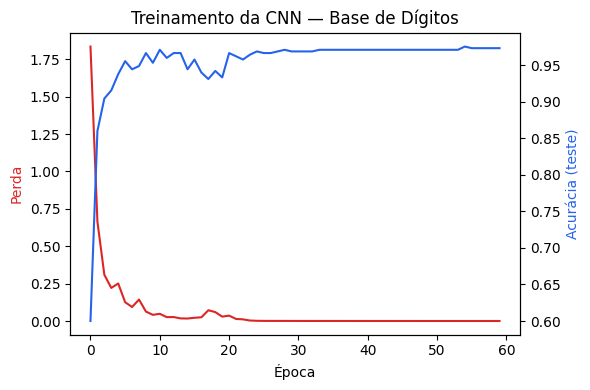

**Figura 9.13:** Curva de treinamento de uma CNN simples na base de dígitos: perda de treinamento e acurácia no conjunto de teste ao longo das épocas.


In [49]:
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0
y = digits.target

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_treino_t = torch.tensor(X_treino).unsqueeze(1)   # (N, 1, 8, 8)
y_treino_t = torch.tensor(y_treino, dtype=torch.long)
X_teste_t = torch.tensor(X_teste).unsqueeze(1)
y_teste_t = torch.tensor(y_teste, dtype=torch.long)

class CNNDigitos(nn.Module):
    # CNN simples: duas camadas convolucionais + pooling, seguidas de camadas densas.
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   # 8x8 -> 8x8, 8 filtros
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)  # 4x4 -> 4x4, 16 filtros
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 2 * 2, 32)
        self.fc2 = nn.Linear(32, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 8x8 -> 4x4
        x = self.pool(self.relu(self.conv2(x)))  # 4x4 -> 2x2
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

modelo_cnn = CNNDigitos()
print(f"Parâmetros treináveis: {sum(p.numel() for p in modelo_cnn.parameters())}")

otimizador = optim.Adam(modelo_cnn.parameters(), lr=1e-2)
criterio = nn.CrossEntropyLoss()

n = X_treino_t.size(0)
tam_lote = 32
epocas = 60
historico_perda, historico_acc = [], []

for epoca in range(epocas):
    modelo_cnn.train()
    perm = torch.randperm(n)
    perda_epoca = 0.0
    for i in range(0, n, tam_lote):
        idx = perm[i:i + tam_lote]
        otimizador.zero_grad()
        saida = modelo_cnn(X_treino_t[idx])
        perda = criterio(saida, y_treino_t[idx])
        perda.backward()
        otimizador.step()
        perda_epoca += perda.item() * len(idx)

    modelo_cnn.eval()
    with torch.no_grad():
        acc_teste = (modelo_cnn(X_teste_t).argmax(dim=1) == y_teste_t).float().mean().item()
    historico_perda.append(perda_epoca / n)
    historico_acc.append(acc_teste)

acc_final_cnn = historico_acc[-1]
print(f"Acurácia final da CNN no conjunto de teste: {acc_final_cnn:.4f}")

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(historico_perda, color="#dc2626", label="Perda (treino)")
ax1.set_xlabel("Época")
ax1.set_ylabel("Perda", color="#dc2626")
ax2 = ax1.twinx()
ax2.plot(historico_acc, color="#2563eb", label="Acurácia (teste)")
ax2.set_ylabel("Acurácia (teste)", color="#2563eb")
plt.title("Treinamento da CNN — Base de Dígitos")
fig.tight_layout()


### 9.6.1 Comparando com o Capítulo 7

A tabela a seguir reúne os resultados obtidos na mesma base de dados, com
as três abordagens estudadas ao longo do livro:

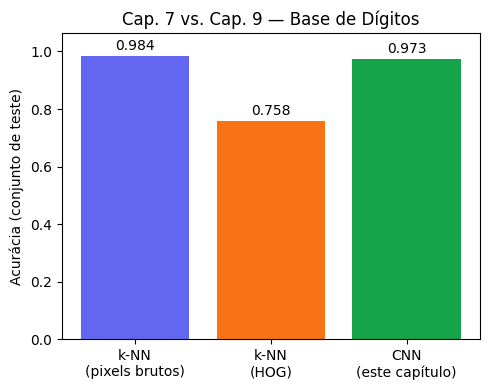

**Figura 9.14:** Comparação de acurácia entre os classificadores clássicos do Capítulo 7 (pixels brutos e HOG com k-NN) e a CNN treinada neste capítulo, na mesma base de dígitos.


In [50]:
# Valores obtidos no Capítulo 7 (k-NN, k=3), reproduzidos aqui para comparação direta
ACC_KNN_PIXELS_CAP7 = 0.9844
ACC_KNN_HOG_CAP7 = 0.7578

metodos = ["k-NN\n(pixels brutos)", "k-NN\n(HOG)", "CNN\n(este capítulo)"]
acuracias = [ACC_KNN_PIXELS_CAP7, ACC_KNN_HOG_CAP7, acc_final_cnn]

plt.figure(figsize=(5, 4))
cores = ["#6366f1", "#f97316", "#16a34a"]
plt.bar(metodos, acuracias, color=cores)
plt.ylim(0, max(acuracias) + 0.08)
plt.ylabel("Acurácia (conjunto de teste)")
plt.title("Cap. 7 vs. Cap. 9 — Base de Dígitos")
for i, v in enumerate(acuracias):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()


> ### 📝 9.7 🧠 Por que funciona? — E por que a CNN nem sempre "ganha"
>
> O resultado observado aqui **repete o padrão já visto no Capítulo 7**: a
> CNN, apesar de aprender automaticamente suas características, não supera
> necessariamente o k-NN com pixels brutos nesta base específica. A
> explicação é a mesma: `load_digits` é uma base pequena (menos de 1800
> exemplos), com imagens já centralizadas, normalizadas e de baixíssima
> resolução ($8\times8$) — condições em que a comparação direta de
> intensidades já é altamente informativa, e há poucos dados para que a
> rede aprenda filtros verdadeiramente superiores aos descritores simples.
>
> O verdadeiro diferencial das CNNs aparece em cenários que descritores
> artesanais e classificadores simples não conseguem endereçar: imagens
> maiores e mais realistas, com milhares de categorias, variação
> substancial de pose, iluminação e fundo, e conjuntos de treinamento
> massivos — exatamente o regime em que os modelos apresentados na seção
> "Aplicações em Larga Escala", mais adiante, foram treinados. A lição
> pedagógica que atravessa os Capítulos 7, 8 e 9 deste livro é consistente:
> **a sofisticação de um método deve ser proporcional à complexidade do
> problema** — usar uma CNN para um problema que um k-NN resolve igualmente
> bem é desperdício de recursos computacionais, não uma virtude.

## 9.8 Transferência de Aprendizado

Treinar uma CNN do zero, como no projeto anterior, exige dados
suficientes para ajustar todos os seus parâmetros de forma confiável —
uma limitação severa quando se dispõe de poucos exemplos rotulados para a
tarefa de interesse. A **transferência de aprendizado** (*transfer
learning*) contorna essa limitação reaproveitando um extrator de
características já treinado em uma tarefa relacionada:

1. Treina-se (ou obtém-se já treinada) uma CNN em uma tarefa de origem,
   tipicamente com muitos dados disponíveis;
2. As camadas convolucionais iniciais — que tendem a aprender
   características gerais, como bordas e texturas, pouco específicas da
   tarefa de origem — são **congeladas** (seus pesos deixam de ser
   atualizados);
3. Apenas as camadas finais (geralmente a(s) camada(s) totalmente
   conectada(s)) são substituídas e **treinadas do zero** para a nova
   tarefa, com muito menos dados e muito menos tempo de treinamento do
   que seriam necessários para treinar a rede inteira.

Esse princípio é o motivo pelo qual modelos pré-treinados em bases
massivas, como a ImageNet (mais de um milhão de imagens em mil
categorias), tornaram-se o ponto de partida padrão de praticamente
qualquer projeto moderno de visão computacional, mesmo quando a tarefa
final é bastante diferente da classificação de objetos genéricos.

Acurácia no domínio de origem A (dígitos 0-4): 1.0000
Domínio de destino B (dígitos 5-9), apenas 20 exemplos de treino:
  Com transferência (extrator congelado): 0.7277
  Treinando do zero (mesmos dados/épocas): 0.6786


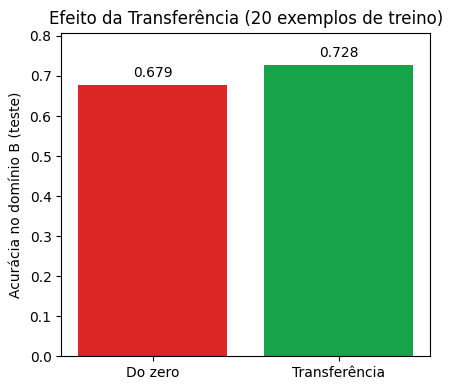

**Figura 9.15:** Comparação de acurácia entre treinar do zero e reaproveitar (transferir) um extrator de características já treinado, ambos com o mesmo pequeno número de exemplos rotulados na tarefa de destino.


In [51]:
# Divide as classes de dígitos em dois domínios disjuntos:
# Domínio A (0-4): usado para treinar o extrator de características "pré-treinado"
# Domínio B (5-9): tarefa de destino, com poucos dados disponíveis
classes_A, classes_B = [0, 1, 2, 3, 4], [5, 6, 7, 8, 9]
mask_A, mask_B = np.isin(y, classes_A), np.isin(y, classes_B)
XA, yA = X[mask_A], y[mask_A]
XB, yB = X[mask_B], y[mask_B] - 5  # reindexa para 0..4

XA_tr, XA_te, yA_tr, yA_te = train_test_split(XA, yA, test_size=0.25, random_state=42, stratify=yA)
XB_tr, XB_te, yB_tr, yB_te = train_test_split(XB, yB, test_size=0.25, random_state=42, stratify=yB)

# Simula escassez de dados no domínio de destino: apenas 20 exemplos rotulados
rng = np.random.default_rng(0)
idx_poucos = rng.choice(len(XB_tr), size=20, replace=False)
XB_tr_poucos, yB_tr_poucos = XB_tr[idx_poucos], yB_tr[idx_poucos]

def para_tensor(Ximg, yarr):
    return torch.tensor(Ximg).unsqueeze(1), torch.tensor(yarr, dtype=torch.long)

XA_tr_t, yA_tr_t = para_tensor(XA_tr, yA_tr)
XA_te_t, yA_te_t = para_tensor(XA_te, yA_te)
XB_tr_t, yB_tr_t = para_tensor(XB_tr_poucos, yB_tr_poucos)
XB_te_t, yB_te_t = para_tensor(XB_te, yB_te)

class ExtratorConv(nn.Module):
    # Bloco convolucional reaproveitável entre tarefas.
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        return x.view(x.size(0), -1)

class CNNCompleta(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extrator = ExtratorConv()
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.extrator(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

def treinar(modelo, X_t, y_t, epocas, lr, tam_lote=16, parametros=None):
    params = parametros if parametros is not None else modelo.parameters()
    otim = optim.Adam(params, lr=lr)
    crit = nn.CrossEntropyLoss()
    n_amostras = X_t.size(0)
    for _ in range(epocas):
        perm = torch.randperm(n_amostras)
        for i in range(0, n_amostras, tam_lote):
            idx = perm[i:i + tam_lote]
            otim.zero_grad()
            perda = crit(modelo(X_t[idx]), y_t[idx])
            perda.backward()
            otim.step()

def calcular_acuracia(modelo, X_t, y_t):
    modelo.eval()
    with torch.no_grad():
        pred = modelo(X_t).argmax(dim=1)
    return (pred == y_t).float().mean().item()

# 1) Treina o modelo "de origem" no domínio A
modelo_origem = CNNCompleta(n_classes=5)
treinar(modelo_origem, XA_tr_t, yA_tr_t, epocas=40, lr=1e-2)
print(f"Acurácia no domínio de origem A (dígitos 0-4): {calcular_acuracia(modelo_origem, XA_te_t, yA_te_t):.4f}")

# 2) Transferência: reaproveita o extrator (congelado), treina apenas a nova cabeça
modelo_transferencia = CNNCompleta(n_classes=5)
modelo_transferencia.extrator.load_state_dict(modelo_origem.extrator.state_dict())
for p in modelo_transferencia.extrator.parameters():
    p.requires_grad = False

treinar(
    modelo_transferencia, XB_tr_t, yB_tr_t, epocas=40, lr=1e-2,
    parametros=list(modelo_transferencia.fc1.parameters()) + list(modelo_transferencia.fc2.parameters())
)
acc_transferencia = calcular_acuracia(modelo_transferencia, XB_te_t, yB_te_t)

# 3) Do zero: mesmo pouco dado, mesmas épocas, mas sem reaproveitar nada
modelo_do_zero = CNNCompleta(n_classes=5)
treinar(modelo_do_zero, XB_tr_t, yB_tr_t, epocas=40, lr=1e-2)
acc_do_zero = calcular_acuracia(modelo_do_zero, XB_te_t, yB_te_t)

print(f"Domínio de destino B (dígitos 5-9), apenas {len(XB_tr_poucos)} exemplos de treino:")
print(f"  Com transferência (extrator congelado): {acc_transferencia:.4f}")
print(f"  Treinando do zero (mesmos dados/épocas): {acc_do_zero:.4f}")

plt.figure(figsize=(4.5, 4))
plt.bar(["Do zero", "Transferência"], [acc_do_zero, acc_transferencia], color=["#dc2626", "#16a34a"])
plt.ylim(0, max([acc_do_zero, acc_transferencia]) + 0.08)
plt.ylabel("Acurácia no domínio B (teste)")
plt.title(f"Efeito da Transferência ({len(XB_tr_poucos)} exemplos de treino)")
for i, v in enumerate([acc_do_zero, acc_transferencia]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()


> ### 📝 9.9 🧠 Por que funciona? — E quando não funciona
>
> Com apenas 20 exemplos rotulados no domínio de destino, o modelo treinado
> do zero mal consegue superar um classificador aleatório — não há dados
> suficientes para ajustar todos os parâmetros da rede de forma confiável.
> O modelo com transferência de aprendizado, por outro lado, já parte de um
> extrator de características capaz de identificar bordas, curvas e traços
> característicos de dígitos manuscritos em geral (aprendidos a partir dos
> dígitos 0–4) — restando à nova cabeça apenas a tarefa, muito mais simples,
> de aprender a combinar essas características já úteis para distinguir os
> dígitos 5–9.
>
> **Quando a transferência ajuda:** quando a tarefa de origem e a de
> destino compartilham estatísticas visuais de baixo e médio nível — o que
> é razoável esperar entre dígitos manuscritos diferentes, como neste
> experimento, ou, mais amplamente, entre a maioria das imagens naturais e
> uma tarefa de nicho.
>
> **Quando a transferência falha ou até prejudica** (fenômeno conhecido
> como *transferência negativa*): quando o domínio de origem é
> excessivamente diferente do domínio de destino — por exemplo, transferir
> um extrator treinado em fotografias naturais para radiografias médicas ou
> imagens de satélite pode não trazer benefício algum, e em alguns casos
> até atrapalhar, se as características de baixo nível relevantes forem
> muito distintas entre os dois domínios. Nesses casos, um ajuste fino
> (*fine-tuning*) parcial das camadas convolucionais — em vez de
> congelá-las por completo — costuma produzir melhores resultados.

## 9.10 Aplicações em Larga Escala com Modelos Pré-treinados

Os experimentos anteriores utilizaram CNNs pequenas, treinadas em minutos
em uma base de poucas centenas de exemplos. Na prática profissional, é
extremamente comum utilizar diretamente modelos **já treinados** em bases
massivas — como a ImageNet, com mais de um milhão de imagens em mil
categorias — como ponto de partida (via transferência de aprendizado) ou
mesmo diretamente, sem qualquer re-treinamento.

> ### ❗ Importante
>
> As células desta seção **não são executadas automaticamente** neste
> notebook: o carregamento desses modelos exige o download de pesos
> pré-treinados (centenas de megabytes) diretamente dos servidores do
> PyTorch, o que requer conexão à internet no ambiente de execução. O
> código é apresentado tal como seria executado em um ambiente com
> conectividade, para fins de referência.

### 9.10.1 Classificação de Imagens

O padrão de uso é sempre o mesmo: carregar a arquitetura com pesos
pré-treinados e, para uma nova tarefa, substituir apenas a camada final,
como discutido na seção de transferência de aprendizado.

In [52]:
import torchvision.models as models

# Carrega uma ResNet-18 pré-treinada na ImageNet (requer internet)
modelo_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Transferência de aprendizado: congela o extrator de características
for parametro in modelo_resnet.parameters():
    parametro.requires_grad = False

# Substitui a camada final (originalmente 1000 classes da ImageNet)
# por uma nova camada adequada à tarefa de destino (ex.: 3 classes)
n_classes_destino = 3
modelo_resnet.fc = nn.Linear(modelo_resnet.fc.in_features, n_classes_destino)

# A partir daqui, apenas `modelo_resnet.fc` seria treinada com os dados da nova tarefa


### 9.10.2 Detecção de Objetos

Modelos como o **Faster R-CNN**, apresentado no Capítulo 8, estão
disponíveis prontos para uso, já treinados para detectar até 91
categorias de objetos comuns (base COCO):

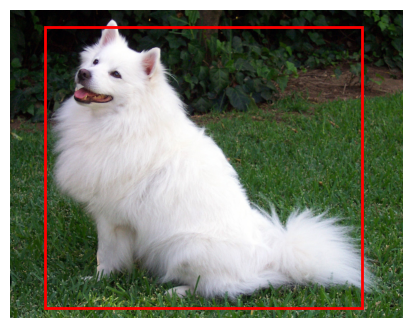

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms.functional import to_tensor

from PIL import Image
from urllib.request import urlopen

img = Image.open(urlopen(
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
)).convert("RGB")
modelo = fasterrcnn_resnet50_fpn(weights="DEFAULT").eval()

with torch.no_grad():
    pred = modelo([to_tensor(img)])[0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(img)

for box, score in zip(pred["boxes"], pred["scores"]):
    if score < 0.8:
        continue
    x1, y1, x2, y2 = box.numpy()
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   fill=False, edgecolor="red", linewidth=2))

ax.set_axis_off()
plt.show()

### 9.10.3 Segmentação Semântica

De forma análoga, modelos de segmentação semântica pré-treinados retornam
diretamente um mapa de classes por pixel:

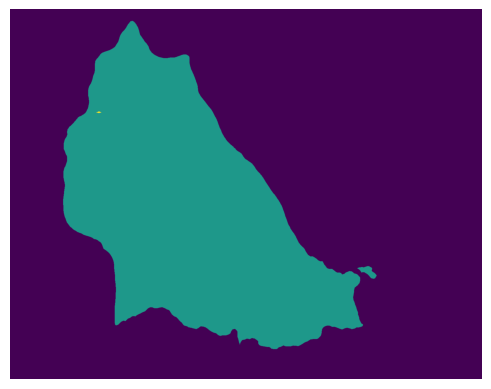

In [54]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from urllib.request import urlopen
from torchvision.transforms.functional import to_tensor
from torchvision.models.segmentation import deeplabv3_resnet50

img = Image.open(urlopen(
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
)).convert("RGB")

modelo = deeplabv3_resnet50(weights="DEFAULT").eval()

with torch.no_grad():
    mapa = modelo(to_tensor(img).unsqueeze(0))["out"].argmax(1).squeeze()

plt.imshow(mapa)
plt.axis("off")
plt.show()

## 9.11 Projeto Prático 2: Detecção de Objetos com YOLO e Transferência de Aprendizado

A subseção anterior mostrou, por meio do **Faster R-CNN**, um modelo de
detecção pré-treinado sendo usado "como está", sem qualquer re-treinamento. O
Faster R-CNN pertence à família de detectores **de dois estágios**: uma
primeira rede propõe regiões candidatas a conter um objeto (*region
proposals*) e uma segunda rede classifica e refina cada região — a mesma
lógica de "propor, depois verificar" já discutida no Capítulo 8 a propósito
do Haar Cascade em cascata.

A família **YOLO** (*You Only Look Once*) segue uma filosofia distinta, de
**um único estágio**: a imagem é dividida conceitualmente em uma grade, e uma
única rede convolucional prevê, em uma única passagem direta, as caixas
delimitadoras, a confiança de haver um objeto e a classe de cada região —
sem uma etapa separada de proposta de regiões. Essa simplificação é o que
torna a família YOLO especialmente adequada à detecção **em tempo real**,
citada na seção de encerramento deste capítulo como uma das direções naturais
de aprofundamento.

Nesta seção, o princípio de **transferência de aprendizado** — já
demonstrado para classificação, com uma CNN pequena treinada nos dígitos do
Capítulo 7 — é aplicado a uma **tarefa de detecção**: partindo de um YOLO
pré-treinado na base COCO (fotografias naturais, 80 categorias), o modelo é
ajustado (*fine-tuned*) para uma tarefa de detecção bastante diferente —
localizar e classificar **objetos geométricos sintéticos** (triângulos,
quadrados, estrelas, etc.), variando em cor, tamanho e rotação.

### 9.11.1 Gerando um Conjunto de Dados Sintético de Objetos Geométricos

O cenário reproduzido aqui é inspirado em uma avaliação prática comum em
disciplinas de Visão Computacional: dado um conjunto de imagens contendo
objetos geométricos gerados aleatoriamente, treinar um detector capaz de
localizar e classificar cada objeto em nove classes:

```python
classes = ['Triangle', 'Square', 'Pentagon', 'Hexagon',
           'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross']
```

Cada objeto varia aleatoriamente em **cor**, **tamanho** e **rotação**, e
cada imagem pode conter um ou mais objetos. Para cada imagem, um arquivo TXT
associado descreve, em uma linha por objeto, a classe e a caixa delimitadora
no **formato YOLO**: a classe seguida de quatro valores normalizados entre 0
e 1 — centro em $x$, centro em $y$, largura e altura, todos expressos como
fração da largura ou da altura da imagem, por exemplo:

```
0 0.2895 0.2007 0.3750 0.2862
```

Essa é exatamente a convenção de anotação esperada pelas bibliotecas de
treinamento de YOLO (como a `ultralytics`, usada a seguir) — de modo que, caso
o leitor tenha acesso a um conjunto de imagens reais anotado neste mesmo
formato, basta organizá-lo na estrutura de pastas descrita adiante para
reutilizar todo o restante do código sem qualquer alteração.

Como não há, neste notebook, acesso a um conjunto de imagens reais, o código
a seguir **gera sinteticamente** um pequeno conjunto de dados com as mesmas
características do cenário descrito: formas geométricas com cor, tamanho e
rotação aleatórios, desenhadas com o OpenCV, já anotadas no formato YOLO.

Dataset sintético gerado: 90 imagens de treino, 20 de validação.


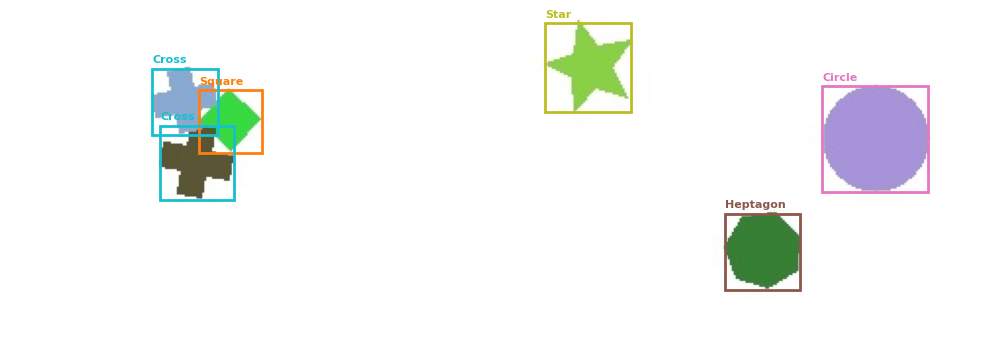

**Figura 9.16:** Amostras do conjunto de dados sintético de objetos geométricos, com as caixas delimitadoras no formato YOLO sobrepostas.


In [55]:
import os, random

CLASSES = ['Triangle', 'Square', 'Pentagon', 'Hexagon',
           'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross']
N_LADOS = {'Triangle': 3, 'Square': 4, 'Pentagon': 5, 'Hexagon': 6, 'Heptagon': 7}


def poligono_regular(cx, cy, r, n_lados, rot_graus):
    ang0 = np.deg2rad(rot_graus - 90)
    angs = ang0 + 2 * np.pi * np.arange(n_lados) / n_lados
    return np.stack([cx + r * np.cos(angs), cy + r * np.sin(angs)], axis=1)


def poligono_estrela(cx, cy, r_externo, rot_graus, n_pontas=5):
    r_interno = r_externo * 0.45
    ang0 = np.deg2rad(rot_graus - 90)
    angs = ang0 + np.pi * np.arange(2 * n_pontas) / n_pontas
    raios = np.where(np.arange(2 * n_pontas) % 2 == 0, r_externo, r_interno)
    return np.stack([cx + raios * np.cos(angs), cy + raios * np.sin(angs)], axis=1)


def poligono_cruz(cx, cy, r, rot_graus, espessura_rel=0.35):
    w = r * espessura_rel
    base = np.array([
        (-w, -r), (w, -r), (w, -w), (r, -w), (r, w), (w, w),
        (w, r), (-w, r), (-w, w), (-r, w), (-r, -w), (-w, -w),
    ])
    theta = np.deg2rad(rot_graus)
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return base @ R.T + np.array([cx, cy])


def desenha_objeto(img, classe_idx, cx, cy, tamanho, rotacao, cor):
    nome = CLASSES[classe_idx]
    if nome in N_LADOS:
        pts = poligono_regular(cx, cy, tamanho, N_LADOS[nome], rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Star':
        pts = poligono_estrela(cx, cy, tamanho, rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Cross':
        pts = poligono_cruz(cx, cy, tamanho, rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Circle':
        cv2.circle(img, (int(cx), int(cy)), int(tamanho), cor, -1)
        xs, ys = np.array([cx - tamanho, cx + tamanho]), np.array([cy - tamanho, cy + tamanho])
    else:  # Ellipse
        eixo = (int(tamanho), int(tamanho * 0.6))
        cv2.ellipse(img, (int(cx), int(cy)), eixo, rotacao, 0, 360, cor, -1)
        ang = np.deg2rad(rotacao)
        dx = np.hypot(eixo[0] * np.cos(ang), eixo[1] * np.sin(ang))
        dy = np.hypot(eixo[0] * np.sin(ang), eixo[1] * np.cos(ang))
        xs, ys = np.array([cx - dx, cx + dx]), np.array([cy - dy, cy + dy])
    return xs.min(), ys.min(), xs.max(), ys.max()


def gera_imagem(tam_img=160, n_objetos=(1, 3), rng=None):
    rng = rng or random.Random()
    img = np.full((tam_img, tam_img, 3), 255, dtype=np.uint8)
    anotacoes = []
    for _ in range(rng.randint(*n_objetos)):
        classe_idx = rng.randrange(len(CLASSES))
        tamanho = rng.randint(tam_img // 10, tam_img // 5)
        cx = rng.randint(tamanho + 2, tam_img - tamanho - 2)
        cy = rng.randint(tamanho + 2, tam_img - tamanho - 2)
        rotacao = rng.uniform(0, 360)
        cor = tuple(rng.sample(range(30, 226), 3))
        x0, y0, x1, y1 = desenha_objeto(img, classe_idx, cx, cy, tamanho, rotacao, cor)
        x0, y0 = max(x0, 0), max(y0, 0)
        x1, y1 = min(x1, tam_img), min(y1, tam_img)
        xc, yc = (x0 + x1) / 2 / tam_img, (y0 + y1) / 2 / tam_img
        w, h = (x1 - x0) / tam_img, (y1 - y0) / tam_img
        anotacoes.append((classe_idx, xc, yc, w, h))
    return img, anotacoes


# Monta o conjunto de dados no formato esperado pela biblioteca `ultralytics`:
# shapes_dataset/{images,labels}/{train,val}/*.{jpg,txt} + data.yaml
base_dir = "shapes_dataset"
rng_global = random.Random(42)
for split, n_imgs in [("train", 90), ("val", 20)]:
    os.makedirs(f"{base_dir}/images/{split}", exist_ok=True)
    os.makedirs(f"{base_dir}/labels/{split}", exist_ok=True)
    for i in range(n_imgs):
        img, anotacoes = gera_imagem(rng=rng_global)
        cv2.imwrite(f"{base_dir}/images/{split}/{i:04d}.jpg", img)
        with open(f"{base_dir}/labels/{split}/{i:04d}.txt", "w") as f:
            for c, xc, yc, w, h in anotacoes:
                f.write(f"{c} {xc:.4f} {yc:.4f} {w:.4f} {h:.4f}\n")

with open(f"{base_dir}/data.yaml", "w") as f:
    f.write(f"path: {os.path.abspath(base_dir)}\ntrain: images/train\nval: images/val\nnames:\n")
    for i, nome in enumerate(CLASSES):
        f.write(f"  {i}: {nome}\n")

print("Dataset sintético gerado: 90 imagens de treino, 20 de validação.")

# Visualiza três amostras com as caixas delimitadoras sobrepostas
fig, axs = plt.subplots(1, 3, figsize=(10, 3.5))
cores_plot = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))
for ax, i in zip(axs, [0, 1, 2]):
    img = cv2.cvtColor(cv2.imread(f"{base_dir}/images/train/{i:04d}.jpg"), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    tam_img = img.shape[0]
    with open(f"{base_dir}/labels/train/{i:04d}.txt") as f:
        for linha in f:
            c, xc, yc, w, h = map(float, linha.split())
            c = int(c)
            x0, y0 = (xc - w / 2) * tam_img, (yc - h / 2) * tam_img
            ax.add_patch(plt.Rectangle((x0, y0), w * tam_img, h * tam_img,
                                        fill=False, edgecolor=cores_plot[c], linewidth=2))
            ax.text(x0, max(y0 - 3, 0), CLASSES[c], color=cores_plot[c], fontsize=8, weight="bold")
    ax.set_axis_off()
plt.tight_layout()
plt.show()

### 9.11.2 Ajuste Fino de um YOLO Pré-treinado

A biblioteca `ultralytics` fornece uma interface de alto nível para carregar
arquiteturas YOLO com pesos pré-treinados na base COCO e ajustá-las
(*fine-tuning*) a uma nova tarefa — exatamente o padrão de transferência de
aprendizado já discutido para classificação, mas agora aplicado à detecção:
em vez de apenas substituir a última camada, a cabeça de detecção é
reconfigurada para as novas classes (nove formas geométricas em vez de 80
categorias da COCO), e o treinamento é conduzido por poucas épocas sobre o
conjunto de dados sintético.

> ### ❗ Importante
>
> A célula a seguir **não é executada automaticamente** neste notebook: o
> carregamento do modelo pré-treinado exige o download de seus pesos a partir
> dos servidores da Ultralytics/GitHub, o que requer conexão à internet no
> ambiente de execução, além da instalação da biblioteca `ultralytics`. Em um
> ambiente com GPU, o treinamento abaixo (15 épocas, ~110 imagens de
> $160\times160$) leva menos de um minuto; em CPU, alguns minutos.

In [56]:
try:
    from ultralytics import YOLO
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics"], check=True)
    from ultralytics import YOLO

# Carrega o YOLOv8-nano com pesos pré-treinados na base COCO (transferência de aprendizado)
modelo_yolo = YOLO("yolov8n.pt")

# Ajuste fino: `freeze=10` mantém congeladas as 10 primeiras camadas do backbone
# (características genéricas de baixo nível, como bordas e contornos), treinando
# apenas as camadas finais e a cabeça de detecção para as novas 9 classes —
# o mesmo princípio de congelamento parcial discutido no Exercício 3.
resultados = modelo_yolo.train(
    data="shapes_dataset/data.yaml",
    epochs=15,
    imgsz=160,
    batch=8,
    freeze=10,
    verbose=False,
    plots=False,
)

metricas = modelo_yolo.val()
print(f"mAP50 no conjunto de validação: {metricas.box.map50:.3f}")

New https://pypi.org/project/ultralytics/8.4.107 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.13.5 torch-2.12.1+cpu CPU (Intel Core i7-4870HQ 2.50GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=shapes_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=160, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tra

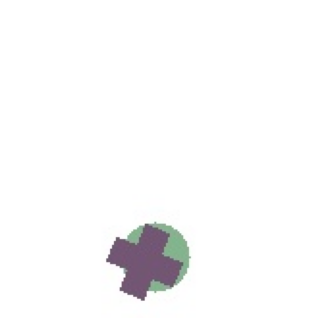

**Figura 9.17:** Detecções do YOLO ajustado por transferência de aprendizado em uma imagem de validação não vista durante o treinamento.


In [57]:
resultado = modelo_yolo.predict("shapes_dataset/images/val/0000.jpg", conf=0.4, verbose=False)[0]

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cv2.cvtColor(resultado.orig_img, cv2.COLOR_BGR2RGB))
for box in resultado.boxes:
    x0, y0, x1, y1 = box.xyxy[0].tolist()
    classe, conf = CLASSES[int(box.cls)], float(box.conf)
    ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                fill=False, edgecolor="red", linewidth=2))
    ax.text(x0, max(y0 - 3, 0), f"{classe} {conf:.2f}", color="red", fontsize=8, weight="bold")
ax.set_axis_off()
plt.show()

In [58]:
import os
from ultralytics import YOLO

# 1. Definição das classes do problema geométrico
CLASSES_GEOMETRICAS = [
    'Triangle', 'Square', 'Pentagon', 'Hexagon', 
    'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross'
]

# 2. Configuração do arquivo de dados (dataset.yaml) exigido pelo YOLO
yaml_content = """
train: ./shapes_dataset/images/train
val: ./shapes_dataset/images/val

nc: 9
names: ['Triangle', 'Square', 'Pentagon', 'Hexagon', 'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross']
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)

# 3. Carrega um modelo YOLO nano pré-treinado (Extrator de características congelado/inicializado)
# O sufixo 'n' indica a versão mais leve, ideal para restrições computacionais
modelo_yolo = YOLO("yolov8n.pt") 

# 4. Transferência de Aprendizado / Ajuste Fino (Fine-tuning)
# O framework adapta automaticamente a camada de saída para 9 classes
resultados = modelo_yolo.train(
    data="dataset.yaml",
    epochs=4,
    imgsz=640,
    batch=16,
    device=device # Reaproveita a variável 'device' configurada no início do capítulo
)


New https://pypi.org/project/ultralytics/8.4.107 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.13.5 torch-2.12.1+cpu CPU (Intel Core i7-4870HQ 2.50GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-14, 

In [59]:

# 5. Validação e Inferência em uma imagem de teste
# Exemplo de URL de teste enviada em exames: https://dropbox.com/s/ekjbzp14jt90bfq/00004.jpg
imagem_teste = "./shapes_dataset/images/val/0001.jpg"
predicoes = modelo_yolo(imagem_teste)

# Exibe o resultado visual com as caixas sobrepostas
predicoes[0].show()


image 1/1 /home/fz/fz/VSCode/pdi-vc/all/cap09/shapes_dataset/images/val/0001.jpg: 640x640 (no detections), 90.8ms
Speed: 7.4ms preprocess, 90.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


In [60]:
# --- 1. Instalação e Importação das Bibliotecas ---
# O Ultralytics YOLO é uma biblioteca popular para treino e inferência.
# !pip install ultralytics -q

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path
import torch

# Verificar dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo usado: {device}")

# --- 2. Carregar o Modelo YOLO Pré-treinado ---
# 'yolov8n.pt' é a versão "nano" (mais leve e rápida), pré-treinada no COCO.
# Usaremos seus pesos como ponto de partida (transferência de aprendizado).
modelo = YOLO('yolov8n.pt')
print("Modelo YOLOv8n carregado com sucesso!")

# --- 3. Preparar o Dataset de Objetos Geométricos ---
# Assumimos que você tem uma estrutura de pastas pronta para o YOLO:
# dataset_geometrico/
#   images/
#       00004.jpg, 00005.jpg, ...
#   labels/
#       00004.txt, 00005.txt, ...
#
# O arquivo de label deve estar no formato YOLO:
# <class_id> <x_center> <y_center> <width> <height>
# (todos normalizados entre 0 e 1)

# Exemplo de caminho para o dataset (substitua pelo seu caminho)
caminho_dataset = Path("./shapes_dataset")
caminho_imagens = caminho_dataset / "images"
caminho_rotulos = caminho_dataset / "labels"

# Crie um arquivo data.yaml para descrever o dataset
data_yaml_content = f"""
path: {caminho_dataset.resolve()}
train: images
val: images  # Se você tiver uma pasta separada, use 'images/val'

nc: 9  # Número de classes
names: ['Triangle', 'Square', 'Pentagon', 'Hexagon', 'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross']
"""

# Cria o arquivo data.yaml (se não existir)
data_yaml_path = caminho_dataset / "data.yaml"
if not data_yaml_path.exists():
    data_yaml_path.write_text(data_yaml_content)
    print(f"Arquivo data.yaml criado em: {data_yaml_path}")
else:
    print("Arquivo data.yaml já existe.")

# --- 4. Treinamento com Transferência de Aprendizado ---
# A chave aqui é que os pesos da cabeça de detecção (camadas finais) serão
# re-inicializados, enquanto o extrator de características (backbone) é ajustado.
resultados = modelo.train(
    data=str(data_yaml_path),   # Caminho para o arquivo data.yaml
    epochs=5,                  # Número de épocas (ajuste fino com poucos dados)
    imgsz=640,                  # Tamanho da imagem de entrada
    batch=16,                   # Tamanho do lote
    device=device,              # 'cpu' ou 'cuda'
    project='runs/detect',      # Pasta para salvar resultados
    name='geometricos_yolov8n', # Nome do experimento
    exist_ok=True,              # Sobrescreve se existir
    pretrained=True,            # Usar pesos pré-treinados (já é padrão)
)

print("Treinamento concluído!")
melhor_modelo_path = Path(resultados.save_dir) / "weights" / "best.pt"

# --- 5. Avaliação e Inferência em uma Imagem de Exemplo ---
if melhor_modelo_path.exists():
    # Carrega o melhor modelo treinado
    melhor_modelo = YOLO(str(melhor_modelo_path))

    # Realiza inferência em uma imagem de teste (ex: '00004.jpg')
    caminho_teste = caminho_imagens / "00004.jpg"
    if caminho_teste.exists():
        resultados_pred = melhor_modelo(caminho_teste, conf=0.25)

        # Plota a imagem com as detecções
        for r in resultados_pred:
            # A imagem com as caixas é renderizada no OpenCV
            img_plot = r.plot()  # Retorna um array BGR
            img_plot_rgb = cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(8, 8))
            plt.imshow(img_plot_rgb)
            plt.axis('off')
            plt.title("Detecções YOLO (Transferência)")
            plt.show()

            # Exibe as detecções como texto
            print("\nObjetos Detectados:")
            for box in r.boxes:
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                nome_classe = modelo.names[cls]
                print(f"  - Classe: {nome_classe} (Confiança: {conf:.2f})")
    else:
        print(f"Imagem de teste '{caminho_teste}' não encontrada.")
else:
    print("Modelo treinado não encontrado. Verifique o diretório de saída do treinamento.")

Dispositivo usado: cpu
Modelo YOLOv8n carregado com sucesso!
Arquivo data.yaml já existe.
New https://pypi.org/project/ultralytics/8.4.107 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.87 🚀 Python-3.13.5 torch-2.12.1+cpu CPU (Intel Core i7-4870HQ 2.50GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=shapes_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, 

> ### 📝 9.12 🧠 Um domínio muito mais distante que o dos dígitos
>
> No experimento de transferência de aprendizado entre dígitos manuscritos
> (domínios A e B), a tarefa de origem e a de destino compartilhavam
> estatísticas visuais muito próximas: ambas eram traços em tons de cinza sobre
> fundo uniforme. Aqui, a distância entre domínios é bem maior — o YOLO foi
> pré-treinado em **fotografias naturais coloridas** da COCO (pessoas, animais,
> veículos, objetos do cotidiano), e a tarefa de destino consiste em **formas
> geométricas sintéticas, de cor sólida e contorno bem definido**, sem textura,
> iluminação ou fundo complexo.
>
> Ainda assim, a transferência de aprendizado tende a ajudar: as camadas
> iniciais de um detector treinado na COCO aprendem filtros muito genéricos —
> detectores de bordas, cantos e regiões de contraste — que continuam úteis
> para delimitar o contorno de um triângulo ou de uma estrela, mesmo que o
> conteúdo visual final seja muito diferente. É por isso que o congelamento
> (`freeze=10`) é aplicado apenas às primeiras camadas do backbone: as camadas
> mais profundas, que na COCO aprenderam a reconhecer partes de objetos
> complexos do mundo real (rodas, focinhos, faces), têm pouca serventia direta
> para formas geométricas simples e se beneficiam de serem reajustadas.
>
> Este é o mesmo compromisso discutido no Exercício 3 deste capítulo — entre
> congelar totalmente o extrator, ajustar parcialmente algumas camadas, ou
> treinar tudo do zero — agora observado em uma tarefa de detecção, e com um
> domínio de origem e destino visivelmente mais distantes do que o observado
> entre os dois grupos de dígitos.

### 9.12.1 Usando um Conjunto de Dados Real

O pipeline acima foi construído inteiramente em torno do **formato de
anotação YOLO** (classe, $x_{centro}$, $y_{centro}$, largura, altura,
normalizados pela largura e altura da imagem) exatamente para que ele possa
ser reaproveitado sem alterações caso o leitor tenha acesso a um conjunto de
imagens reais anotado da mesma forma — por exemplo, um conjunto de imagens de
objetos geométricos fotografados ou renderizados, cada um com um arquivo
`.txt` correspondente no mesmo formato usado aqui. Para isso, bastaria:

1. Organizar as imagens reais em `shapes_dataset/images/train` e
   `shapes_dataset/images/val`, e os arquivos `.txt` de anotação
   correspondentes nas pastas `labels/train` e `labels/val` (um arquivo de
   anotação por imagem, mesmo nome-base, extensão `.txt`);
2. Ajustar o arquivo `data.yaml` caso o número ou os nomes das classes sejam
   diferentes;
3. Executar as mesmas células de treinamento, ajuste fino e visualização já
   apresentadas, sem qualquer outra modificação de código.

Essa separação entre **geração/organização dos dados** e **treinamento do
modelo** é, na prática, o motivo pelo qual formatos de anotação padronizados
(como o do YOLO) são tão amplamente adotados: eles permitem trocar o conjunto
de dados de entrada — sintético por real, um domínio por outro — mantendo
inalterado todo o restante do pipeline de transferência de aprendizado.

## 9.13 Projeto Prático 3: Segmentação Semântica com U-Net

A subseção "Segmentação Semântica" mostrou um modelo pré-treinado
(DeepLabV3) produzindo diretamente um rótulo de classe por pixel. Esta
seção completa a sequência de projetos práticos do capítulo —
classificação (Projeto Prático 1) e detecção (Projeto Prático 2) — com a
terceira tarefa fundamental da [Tabela 9.1](#tbl-panorama-tarefas): a segmentação
semântica, agora implementada e treinada do zero com a **U-Net**, a
arquitetura de referência para essa tarefa, introduzida por Ronneberger,
Fischer e Brox (2015) originalmente para imagens biomédicas.

A diferença estrutural em relação à CNN de classificação do Projeto
Prático 1 é decisiva. Naquela rede, o mapa de características final era
achatado (*flatten*) em um vetor, descartando toda a informação espacial
em favor de um único rótulo por imagem. Uma U-Net, ao contrário, precisa
produzir uma saída com a **mesma resolução espacial da entrada**: um mapa
em que cada pixel recebe sua própria classificação. Essa exigência —
preservar detalhe espacial de alta resolução até a última camada, ao
mesmo tempo em que se constrói contexto semântico mais amplo em camadas
intermediárias — motiva a arquitetura de codificador-decodificador
descrita a seguir.

O cenário utilizado nesta seção é uma adaptação de um projeto de
segmentação de nódulos em mamografias sintéticas: imagens em tons de
cinza contêm uma região circular (o "nódulo") sobreposta a um fundo, ambos
contaminados pelo mesmo ruído gaussiano e com médias de intensidade
próximas — um cenário deliberadamente pouco discriminável pixel a pixel,
exatamente para tornar visível o ganho trazido pelo aprendizado de
características espaciais, e não apenas locais.

### 9.13.1 Um Conjunto Sintético de Imagens com Nódulos

O gerador a seguir produz pares (imagem, máscara): a imagem contém uma
região circular de intensidade média ligeiramente mais alta que o fundo,
ambas as regiões contaminadas por ruído gaussiano de mesmo desvio-padrão —
de forma que a distinção entre nódulo e fundo não é confiável pixel a
pixel isoladamente, apenas quando se considera a vizinhança espacial em
conjunto. A máscara binária correspondente delimita exatamente a região do
nódulo e serve como alvo de treinamento.

Conjunto de treino: 160 imagens | Conjunto de validação: 40 imagens


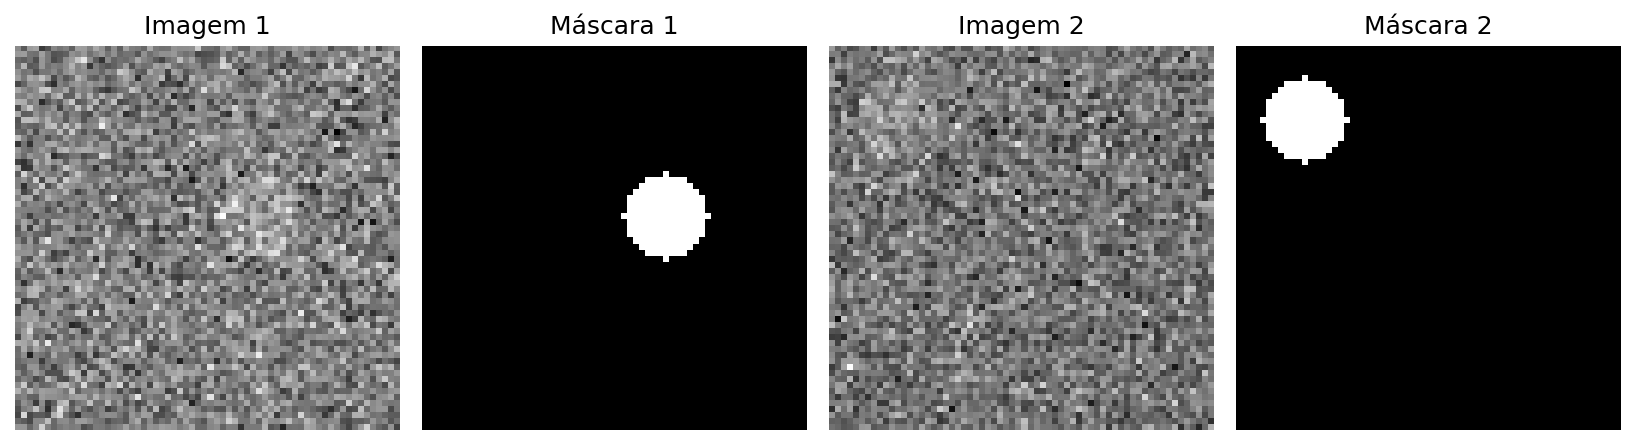

**Figura 9.18:** Amostras do conjunto de dados sintético de nódulos: imagem em tons de cinza (fundo e nódulo com médias de intensidade próximas, sob o mesmo ruído) e máscara binária de referência.


In [61]:
TAM_IMG = 64

def gera_imagem_com_nodulo(tam=TAM_IMG, raio_min=7, raio_max=15, media_fundo=95,
                            media_nodulo=118, sigma_ruido=26, rng=None):
    # Fundo e nódulo compartilham o mesmo ruído gaussiano; apenas a média de
    # intensidade difere, e por pouco -- um cenário de baixo contraste,
    # propositalmente difícil para um método de limiarização simples.
    rng = rng or np.random.default_rng()
    fundo = rng.normal(media_fundo, sigma_ruido, (tam, tam))
    nodulo = rng.normal(media_nodulo, sigma_ruido, (tam, tam))
    mascara = np.zeros((tam, tam), dtype=np.uint8)
    raio = int(rng.integers(raio_min, raio_max))
    cx = int(rng.integers(raio + 4, tam - raio - 4))
    cy = int(rng.integers(raio + 4, tam - raio - 4))
    cv2.circle(mascara, (cx, cy), raio, 255, -1)
    imagem = np.clip(np.where(mascara > 0, nodulo, fundo), 0, 255).astype(np.uint8)
    return imagem, mascara

rng_dados = np.random.default_rng(42)
N_TREINO, N_VAL = 160, 40
imgs_treino, masks_treino = zip(*[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_TREINO)])
imgs_val, masks_val = zip(*[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_VAL)])

print(f"Conjunto de treino: {N_TREINO} imagens | Conjunto de validação: {N_VAL} imagens")

mm.show(
    [imgs_treino[0], masks_treino[0], imgs_treino[1], masks_treino[1]],
    titles=["Imagem 1", "Máscara 1", "Imagem 2", "Máscara 2"],
    cols=4, figsize=(11, 3)
)

### 9.13.2 Linha de Base Clássica: Limiarização com *Kernel* Fixo

Antes de recorrer ao aprendizado, cabe perguntar se um pipeline
inteiramente clássico — construído com a biblioteca `morph`, como nos
capítulos anteriores — já resolve a tarefa. A abordagem mais direta
combina um **borrão gaussiano** (kernel fixo, no espírito do Capítulo 3)
para estimar a intensidade local, uma **limiarização de Otsu** sobre essa
estimativa e uma **abertura morfológica** para remover ruído residual
isolado.

IoU médio (linha de base clássica) no conjunto de validação: 0.7516


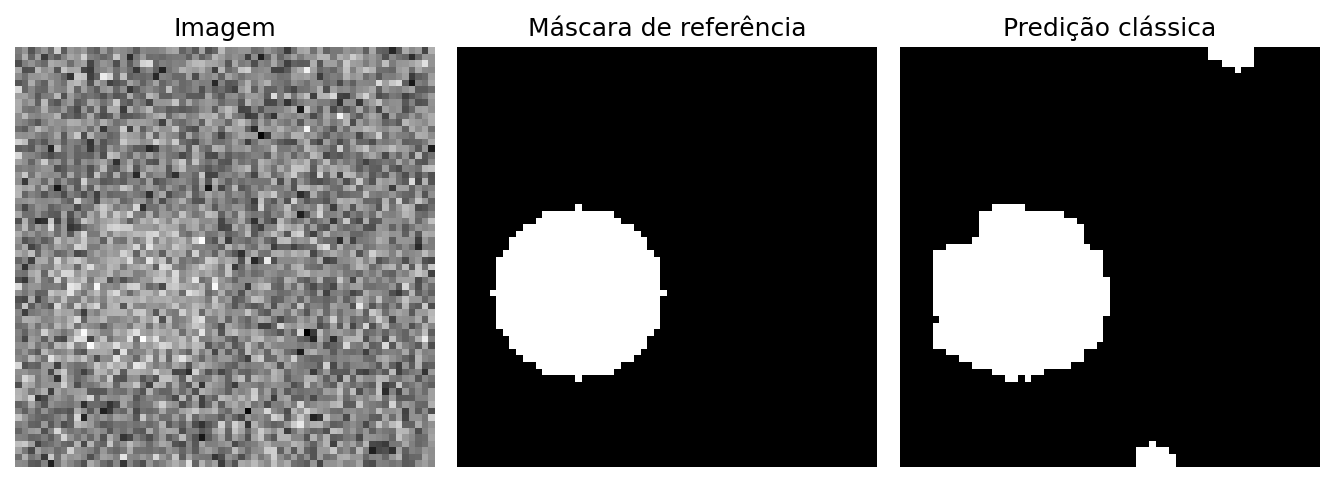

**Figura 9.19:** Linha de base clássica de segmentação: borrão gaussiano, limiarização de Otsu e abertura morfológica, aplicados a uma imagem de validação.


In [62]:
def iou_mascaras(predita, referencia):
    # Interseção sobre união entre duas máscaras binárias, pixel a pixel.
    p, r = predita > 0, referencia > 0
    intersecao = np.logical_and(p, r).sum()
    uniao = np.logical_or(p, r).sum()
    return intersecao / uniao if uniao else 1.0

def segmenta_classico(imagem, elemento_estrutural):
    suavizada = mm.blur(imagem, 7)
    binaria = mm.threshold(suavizada)
    return mm.open(binaria, elemento_estrutural)

elemento_estrutural = mm.sedisk(5)
ious_classico = [
    iou_mascaras(segmenta_classico(img, elemento_estrutural), mask)
    for img, mask in zip(imgs_val, masks_val)
]
iou_classico_medio = float(np.mean(ious_classico))
print(f"IoU médio (linha de base clássica) no conjunto de validação: {iou_classico_medio:.4f}")

predicao_classica_exemplo = segmenta_classico(imgs_val[0], elemento_estrutural)
mm.show(
    [imgs_val[0], masks_val[0], predicao_classica_exemplo],
    titles=["Imagem", "Máscara de referência", "Predição clássica"],
    cols=3, figsize=(9, 3.2)
)

### 9.13.3 Arquitetura U-Net: Codificador-Decodificador com Conexões de Atalho

O **codificador** repete a mesma lógica de convolução seguida de
*pooling* já vista no Projeto Prático 1: cada estágio reduz a resolução
espacial pela metade e dobra o número de canais, construindo
progressivamente características mais abstratas. Na U-Net, porém, esse
processo é espelhado por um **decodificador** simétrico, que reconstrói a
resolução original por meio de convoluções transpostas (*upsampling*
aprendido).

A diferença essencial em relação a um simples codificador-decodificador
está nas **conexões de atalho** (*skip connections*): em cada estágio do
decodificador, o mapa de características do codificador na mesma
resolução — capturado *antes* do *pooling* correspondente — é concatenado
ao resultado do *upsampling*. Isso reinjeta diretamente o detalhe espacial
de fronteiras e contornos, que seria perdido pelas sucessivas reduções de
resolução, permitindo que a rede combine o contexto semântico amplo
construído na base ("existe um nódulo nesta região?") com a precisão
espacial fina das camadas iniciais ("exatamente onde está sua borda?").

```
Entrada → Codificador (Conv→Conv→Pool) × 3 → Base
                ↳ conexões de atalho reinjetam cada mapa do codificador
                  no estágio de mesma resolução do decodificador ↲
Base → Decodificador (Upsample→Concat→Conv→Conv) × 3 → Saída 1×1 (máscara)
```

Parâmetros treináveis da U-Net compacta: 120681
IoU médio da U-Net no conjunto de validação: 0.8815


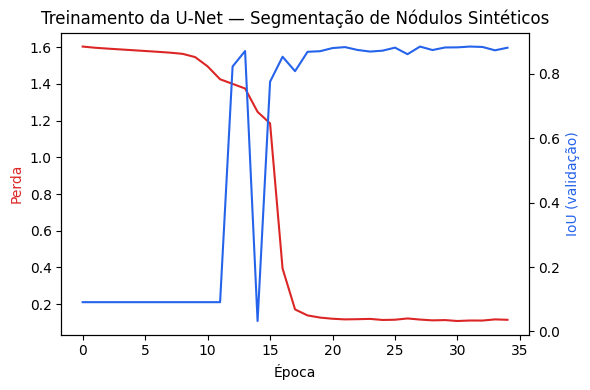

**Figura 9.20:** Curva de treinamento da U-Net compacta: perda de treinamento (entropia cruzada binária combinada à perda Dice) e IoU médio no conjunto de validação ao longo das épocas.


In [63]:
class BlocoConv(nn.Module):
    # Duas convoluções 3x3 + ReLU -- bloco básico repetido em cada estágio da U-Net.
    def __init__(self, canais_entrada, canais_saida):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Conv2d(canais_entrada, canais_saida, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(canais_saida, canais_saida, kernel_size=3, padding=1), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.rede(x)


class UNetCompacta(nn.Module):
    # U-Net reduzida (profundidade 3, poucos canais) -- versão didática, que
    # treina em menos de um minuto em CPU, preservando a estrutura completa
    # de codificador, base e decodificador com conexões de atalho.
    def __init__(self, canais_entrada=1, base=8):
        super().__init__()
        self.enc1 = BlocoConv(canais_entrada, base)
        self.enc2 = BlocoConv(base, base * 2)
        self.enc3 = BlocoConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)

        self.fundo = BlocoConv(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = BlocoConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = BlocoConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = BlocoConv(base * 2, base)

        self.saida = nn.Conv2d(base, 1, kernel_size=1)  # 1 canal: logit de "nódulo"

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        f = self.fundo(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(f), e3], dim=1))    # conexão de atalho com e3
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))   # conexão de atalho com e2
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))   # conexão de atalho com e1
        return self.saida(d1)  # logits; sigmoid aplicado na perda e na predição


def para_tensores(imagens, mascaras):
    X = torch.tensor(np.stack(imagens), dtype=torch.float32).unsqueeze(1) / 255.0
    Y = torch.tensor(np.stack(mascaras), dtype=torch.float32).unsqueeze(1) / 255.0
    return X, Y

def perda_dice(logits, alvo, eps=1e-6):
    # 1 - coeficiente de Dice, a mesma métrica de sobreposição empregada na U-Net original.
    probs = torch.sigmoid(logits)
    intersecao = (probs * alvo).sum(dim=(1, 2, 3))
    uniao = probs.sum(dim=(1, 2, 3)) + alvo.sum(dim=(1, 2, 3))
    dice = (2 * intersecao + eps) / (uniao + eps)
    return 1 - dice.mean()

def perda_segmentacao(logits, alvo):
    return nn.functional.binary_cross_entropy_with_logits(logits, alvo) + perda_dice(logits, alvo)

modelo_unet = UNetCompacta()
print(f"Parâmetros treináveis da U-Net compacta: {sum(p.numel() for p in modelo_unet.parameters())}")

X_treino_unet, Y_treino_unet = para_tensores(imgs_treino, masks_treino)
X_val_unet, Y_val_unet = para_tensores(imgs_val, masks_val)

otimizador_unet = optim.Adam(modelo_unet.parameters(), lr=1e-3)
n = X_treino_unet.size(0)
tam_lote = 16
epocas_unet = 35
historico_perda_unet, historico_iou_unet = [], []

for epoca in range(epocas_unet):
    modelo_unet.train()
    perm = torch.randperm(n)
    perda_epoca = 0.0
    for i in range(0, n, tam_lote):
        idx = perm[i:i + tam_lote]
        otimizador_unet.zero_grad()
        logits = modelo_unet(X_treino_unet[idx])
        perda = perda_segmentacao(logits, Y_treino_unet[idx])
        perda.backward()
        otimizador_unet.step()
        perda_epoca += perda.item() * len(idx)

    modelo_unet.eval()
    with torch.no_grad():
        predicao_val = (torch.sigmoid(modelo_unet(X_val_unet)) > 0.5).float()
        intersecao = (predicao_val * Y_val_unet).sum(dim=(1, 2, 3))
        uniao = ((predicao_val + Y_val_unet) > 0).float().sum(dim=(1, 2, 3))
        iou_epoca = (intersecao / uniao.clamp(min=1e-6)).mean().item()
    historico_perda_unet.append(perda_epoca / n)
    historico_iou_unet.append(iou_epoca)

iou_unet_final = historico_iou_unet[-1]
print(f"IoU médio da U-Net no conjunto de validação: {iou_unet_final:.4f}")

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(historico_perda_unet, color="#dc2626", label="Perda (treino)")
ax1.set_xlabel("Época")
ax1.set_ylabel("Perda", color="#dc2626")
ax2 = ax1.twinx()
ax2.plot(historico_iou_unet, color="#2563eb", label="IoU (validação)")
ax2.set_ylabel("IoU (validação)", color="#2563eb")
plt.title("Treinamento da U-Net — Segmentação de Nódulos Sintéticos")
fig.tight_layout()

### 9.13.4 Comparando com a Linha de Base Clássica

Com ambos os métodos avaliados no mesmo conjunto de validação, sob a
mesma métrica, a comparação a seguir reproduz o formato já utilizado na
comparação entre Capítulo 7 e a CNN de classificação: uma linha de base
projetada manualmente contra o resultado aprendido a partir dos dados.

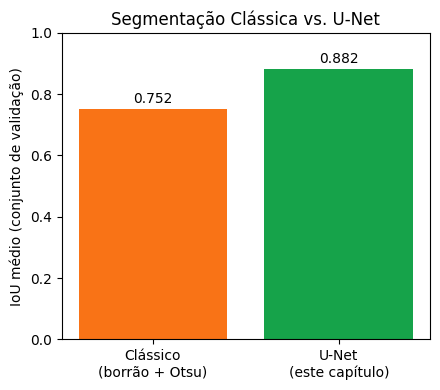

**Figura 9.21:** Comparação entre a linha de base clássica (borrão + Otsu + abertura) e a U-Net treinada: IoU médio no conjunto de validação e predições lado a lado em três exemplos.


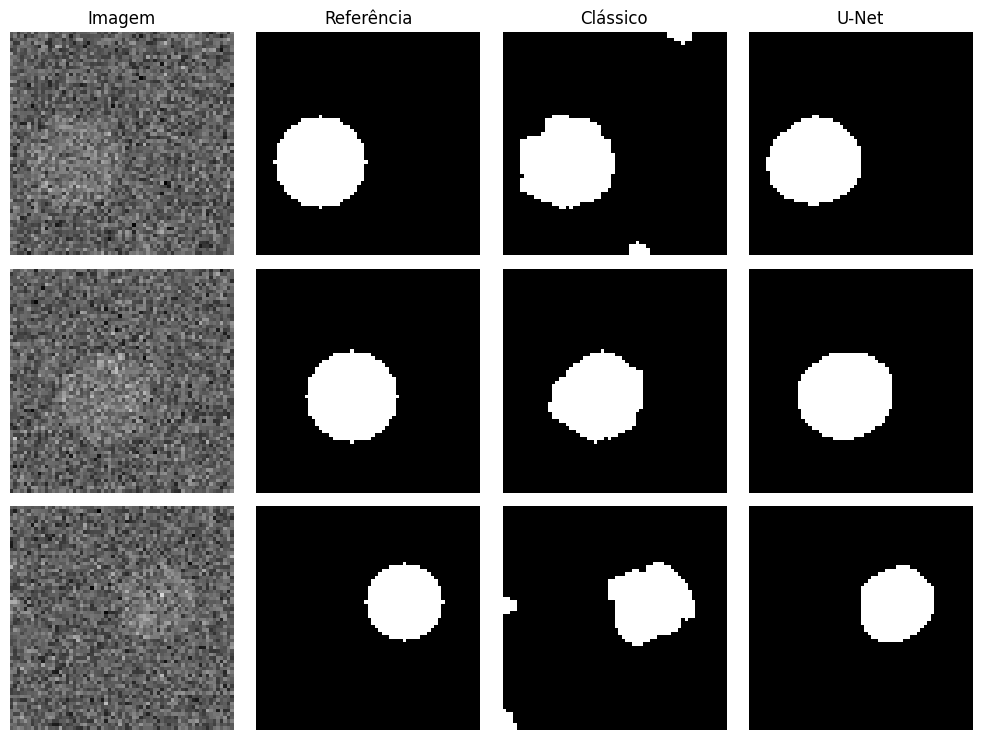

In [64]:
metodos_seg = ["Clássico\n(borrão + Otsu)", "U-Net\n(este capítulo)"]
ious_medios = [iou_classico_medio, iou_unet_final]

plt.figure(figsize=(4.5, 4))
plt.bar(metodos_seg, ious_medios, color=["#f97316", "#16a34a"])
plt.ylim(0, 1.0)
plt.ylabel("IoU médio (conjunto de validação)")
plt.title("Segmentação Clássica vs. U-Net")
for i, v in enumerate(ious_medios):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

# Predições lado a lado em três exemplos de validação
fig, axs = plt.subplots(3, 4, figsize=(10, 7.5))
for linha, i in enumerate([0, 1, 2]):
    with torch.no_grad():
        pred_unet = (torch.sigmoid(modelo_unet(X_val_unet[i:i+1])) > 0.5).float().squeeze().numpy() * 255
    pred_classico = segmenta_classico(imgs_val[i], elemento_estrutural)
    imagens_linha = [imgs_val[i], masks_val[i], pred_classico, pred_unet.astype(np.uint8)]
    titulos_linha = ["Imagem", "Referência", "Clássico", "U-Net"]
    for col in range(4):
        axs[linha, col].imshow(imagens_linha[col], cmap="gray", vmin=0, vmax=255)
        if linha == 0:
            axs[linha, col].set_title(titulos_linha[col])
        axs[linha, col].axis("off")
plt.tight_layout()

> ### 📝 9.14 🧠 Por que funciona? — Conexões de atalho e os limites de uma regra fixa
>
> A vantagem da U-Net sobre a linha de base clássica não decorre de operações
> fundamentalmente diferentes — ambas combinam convolução (fixa, no caso do
> borrão; aprendida, no caso da U-Net) com uma regra de decisão por pixel —
> mas de **onde** essa decisão final é tomada. A limiarização de Otsu aplica
> um único valor de corte, global, sobre uma estimativa de intensidade local;
> quando a diferença de média entre nódulo e fundo é pequena diante do ruído
> — como neste conjunto de dados, construído deliberadamente para isso —
> essa regra única erra sistematicamente nas bordas e em regiões onde o
> ruído local se aproxima do nódulo.
>
> As conexões de atalho atacam exatamente esse problema. A base da rede,
> após três reduções de resolução, enxerga um contexto espacial amplo,
> suficiente para localizar aproximadamente a região do nódulo mesmo sob
> ruído — mas com resolução baixa demais para desenhar seu contorno com
> precisão. Reinjetar, em cada estágio do decodificador, o mapa de
> características de resolução equivalente do codificador devolve
> exatamente o detalhe espacial necessário para refinar essa localização
> aproximada em uma máscara pixel a pixel — algo que nenhuma regra de limiar
> único, por mais bem ajustada, consegue replicar quando o sinal está
> distribuído de forma sutil pela vizinhança de cada pixel, e não
> concentrado no valor de um único pixel isolado.

### 9.14.1 Aplicando a Mesma Pipeline a um Conjunto de Dados Real: Roboflow

Assim como a subseção anterior mostrou, para a detecção com YOLO, que um
conjunto de dados sintético pode ser substituído por imagens reais sem
alterar o código de treinamento, o mesmo princípio se aplica à U-Net: a
única exigência é organizar as imagens e suas máscaras nos mesmos tensores
`X` e `Y` construídos por `para_tensores`.

A **Roboflow** é uma plataforma de anotação, versionamento e exportação de
conjuntos de dados de Visão Computacional, com um catálogo público
(Roboflow Universe) que reúne milhares de conjuntos já anotados para
classificação, detecção e segmentação, exportáveis em diversos formatos —
entre eles, o formato de anotação YOLO já utilizado no Projeto Prático 2 e
o formato `png-mask-semantic`, com uma máscara por imagem, diretamente
compatível com a U-Net treinada nesta seção. Alternativas com propósito
semelhante incluem o Kaggle Datasets e o Hugging Face Hub, mais orientados
à descoberta de conjuntos de dados já publicados do que à anotação de
imagens próprias; a escolha entre essas plataformas depende, sobretudo, de
o conjunto de interesse já existir publicamente ou precisar ser anotado do
zero.

O exemplo a seguir baixa um conjunto de dados real de segmentação a partir
de um projeto hospedado na Roboflow e o adapta ao mesmo formato de
tensores utilizado no treinamento da U-Net compacta, permitindo reaproveitar
— sem qualquer alteração de arquitetura — as mesmas funções `perda_segmentacao`,
`UNetCompacta` e o laço de treinamento já definidos.

> ### ❗ Importante
>
> As células a seguir **não são executadas automaticamente** neste notebook:
> requerem uma chave de API gratuita, obtida em `app.roboflow.com`, e o
> identificador (`workspace/projeto/versão`) de um conjunto de dados de
> segmentação específico, além de conexão à internet para o download. O
> código é apresentado como um gabarito completo, pronto para ser adaptado a
> qualquer conjunto de dados de segmentação hospedado na plataforma — consulte
> a documentação oficial (`docs.roboflow.com/developer/export-data`) para o
> formato exato de cada tipo de exportação.

In [ ]:
# 1. Instalação do pacote oficial da Roboflow
!pip install roboflow > /dev/null

# 2. Autenticação e download do conjunto de dados no formato de máscaras semânticas
from roboflow import Roboflow

rf = Roboflow(api_key="SUA_CHAVE_DE_API")  # chave gratuita, obtida em app.roboflow.com
projeto = rf.workspace("nome-do-workspace").project("nome-do-projeto")
dataset = projeto.version(1).download("png-mask-semantic")

# A exportação "png-mask-semantic" organiza o conjunto em pastas train/valid/test,
# cada uma com pares de arquivos <nome>.jpg e <nome>_mask.png

In [ ]:
import glob

def carrega_split_roboflow(pasta, tam=TAM_IMG):
    # Lê os pares imagem/máscara de uma pasta exportada pela Roboflow e os
    # redimensiona para o mesmo tamanho utilizado no treinamento da U-Net.
    imagens, mascaras = [], []
    for caminho_mascara in sorted(glob.glob(f"{pasta}/*_mask.png")):
        caminho_imagem = caminho_mascara.replace("_mask.png", ".jpg")
        if not os.path.exists(caminho_imagem):
            continue
        img = cv2.resize(cv2.imread(caminho_imagem, cv2.IMREAD_GRAYSCALE), (tam, tam))
        mask = cv2.resize(cv2.imread(caminho_mascara, cv2.IMREAD_GRAYSCALE), (tam, tam))
        imagens.append(img)
        mascaras.append((mask > 127).astype(np.uint8) * 255)
    return imagens, mascaras

imgs_treino_real, masks_treino_real = carrega_split_roboflow(f"{dataset.location}/train")
imgs_val_real, masks_val_real = carrega_split_roboflow(f"{dataset.location}/valid")

X_treino_real, Y_treino_real = para_tensores(imgs_treino_real, masks_treino_real)
X_val_real, Y_val_real = para_tensores(imgs_val_real, masks_val_real)

# 3. Reaproveita a MESMA arquitetura, função de perda e laço de treinamento já
# definidos para o conjunto sintético -- apenas os tensores de entrada mudam.
modelo_unet_real = UNetCompacta()
otimizador_real = optim.Adam(modelo_unet_real.parameters(), lr=1e-3)

for epoca in range(epocas_unet):
    modelo_unet_real.train()
    perm = torch.randperm(X_treino_real.size(0))
    for i in range(0, X_treino_real.size(0), tam_lote):
        idx = perm[i:i + tam_lote]
        otimizador_real.zero_grad()
        perda = perda_segmentacao(modelo_unet_real(X_treino_real[idx]), Y_treino_real[idx])
        perda.backward()
        otimizador_real.step()

print("Treinamento da U-Net no conjunto de dados real concluído.")

FileNotFoundError: Pasta não encontrada: ../cap08/dados/EP06/train

Conjuntos de dados reais tipicamente excedem a resolução $64\times64$
usada no exemplo sintético desta seção. Ao adaptar a pipeline acima a um
novo conjunto de dados, é recomendável aumentar `TAM_IMG` proporcionalmente
à resolução das imagens originais e, se as estruturas de interesse forem
pequenas em relação à imagem, ampliar também o parâmetro `base` da
`UNetCompacta` ou acrescentar um quarto estágio de profundidade —
o mesmo compromisso entre capacidade do modelo e custo computacional já
discutido a propósito do número de camadas da CNN de classificação, agora
aplicado ao contexto da segmentação.

## 9.15 Integrando Geometria e Aprendizado Profundo

O livro se encerra retomando um fio condutor que atravessou toda a Parte
II: a **geometria projetiva** (transformações de perspectiva e
homografia, estudadas nos Capítulos 6 e 8) e, agora, o **aprendizado
profundo**, combinam-se para resolver problemas de Visão Computacional
com aplicação direta no mundo real. Três aplicações ilustram essa
integração.

### 9.15.1 Realidade Aumentada

A realidade aumentada sobrepõe conteúdo virtual a uma cena real,
alinhado geometricamente com ela. O princípio é exatamente a
**homografia** do Capítulo 8: detecta-se um marcador (ou, em sistemas
modernos, características naturais da cena, aprendidas por uma rede),
estima-se a transformação de perspectiva entre suas coordenadas conhecidas
e sua posição na imagem, e essa mesma transformação é usada para deformar
e posicionar um conteúdo virtual sobre a cena.

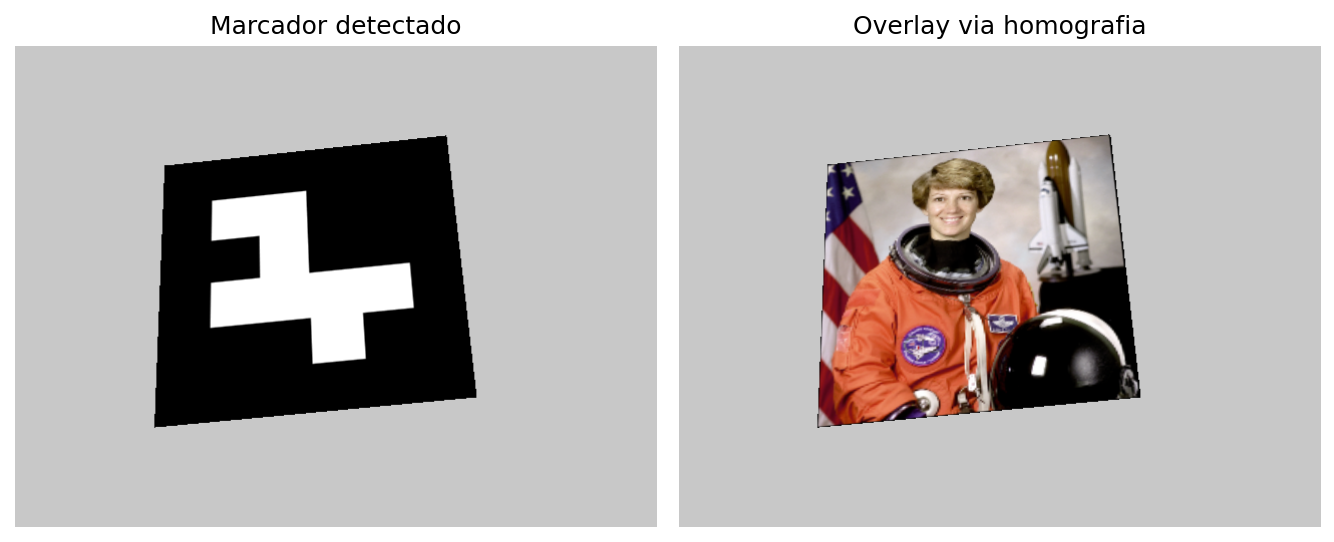

**Figura 9.22:** Realidade aumentada baseada em marcador: um marcador ArUco é detectado na cena e sua homografia é reaproveitada para posicionar uma imagem virtual sobre ele.


In [72]:
dic = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco = cv2.cvtColor(cv2.aruco.generateImageMarker(dic, 7, 200), cv2.COLOR_GRAY2BGR)

src = np.float32([[0,0],[200,0],[200,200],[0,200]])
dst = np.float32([[150,120],[430,90],[460,350],[140,380]])

cena = np.full((480,640,3), 200, np.uint8)
H, _ = cv2.findHomography(src, dst)

mask = cv2.warpPerspective(np.full((200,200),255,np.uint8), H, (640,480))
cena[mask>0] = cv2.warpPerspective(aruco, H, (640,480))[mask>0]

det = cv2.aruco.ArucoDetector(dic, cv2.aruco.DetectorParameters())
corners, ids, _ = det.detectMarkers(cena)

virtual = cv2.resize(cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2BGR), (200,200))
H, _ = cv2.findHomography(src, corners[0][0])

ra = cena.copy()
mask = cv2.warpPerspective(np.full((200,200),255,np.uint8), H, (640,480))
ra[mask>0] = cv2.warpPerspective(virtual, H, (640,480))[mask>0]

mm.show(
    [cv2.cvtColor(cena, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(ra, cv2.COLOR_BGR2RGB)],
    titles=["Marcador detectado", "Overlay via homografia"],
    cols=2, figsize=(9,4)
)

> **Nota:** sistemas modernos de realidade aumentada (como o ARKit da
Apple ou o ARCore do Google) substituem marcadores explícitos por
**odometria visual-inercial** baseada em aprendizado profundo, capaz de
rastrear características naturais da cena (sem a necessidade de um
marcador impresso) e estimar a pose da câmera em tempo real — mas o
princípio geométrico subjacente de alinhar conteúdo virtual à cena real
por meio de uma transformação estimada permanece o mesmo.

### 9.15.2 Fotogrametria e Referência de Escala

Uma pergunta recorrente em aplicações práticas é: dado um objeto medido
apenas em pixels em uma fotografia, qual é seu tamanho real? A resposta
clássica utiliza um **objeto de referência de tamanho conhecido**
presente na mesma imagem, na mesma distância aproximada da câmera:

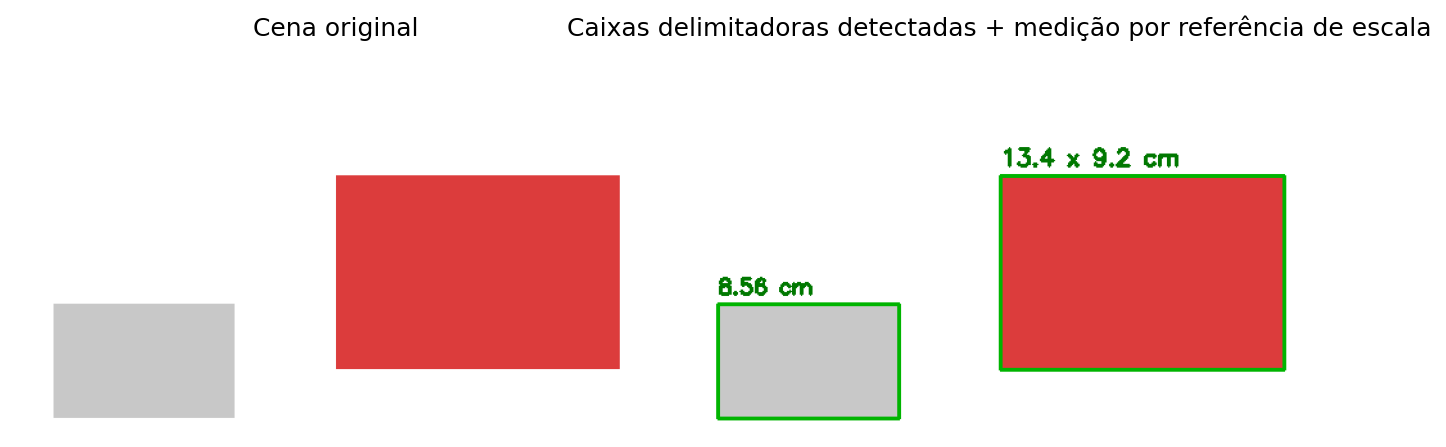

**Figura 9.23:** Medição de um objeto a partir de uma referência de escala conhecida (um cartão de 8,56 cm de largura).


In [73]:
COR_REFERENCIA = (200, 200, 200)  # cartão de referência: cinza claro
COR_OBJETO = (60, 60, 220)        # objeto a medir: vermelho

# Cena original: os objetos são desenhados PREENCHIDOS, como apareceriam de fato
# em uma foto -- e não apenas como contornos de caixa delimitadora.
cena_medicao = np.full((300, 500, 3), 255, dtype=np.uint8)
cv2.rectangle(cena_medicao, (30, 200), (30 + 140, 200 + 88), COR_REFERENCIA, -1)   # referência conhecida
cv2.rectangle(cena_medicao, (250, 100), (250 + 220, 100 + 150), COR_OBJETO, -1)    # objeto a medir

def caixa_delimitadora_por_cor(imagem_bgr, cor_bgr, tolerancia=40):
    diferenca = np.abs(imagem_bgr.astype(int) - np.array(cor_bgr)).sum(axis=2)
    mascara = (diferenca < tolerancia).astype(np.uint8) * 255
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    maior_contorno = max(contornos, key=cv2.contourArea)
    return cv2.boundingRect(maior_contorno)  # (x, y, largura, altura) em pixels

x_ref, y_ref, w_ref_px, h_ref_px = caixa_delimitadora_por_cor(cena_medicao, COR_REFERENCIA)
x_obj, y_obj, w_obj_px, h_obj_px = caixa_delimitadora_por_cor(cena_medicao, COR_OBJETO)

LARGURA_REFERENCIA_CM = 8.56  # largura padrão de um cartão (ISO/IEC 7810)
razao_cm_por_px = LARGURA_REFERENCIA_CM / w_ref_px
largura_obj_cm = w_obj_px * razao_cm_por_px
altura_obj_cm = h_obj_px * razao_cm_por_px

# Painel de resultado: a MESMA cena, agora com as caixas delimitadoras detectadas
# (em verde, obtidas por segmentação de cor) e as medições estimadas sobrepostas.
resultado = cena_medicao.copy()
cv2.rectangle(resultado, (x_ref, y_ref), (x_ref + w_ref_px, y_ref + h_ref_px), (0, 180, 0), 2)
cv2.rectangle(resultado, (x_obj, y_obj), (x_obj + w_obj_px, y_obj + h_obj_px), (0, 180, 0), 2)

cv2.putText(resultado, f"{LARGURA_REFERENCIA_CM:.2f} cm",
            (x_ref, y_ref - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 120, 0), 2)

cv2.putText(resultado,
            f"{largura_obj_cm:.1f} x {altura_obj_cm:.1f} cm",
            (x_obj, y_obj - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 120, 0), 2)

mm.show(
    [cv2.cvtColor(cena_medicao, cv2.COLOR_BGR2RGB),
     cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB)],
    titles=[
        "Cena original",
        "Caixas delimitadoras detectadas + medição por referência de escala"
    ],
    cols=2, figsize=(9,4)
)


Essa é a base da **fotogrametria** clássica — a mesma lógica se
estende, com maior sofisticação geométrica (calibração de câmera,
correção de distorção de lente, múltiplas vistas), a aplicações como
levantamento topográfico por drones e reconstrução 3D de objetos a partir
de fotografias.

### 9.15.3 Visão Estereoscópica

Enquanto a fotogrametria acima assume uma única imagem e um objeto de
referência conhecido, a **visão estereoscópica** estima profundidade
diretamente a partir de **duas câmeras** (ou duas fotografias da mesma
cena, tiradas de posições ligeiramente diferentes) — o mesmo princípio da
visão binocular humana. A ideia central é a **disparidade**: um ponto
próximo à câmera se desloca mais, entre as duas imagens, do que um ponto
distante.

Formalmente, a profundidade $Z$ de um ponto se relaciona à disparidade
$d$ (a diferença de posição horizontal do mesmo ponto nas duas imagens)
por:

$$
Z = \frac{f \cdot B}{d},
$$

em que $f$ é a distância focal da câmera e $B$ é a **linha de base**
(*baseline*) — a distância entre os dois pontos de captura. Quanto maior
a disparidade, menor a profundidade (objeto mais próximo).

Disparidade média no fundo: 2.58 px
Disparidade média no objeto em primeiro plano: 21.63 px
→ Disparidade maior = objeto mais próximo da câmera, como previsto pela equação Z = f·B/d.


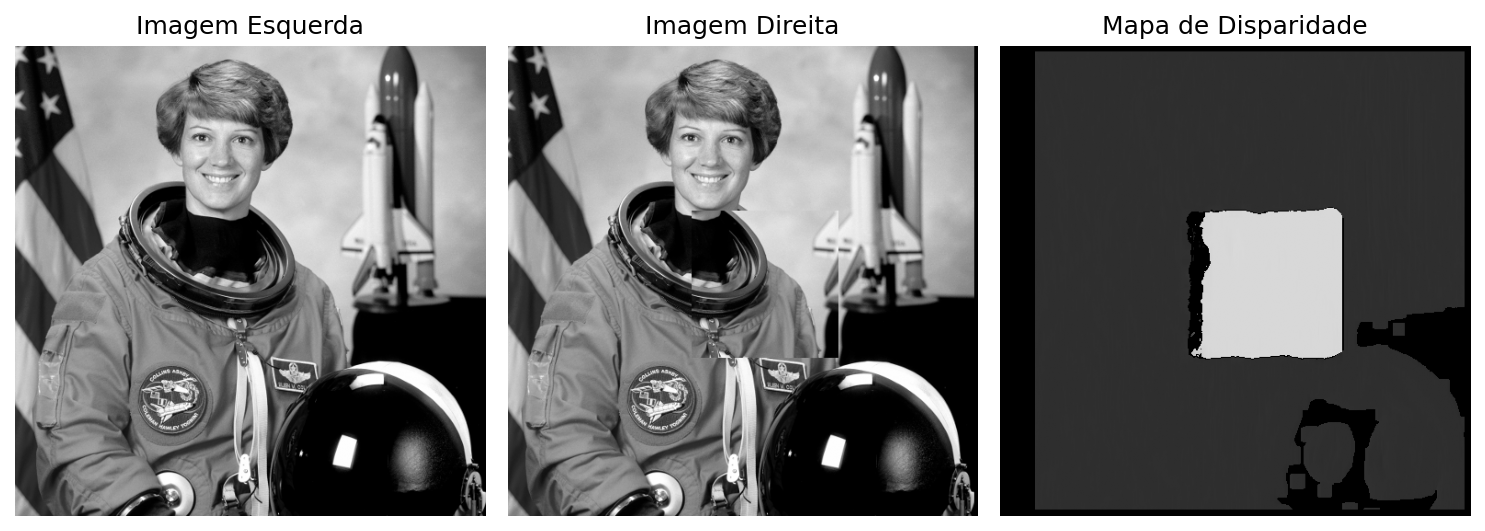

**Figura 9.24:** Par estéreo sintético (um objeto em primeiro plano deslocado mais do que o fundo) e o mapa de disparidade calculado — regiões mais claras indicam maior disparidade (objetos mais próximos).


In [74]:
img_base = cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2GRAY)

DESLOC_FUNDO = 4    # pequeno deslocamento: objeto distante
DESLOC_OBJETO = 22  # grande deslocamento: objeto próximo à câmera

def deslocar(imagem, dx):
    M = np.float32([[1, 0, dx], [0, 1, 0]])
    return cv2.warpAffine(imagem, M, (imagem.shape[1], imagem.shape[0]))

img_esquerda = img_base.copy()
img_direita = deslocar(img_base, -DESLOC_FUNDO)

# Simula um objeto em primeiro plano com deslocamento (disparidade) maior
y0, y1, x0, x1 = 180, 340, 200, 360
img_direita[y0:y1, x0:x1] = deslocar(img_base, -DESLOC_OBJETO)[y0:y1, x0:x1]

correspondencia_estereo = cv2.StereoBM_create(numDisparities=32, blockSize=15)
mapa_disparidade = correspondencia_estereo.compute(img_esquerda, img_direita).astype(np.float32) / 16.0

disp_fundo = mapa_disparidade[:150, :150].mean()
disp_objeto = mapa_disparidade[200:320, 220:340].mean()
print(f"Disparidade média no fundo: {disp_fundo:.2f} px")
print(f"Disparidade média no objeto em primeiro plano: {disp_objeto:.2f} px")
print("→ Disparidade maior = objeto mais próximo da câmera, como previsto pela equação Z = f·B/d.")

mm.show(
    [img_esquerda, img_direita, mapa_disparidade],
    titles=["Imagem Esquerda", "Imagem Direita", "Mapa de Disparidade"],
    cols=3, figsize=(10, 3.5)
)


> **Nota:** métodos clássicos de correspondência estéreo, como o
utilizado acima, comparam diretamente blocos de pixels entre as duas
imagens — uma tarefa que sofre em regiões de textura pouco distintiva
(paredes lisas, céu). Redes neurais de **estimativa de profundidade
monocular** (a partir de uma única imagem) e de **correspondência estéreo
aprendida** superam essa limitação aprendendo priors visuais sobre a
estrutura de cenas do mundo real a partir de grandes volumes de dados —
um caso de uso direto das CNNs estudadas neste capítulo aplicado
diretamente ao problema geométrico com o qual o livro se encerra.

## 9.16 Resumo

Este capítulo, que encerra a Parte II do livro, apresentou:

* **Convolução e pooling aprendidos:** a mesma operação matemática de
  convolução do Capítulo 3, mas com *kernels* tratados como parâmetros
  ajustados por treinamento, em vez de definidos manualmente;
* **Compartilhamento de pesos e hierarquia de características** como as
  propriedades que tornam as CNNs eficientes e capazes de aprender
  representações cada vez mais abstratas em camadas sucessivas;
* **Treinamento de uma CNN do zero**, com desempenho comparável — e não
  necessariamente superior — aos classificadores clássicos do Capítulo 7
  em uma base pequena e simples, reforçando que a escolha do método deve
  ser proporcional à complexidade real do problema;
* **Transferência de aprendizado**, demonstrada experimentalmente como
  uma estratégia eficaz para tarefas com poucos dados rotulados,
  reaproveitando um extrator de características já treinado em uma
  tarefa relacionada — e suas limitações, na forma da transferência
  negativa entre domínios muito distintos;
* **Aplicações em larga escala** com modelos pré-treinados de
  classificação, detecção (Faster R-CNN) e segmentação (DeepLabV3),
  seguindo o mesmo princípio de transferência de aprendizado em escala
  industrial;
* **Transferência de aprendizado aplicada à detecção de objetos**,
  ajustando um YOLO pré-treinado na COCO para localizar e classificar
  objetos geométricos sintéticos, ilustrando o mesmo princípio de
  congelamento parcial em um domínio de origem e destino ainda mais
  distantes entre si;
* **Segmentação semântica com U-Net**, implementada e treinada do zero
  sobre um conjunto sintético de baixo contraste, superando uma linha de
  base clássica de limiarização graças às conexões de atalho entre
  codificador e decodificador — e reaproveitada, sem qualquer alteração de
  arquitetura, sobre um conjunto de dados real obtido via Roboflow;
* A integração de **geometria computacional** (homografia, calibração) e
  **aprendizado profundo** em três aplicações reais que encerram o livro:
  **realidade aumentada**, **fotogrametria** e **visão estereoscópica**.

## 9.17 🤖 Uso do Gemini Notebook como Tutor Complementar

Nesta edição, o uso do **Gemini Notebook** é incentivado como ferramenta
complementar de aprendizagem. Baseado em inteligência artificial, o sistema
utiliza exclusivamente os documentos fornecidos pelo autor como fonte de
conhecimento, produzindo respostas alinhadas ao conteúdo e à abordagem
adotada ao longo deste capítulo.

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> [🚀 ACESSAR Gemini Notebook: CAPÍTULO 09](https://notebooklm.google.com/)
>
> #### ⚠️ Aviso sobre Conteúdo Gerado por IA
>
> Embora seja uma ferramenta valiosa de apoio aos estudos, o Gemini Notebook pode
> eventualmente produzir respostas incompletas, imprecisas ou incorretas.
> Recomenda-se validar as informações consultando o material do capítulo,
> livros, artigos científicos e outras fontes acadêmicas confiáveis. Sempre
> que possível, execute e experimente os exemplos práticos apresentados ao
> longo do texto para consolidar a compreensão dos conceitos.

## 9.18 Lista de Exercícios

Os exercícios a seguir consolidam os conceitos apresentados neste capítulo por meio de adaptações, experimentos e extensões dos algoritmos desenvolvidos ao longo do texto, utilizando as bibliotecas `PyTorch`, `ultralytics` e a biblioteca didática `morph`.

1. **(10%)** Investigue o impacto da profundidade em uma arquitetura convolucional. Partindo da rede de duas camadas do Projeto Prático 1, adicione uma terceira camada convolucional com 32 filtros antes das camadas totalmente conectadas. Treine a nova arquitetura mantendo o mesmo número de épocas e a mesma divisão dos dados. Compare a acurácia no conjunto de teste e o número total de parâmetros treináveis em relação à rede original, discutindo se o aumento de profundidade trouxe benefício mensurável para imagens de dimensão $8 \times 8$.
2. **(15%)** Avalie o limiar de dados necessários no domínio de destino para que o treinamento de uma CNN do zero se torne competitivo com a **transferência de aprendizado**. Variando o número de amostras de treino disponíveis no domínio B para $\{5, 10, 20, 40, 80\}$, meça a acurácia de teste para ambas as estratégias. Apresente os resultados em um gráfico de linhas e determine a partir de qual volume de dados o treinamento do zero atinge desempenho equivalente ao extrator pré-treinado.
3. **(15%)** Investigue a estratégia de **ajuste fino parcial** (*fine-tuning*) em comparação ao congelamento total de pesos. No cenário de transferência de aprendizado entre domínios de dígitos, descongele a segunda camada convolucional (`conv2`) do extrator para que ela seja atualizada juntamente com a cabeça de classificação durante o treinamento no domínio B. Compare a acurácia obtida com o congelamento total e com o treinamento do zero, discutindo o compromisso entre capacidade de adaptação e risco de sobreajuste (*overfitting*).
4. **(15%)** Analise a relação inversa entre **disparidade e profundidade em visão estereoscópica**. Utilizando a equação $Z = (f \cdot B) / d$ com distância focal $f = 700\text{ pixels}$ e linha de base $B = 6\text{ cm}$, calcule a profundidade estimada para o fundo e para o objeto em primeiro plano no experimento do capítulo. Em seguida, gere sinteticamente um terceiro objeto com um deslocamento intermediário de 12 pixels, recalcule sua profundidade e construa um gráfico mostrando a curva teórica $Z(d)$ com os três pontos experimentais destacados.
5. **(15%)** Avalie a influência da profundidade do congelamento (*freeze*) no desempenho de detectores **YOLO** submetidos à transferência de aprendizado. Utilizando o conjunto de dados sintético de formas geométricas, execute o ajuste fino variando o parâmetro de congelamento do *backbone* para $\{0, 5, 10, 15\}$. Registre a métrica $\text{mAP}_{50}$ no conjunto de validação para cada configuração, apresente os dados em uma tabela e discuta se o congelamento parcial é vantajoso quando os domínios de origem (COCO) e de destino (formas geométricas) são significativamente distantes.
6. **(15%)** Estude a importância das **conexões de atalho** (*skip connections*) na arquitetura **U-Net** para segmentação semântica. Implemente uma variação `UNetSemAtalhos` que funcione como um *autoencoder* convolucional tradicional, removendo as concatenações entre os estágios do codificador e do decodificador. Treine ambos os modelos sobre a mesma base de nódulos sintéticos, compare o IoU médio no conjunto de validação e apresente visualmente a diferença na precisão das bordas segmentadas por cada método.
7. **(15%)** Integre um *pipeline* completo de segmentação semântica utilizando dados do repositório público **Roboflow**. Baixe um conjunto de dados anotado no formato de máscaras semânticas, converta os pares de imagens e máscaras para os tensores do PyTorch e treine a `UNetCompacta`. Compare o IoU médio obtido pelo modelo profundo contra uma linha de base clássica baseada em limiarização de Otsu e filtros morfológicos da biblioteca `morph`, discutindo em quais cenários reais o aprendizado profundo justifica o custo computacional do treinamento.
8. **(Bônus – 10%)** Desenvolva um sistema interativo que combine **detecção de objetos (YOLO)** com **medição por referência de escala (fotogrametria)**. Treine o detector para identificar duas classes em uma cena: um "Cartão de Referência" (dimensão conhecida de $8{,}56\text{ cm} \times 5{,}39\text{ cm}$) e um "Objeto Alvo". Ao realizar a inferência em uma nova imagem, utilize a dimensão em pixels da *bounding box* do cartão detectado para converter as dimensões da caixa do objeto alvo em centímetros. Exiba a imagem processada com os rótulos de classe, a probabilidade de confiança e as dimensões físicas estimadas sobrepostas.

## 9.19 Encerramento da Parte II

Este capítulo conclui a Parte II do livro — e, com ela, a jornada que
começou no Capítulo 6 com a formalização de "detectar, descrever e
corresponder" características em imagens. Ao longo do caminho, um mesmo
tema conceitual se repetiu sob formas cada vez mais sofisticadas: a
tensão entre **características projetadas manualmente** (Sobel, LBP,
HOG, ORB, Haar Cascade) e **características aprendidas automaticamente**
(as CNNs deste capítulo) — e a constatação experimental, repetida em três
capítulos consecutivos, de que nenhuma das duas abordagens é
universalmente superior: a escolha correta depende da complexidade real
do problema, da quantidade de dados disponível e das restrições
computacionais da aplicação.

Para o leitor interessado em aprofundar os tópicos aqui apresentados
apenas em suas ideias centrais, algumas direções naturais de estudo
incluem:

* **Arquiteturas modernas de CNN** (ResNet, EfficientNet, Vision
  Transformers) e as inovações que permitiram treinar redes cada vez mais
  profundas;
* **Detecção e segmentação em tempo real**, com foco nas famílias YOLO e
  nos modelos de segmentação promptable como o Segment Anything;
* **Reconstrução 3D e SLAM** (*Simultaneous Localization and Mapping*),
  que estendem a visão estereoscópica deste capítulo a cenários
  dinâmicos, com câmeras em movimento;
* **Modelos generativos** para imagens (GANs, modelos de difusão),
  capazes de sintetizar, e não apenas interpretar, conteúdo visual.

Os fundamentos consolidados nesta Parte II — desde a extração de
características mais simples até as CNNs — são a
base sobre a qual todas essas direções mais avançadas se apoiam.

## Referências do Capítulo


Os conceitos e algoritmos apresentados neste capítulo foram fundamentados em referências clássicas e contemporâneas da literatura de *Deep Learning* aplicado à Visão Computacional:
- McCulloch e Pitts (1943), para a proposição da primeira abstração matemática e lógica do neurônio artificial, fundamentando as bases conceituais do processamento neural computacional.
- Rosenblatt (1958), para a formulação original do **Perceptron**, modelo precursor do neurônio artificial utilizado nas arquiteturas modernas de aprendizado profundo.
- ?goodfellow2016deep e LeCun et al. (2015), para os fundamentos de redes neurais, convolução, funções de ativação e treinamento de modelos profundos.
- Bishop (2006), para os conceitos rigorosos de reconhecimento de padrões, probabilidade, estimativa de máxima verossimilhança e métodos estatísticos aplicados ao aprendizado de máquina.
- (s.d.) para a arquitetura **U-Net**, utilizada na segmentação semântica com conexões de atalho entre codificador e decodificador.
- Redmon et al. (2016), para a arquitetura **YOLO** (*You Only Look Once*), utilizada nos experimentos de detecção de objetos com transferência de aprendizado.
- Ren et al. (2015), para a arquitetura **Faster R-CNN**, empregada como modelo pré-treinado de detecção de objetos.
- He et al. (2016), para a arquitetura **ResNet**, base de diversos extratores de características pré-treinados utilizados neste capítulo.
- (s.d.), para a arquitetura **DeepLabV3**, utilizada como modelo pré-treinado de segmentação semântica.
- Goodfellow et al. (2016), para o modelo **Segment Anything (SAM)**, mencionado como direção de estudo para segmentação promptable.
- {Google} (2025), referente à ferramenta **Gemini Notebook**, utilizada na elaboração do infográfico de síntese do capítulo e disponibilizada como apoio complementar ao estudo.

**Sem titulo**.

**Sem titulo**.

BISHOP, C. M. **Pattern Recognition and Machine Learning**. New York, NY, USA, Springer, 2006.

GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. **Deep Learning**. Cambridge, MA, USA, MIT Press, 2016.

HE, Kaiming *et al*. **Deep Residual Learning for Image Recognition**. 2016.

KINGMA, D. P.; BA, J. **Adam: A Method for Stochastic Optimization**. San Diego, CA, USA, 2015.

LECUN, Y.; BENGIO, Y.; HINTON, G. **Deep learning**. Nature Publishing Group, 2015.

MCCULLOCH, W. S.; PITTS, W. **A Logical Calculus of the Ideas Immanent in Nervous Activity**. 1943.

REDMON, Joseph *et al*. **You Only Look Once: Unified, Real-Time Object Detection**. 2016.

REN, Shaoqing *et al*. **Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks**. Curran Associates, Inc., 2015.

ROSENBLATT, F. **The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain**. 1958.

{GOOGLE}. **{NotebookLM}**. 2025.

*Referência não encontrada para: goodfellow2016deep*